## 1. 개발 환경 세팅하기

In [ ]:
!pip install koreanize_matplotlib
!pip install statsmodels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import scipy.stats as stats
import statsmodels.api as sm

%config InlineBackend.figure_format = 'retina'

# 2. 데이터 불러오기 및 탐색

In [ ]:
user_properties = "C:/Users/PC/Documents/codeit_study/고급 프로젝트/데이터/hackle/user_properties.csv"
hackle_events = "C:/Users/PC/Documents/codeit_study/고급 프로젝트/데이터/hackle/hackle_events.csv"
hackle_properties = "C:/Users/PC/Documents/codeit_study/고급 프로젝트/데이터/hackle/hackle_properties.csv"
device_properties = "C:/Users/PC/Documents/codeit_study/고급 프로젝트/데이터/hackle/device_properties.csv"


try:
    user_properties = pd.read_csv(user_properties, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    user_properties = pd.read_csv(user_properties, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")
try:
    hackle_events = pd.read_csv(hackle_events, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    hackle_events = pd.read_csv(hackle_events, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")
try:
    hackle_properties = pd.read_csv(hackle_properties, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    hackle_properties = pd.read_csv(hackle_properties, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")
try:
    device_properties = pd.read_csv(device_properties, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    device_properties = pd.read_csv(device_properties, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\3769051896.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  user_properties = pd.read_csv(user_properties, encoding='utf-8', on_bad_lines='skip')


UTF-8 인코딩으로 데이터 로드에 성공했습니다.
UTF-8 인코딩으로 데이터 로드에 성공했습니다.
UTF-8 인코딩으로 데이터 로드에 성공했습니다.
UTF-8 인코딩으로 데이터 로드에 성공했습니다.


In [ ]:
import pandas as pd

def explore_dataframe(df: pd.DataFrame, table_name: str = None):
    """
    데이터프레임에 대한 기본 탐색을 수행하는 함수
    (NA 값 현황 및 중복된 행 현황 포함)

    Args:
        df (pd.DataFrame): 탐색할 데이터프레임
        table_name (str, optional): 데이터프레임 이름(테이블명) 표시용
    """
    if df is None:
        print(f"'{table_name}' 데이터프레임이 없습니다. 탐색을 건너뜜니다.")
        return

    print("="*50)
    if table_name:
        print(f"테이블명: {table_name}")

    print("\n1) 기본 정보 (info):")
    print(df.info())

    print("\n2) 결측치 현황 (컬럼별 NA 값 개수):")
    # 각 컬럼에 존재하는 NA(Not Available) 값의 총 개수를 보여줍니다.
    # 이 숫자가 0이 아니라면 해당 컬럼에 결측치가 존재한다는 의미입니다.
    print(df.isna().sum()) # isna()를 사용하여 명확하게 표시

    print("\n3) 중복된 행 현황:")
    # 데이터프레임 내에 완전히 동일한 내용을 가진 행이 있는지 확인합니다.
    # 중복된 행의 총 개수와, 중복된 행 중 몇 개를 샘플로 보여줍니다.
    duplicate_rows_count = df.duplicated().sum()
    print(f" - 전체 중복된 행 개수: {duplicate_rows_count}개")
    if duplicate_rows_count > 0:
        print(" - 중복된 행 중 첫 5개 (예시):")
        print(df[df.duplicated(keep='first')].head()) # 'keep=first'는 첫 번째 중복을 제외하고 나머지를 보여줍니다.
    else:
        print(" - 중복된 행이 없습니다.")

    print("\n4) 기초 통계량 (수치형 컬럼 대상):")
    print(df.describe())

    print("\n2) 결측치 현황 (컬럼별 NULL 값 개수):")
    # 각 컬럼에 존재하는 NA(Not A Number) 값의 총 개수를 보여줍니다.
    # 이 숫자가 0이 아니라면 해당 컬럼에 결측치가 존재한다는 의미입니다.
    print(df.isnull().sum())

    print("\n5) 컬럼별 고유값 개수:")
    for col in df.columns:
        unique_count = df[col].nunique(dropna=True)
        print(f" - {col}: {unique_count}개")

    print("\n6) 컬럼별 데이터 타입:")
    print(df.dtypes)

    print("\n7) 샘플 데이터 (상위 5개 행):")
    print(df.head())
    print("="*50 + "\n")

In [ ]:
explore_dataframe(user_properties, table_name='user_properties')
explore_dataframe(hackle_events, table_name='hackle_events')
explore_dataframe(hackle_properties, table_name='hackle_properties')
explore_dataframe(device_properties, table_name='device_properties')

테이블명: user_properties

1) 기본 정보 (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230819 entries, 0 to 230818
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    230819 non-null  object
 1   class      230819 non-null  int64 
 2   gender     230819 non-null  object
 3   grade      230819 non-null  int64 
 4   school_id  230819 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 8.8+ MB
None

2) 결측치 현황 (컬럼별 NA 값 개수):
user_id      0
class        0
gender       0
grade        0
school_id    0
dtype: int64

3) 중복된 행 현황:
 - 전체 중복된 행 개수: 0개
 - 중복된 행이 없습니다.

4) 기초 통계량 (수치형 컬럼 대상):
               class          grade      school_id
count  230819.000000  230819.000000  230819.000000
mean        4.594999       2.002197    3083.383335
std         3.151979       0.762048    1711.671162
min         1.000000       1.000000       1.000000
25%         2.000000       1.000000    1594.000000
50%         4.000000  

- ✅ 1. user_properties 요약

| 항목        | 내용                                                      |
| --------- | ------------------------------------------------------- |
| 행 개수      | 230,819 행                                               |
| 컬럼 수      | 5개 (`user_id`, `class`, `gender`, `grade`, `school_id`) |
| 결측치       | 없음                                                      |
| 중복 행      | 없음                                                      |
| 주요 수치 통계  | `class`: 평균 4.59, 최대 20<br>`grade`: 1\~3, 평균 2.00       |
| 고유값 수     | `user_id`: 230,819개<br>`gender`: 2개                     |
| 대표 샘플 데이터 | `class` 1~~10, `grade` 1~~3, 다양한 `school_id`            |

- 📌 데이터 개요
    - 총 행 수: 230,819개

    - 컬럼 수: 5개

    - 주요 컬럼: user_id, class, gender, grade, school_id

- 📊 기본 통계 요약
    - class: 1 ~ 20까지 존재하며 평균은 약 4.6

    - grade: 1 ~ 3까지 존재, 평균 약 2.0

    - school_id: 5,023개 고유값 → 다양한 학교 존재

- 🔍 결측치
    - 결측치 없음 (모든 컬럼 완전)

- ✅ 기타 사항
    - user_id 전부 고유값

    - gender는 2개 값만 존재 → 이진 범주형

    - 중복 데이터 없음
---

- ✅ 2. hackle_events 요약

| 항목        | 내용                                                          |
| --------- | ----------------------------------------------------------- |
| 행 개수      | 11,441,319 행                                                |
| 컬럼 수      | 11개 (`event_id`, `event_datetime`, `event_key`, ...)        |
| 결측치 많은 컬럼 | `item_name`: 99.9%, `page_name`: 93%, `question_id`: 96% 결측 |
| 수치형 통계    | `friend_count` 평균: 54, `votes_count` 평균: 257                |
| 고유값 수     | `event_key`: 44개, `page_name`: 12개, `question_id`: 3,897개 등 |
| 데이터 타입    | 대부분 object / 일부 float                                       |
| 주요 특징     | 로그성 이벤트 데이터, 결측 많음                                          |

- 📊 수치형 변수 통계 요약

| 변수명            | 평균       | 중앙값     | 최대값         |
| -------------- | -------- | ------- | ----------- |
| friend\_count  | 54.3     | 49.0    | 1,365       |
| votes\_count   | 257.3    | 210.0   | 3,017       |
| heart\_balance | 16,269.3 | 1,249.0 | 884,999,800 |
| question\_id   | 2766.4   | 2569.0  | 5,133       |

- → heart_balance는 이상치 가능성 있는 고값 존재

- 🔁 중복 없음
- 📌 범주형 정보
    - event_key: 44개 고유값 → 주요 이벤트 분류 기준 가능

    - page_name: 12개

    - item_name: 5개

---
- ✅ 3. hackle_properties 요약

| 항목     | 내용                                                            |
| ------ | ------------------------------------------------------------- |
| 행 개수   | 525,350 행                                                     |
| 컬럼 수   | 8개 (`id`, `session_id`, `user_id`, `language`, ...)           |
| 결측치    | `user_id`: 약 82,255건 (15.6%)                                  |
| 고유값 수  | `user_id`: 327,380개<br>`language`: 151개<br>`versionname`: 16개 |
| 데이터 타입 | 대부분 object / 일부 int64                                         |
| 주요 특징  | 사용자 환경 정보: OS, 버전, 언어 등                                       |

- 📌 데이터 개요
    - 총 행 수: 525,350개

    - 컬럼 수: 8개

- 🔍 결측치 현황
    - user_id: 82,255개 결측 (약 15.7%)
    - → 사용자 식별 어려운 로그가 존재함

- 📊 고유값 요약
    - session_id: 253,616개 → 여러 이벤트와 연결 가능

    - language: 151개

    - osname: iOS, Android

    - osversion: 74개

    - versionname: 16개

    - device_id: 251,720개

    - → 기기와 앱 버전, OS 등의 분석 가능

---


- ✅ 4. device_properties 요약

| 항목    | 내용                                                      |
| ----- | ------------------------------------------------------- |
| 행 개수  | 252,380 행                                               |
| 컬럼 수  | 4개 (`id`, `device_id`, `device_model`, `device_vendor`) |
| 결측치   | 없음                                                      |
| 고유값 수 | `device_model`: 522개<br>`device_vendor`: 36개            |
| 주요 특징 | 디바이스 식별자 및 하드웨어 정보 제공                                   |

- 📌 데이터 개요
    - 총 행 수: 252,380개

    - 컬럼 수: 4개

- 🧼 결측치
    - 전혀 없음

- 📊 고유값 개수
    - device_model: 522개

    - device_vendor: 36개

    - → Apple, Samsung 등 제조사별/모델별 분석 가능

# 데이터 전처리

## session_id, user_id, device_id는 서로 다른 고윳값을 가지고 있어야 한다.

- 문제 상황 발견

In [ ]:
import pandas as pd

# 이미 데이터는 다음과 같이 불러온 상태
# hackle_properties = pd.read_csv(...)

# 1. user_id가 존재하는 session_id 집합
has_user_id_sessions = set(hackle_properties[~hackle_properties['user_id'].isna()]['session_id'])

# 2. user_id가 비어 있는 session_id 집합
no_user_id_sessions = set(hackle_properties[hackle_properties['user_id'].isna()]['session_id'])

# 3. 둘 다 존재하는 session_id 확인 (동일한 session_id인데 user_id가 있는 경우도 있고 없는 경우도 있는 경우)
duplicate_session_ids = has_user_id_sessions.intersection(no_user_id_sessions)

print(f"[1] 같은 session_id인데 user_id가 있는 경우와 없는 경우가 모두 존재하는 session 개수: {len(duplicate_session_ids)}")

# 4. 해당 session_id에 해당하는 전체 row 추출
duplicate_rows = hackle_properties[hackle_properties['session_id'].isin(duplicate_session_ids)]

# 5. 상위 몇 개만 확인
print("\n[2] user_id 혼재 session 예시:")
print(duplicate_rows.sort_values(by='session_id').head(10))


[1] 같은 session_id인데 user_id가 있는 경우와 없는 경우가 모두 존재하는 session 개수: 67026

[2] user_id 혼재 session 예시:
            id                            session_id  user_id language  \
360177  360178  000638C3-2BC2-4068-A482-861B526B2651      NaN    ko-KR   
94110    94111  000638C3-2BC2-4068-A482-861B526B2651   860893    ko-KR   
400137  400138  000C66B7-BD0A-4238-9560-A86E4A3A60A4  1457308    ko-KR   
144444  144445  000C66B7-BD0A-4238-9560-A86E4A3A60A4  1457308    ko-KR   
161721  161722  000C66B7-BD0A-4238-9560-A86E4A3A60A4      NaN    ko-KR   
169858  169859  000FCE97-73B9-424D-9B16-AA3159B67457  1543737    ko-KR   
456527  456528  000FCE97-73B9-424D-9B16-AA3159B67457      NaN    ko-KR   
384363  384364          000XtsnRzEW2xNWhGpi0Td8Dxt93  1132066    ko-KR   
375469  375470          000XtsnRzEW2xNWhGpi0Td8Dxt93      NaN    ko-KR   
432628  432629  0010f595-8d72-46a3-a940-edc3fbbd28fb  1089695       ko   

         osname osversion versionname                             device_id  
360177    

In [ ]:
# 문자열로 변환 후 비교
hackle_properties['session_id'] = hackle_properties['session_id'].astype(str)
hackle_properties['device_id'] = hackle_properties['device_id'].astype(str)
hackle_properties['user_id'] = hackle_properties['user_id'].astype(str)

# 1. session_id == device_id
case_1 = hackle_properties[hackle_properties['session_id'] == hackle_properties['device_id']]
print(f"[1] session_id == device_id: {len(case_1)}개")

# 2. session_id == user_id
case_2 = hackle_properties[hackle_properties['session_id'] == hackle_properties['user_id']]
print(f"[2] session_id == user_id: {len(case_2)}개")

# 3. session_id != device_id & session_id != user_id (둘 다 다르고 결측값 아님)
case_3 = hackle_properties[
    (hackle_properties['session_id'] != hackle_properties['device_id']) &
    (hackle_properties['session_id'] != hackle_properties['user_id']) &
    (hackle_properties['device_id'] != 'nan') &
    (hackle_properties['user_id'] != 'nan')
]
print(f"[3] session_id != device_id & user_id: {len(case_3)}개")

# 4. session_id == device_id & user_id 없음 (빈 문자열 또는 NaN 등)
case_4 = hackle_properties[
    (hackle_properties['session_id'] == hackle_properties['device_id']) &
    (hackle_properties['user_id'].isna() | (hackle_properties['user_id'] == 'nan'))
]
print(f"[4] session_id == device_id이고 user_id는 없는 경우: {len(case_4)}개")


[1] session_id == device_id: 116567개
[2] session_id == user_id: 92565개
[3] session_id != device_id & user_id: 261594개
[4] session_id == device_id이고 user_id는 없는 경우: 27631개


가설 : session_id, user_id, device_id 는 서로 다른 고윳값을 가지고 있어야 한다.

In [ ]:
import pandas as pd
import re

# 가정: hackle_properties 데이터프레임이 df로 로드되어 있음

total_rows = len(case_3)
print(f"전체 데이터 행 수: {total_rows}개")
print("\n--- ID 컬럼 규칙 준수율 계산 ---")

# 1. 세션 ID (session_id) 규칙: "영어 안에 '-' 들어가 있으면 오류"
#    -> 규칙 준수: 영어와 '-'가 모두 포함되지 않음
#    즉, (영어가 포함되지 않거나) OR (하이픈이 포함되지 않음)
valid_session_ids_series = case_3['session_id'].astype(str).dropna() # NaN 제외하고 검사
session_id_follows_rule_count = valid_session_ids_series[
    ~(valid_session_ids_series.str.contains(r'[a-zA-Z]', regex=True)) | # 영어가 포함되지 않음
    ~(valid_session_ids_series.str.contains(r'-', regex=True))          # 하이픈이 포함되지 않음
].shape[0]
session_id_follow_percentage = (session_id_follows_rule_count / total_rows) * 100 if total_rows > 0 else 0

print(f"\n1. 세션 ID 규칙 준수: {session_id_follows_rule_count}개 ({session_id_follow_percentage:.2f}%)")
if session_id_follows_rule_count > 0:
    print("  예시 규칙 준수 세션 ID:", valid_session_ids_series[
        ~(valid_session_ids_series.str.contains(r'[a-zA-Z]', regex=True)) |
        ~(valid_session_ids_series.str.contains(r'-', regex=True))
    ].head(5).tolist())


# 2. 사용자 ID (user_id) 규칙: "숫자로만 이뤄져야 함"
#    -> 규칙 준수: 오직 숫자로만 구성됨
valid_user_ids_series = case_3['user_id'].astype(str).dropna() # NaN 제외하고 검사
user_id_follows_rule_count = valid_user_ids_series[
    valid_user_ids_series.str.match(r'^\d+$') # <-- 여기서 regex=True를 제거했습니다.
].shape[0]
user_id_follow_percentage = (user_id_follows_rule_count / total_rows) * 100 if total_rows > 0 else 0

print(f"\n2. 사용자 ID 규칙 준수: {user_id_follows_rule_count}개 ({user_id_follow_percentage:.2f}%)")
if user_id_follows_rule_count > 0:
    print("  예시 규칙 준수 사용자 ID:", valid_user_ids_series[
        valid_user_ids_series.str.match(r'^\d+$')
    ].head(5).tolist())


# 3. 장치 ID (device_id) 규칙: "영어 안에 '-' 가 없으면 오류"
#    -> 규칙 준수: (영어가 포함되지 않거나) OR (하이픈이 포함됨)
valid_device_ids_series = case_3['device_id'].astype(str).dropna() # NaN 제외하고 검사
device_id_follows_rule_count = valid_device_ids_series[
    ~(valid_device_ids_series.str.contains(r'[a-zA-Z]', regex=True)) | # 영어가 포함되지 않음
    (valid_device_ids_series.str.contains(r'-', regex=True))          # 하이픈이 포함됨
].shape[0]
device_id_follow_percentage = (device_id_follows_rule_count / total_rows) * 100 if total_rows > 0 else 0

print(f"\n3. 장치 ID 규칙 준수: {device_id_follows_rule_count}개 ({device_id_follow_percentage:.2f}%)")
if device_id_follows_rule_count > 0:
    print("  예시 규칙 준수 장치 ID:", valid_device_ids_series[
        ~(valid_device_ids_series.str.contains(r'[a-zA-Z]', regex=True)) |
        (valid_device_ids_series.str.contains(r'-', regex=True))
    ].head(5).tolist())

print("\n--- 검사 완료 ---")

전체 데이터 행 수: 261594개

--- ID 컬럼 규칙 준수율 계산 ---

1. 세션 ID 규칙 준수: 261591개 (100.00%)
  예시 규칙 준수 세션 ID: ['8QXy31PQxbW9qLzq0Y1dhR8Ypm52', 'XVYNT6zfhFWqIg9omwg2AHDjTLx2', 'XFB2SPiGfjbVhvJ3Q3DBsaT3m2B3', 'AOMLgbQlhNUGnyvbsrdtbnUcOOc2', 'V3LLobUFnpeakqUYgsVUnaWEFoe2']

2. 사용자 ID 규칙 준수: 261580개 (99.99%)
  예시 규칙 준수 사용자 ID: ['1046711', '1224793', '1329450', '1142761', '1159545']

3. 장치 ID 규칙 준수: 261594개 (100.00%)
  예시 규칙 준수 장치 ID: ['D5417226-F71B-4A9E-A180-CD072F2AB279', 'a05c1595-3e05-434b-8684-218b528bd725', 'EAC6C0B3-7CE8-40EA-8A91-9977C0BA5EF3', '1D4EC07D-A6F2-49A6-A19C-B502B6D8C177', '87823989-7048-4F36-847A-BE5ECF854D87']

--- 검사 완료 ---


- 구성 방식
    - session_id = "-"이 포함하지 않은 랜덤한 문자열
    - user_id = 숫자로만이루어진 문자열
    - device_id "-"이 포함된 랜덤한 문자열
- 처리 방법 및 이유
    - 해당 규칙을 따르지 않는 것은 제거 후 진행
        - 해당 규칙을 따르지 않는 값을 대채 불가 및 NA 처리 할 경우 추후 분석에서 오차를 발생시킬 위험이 있기에 제거

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


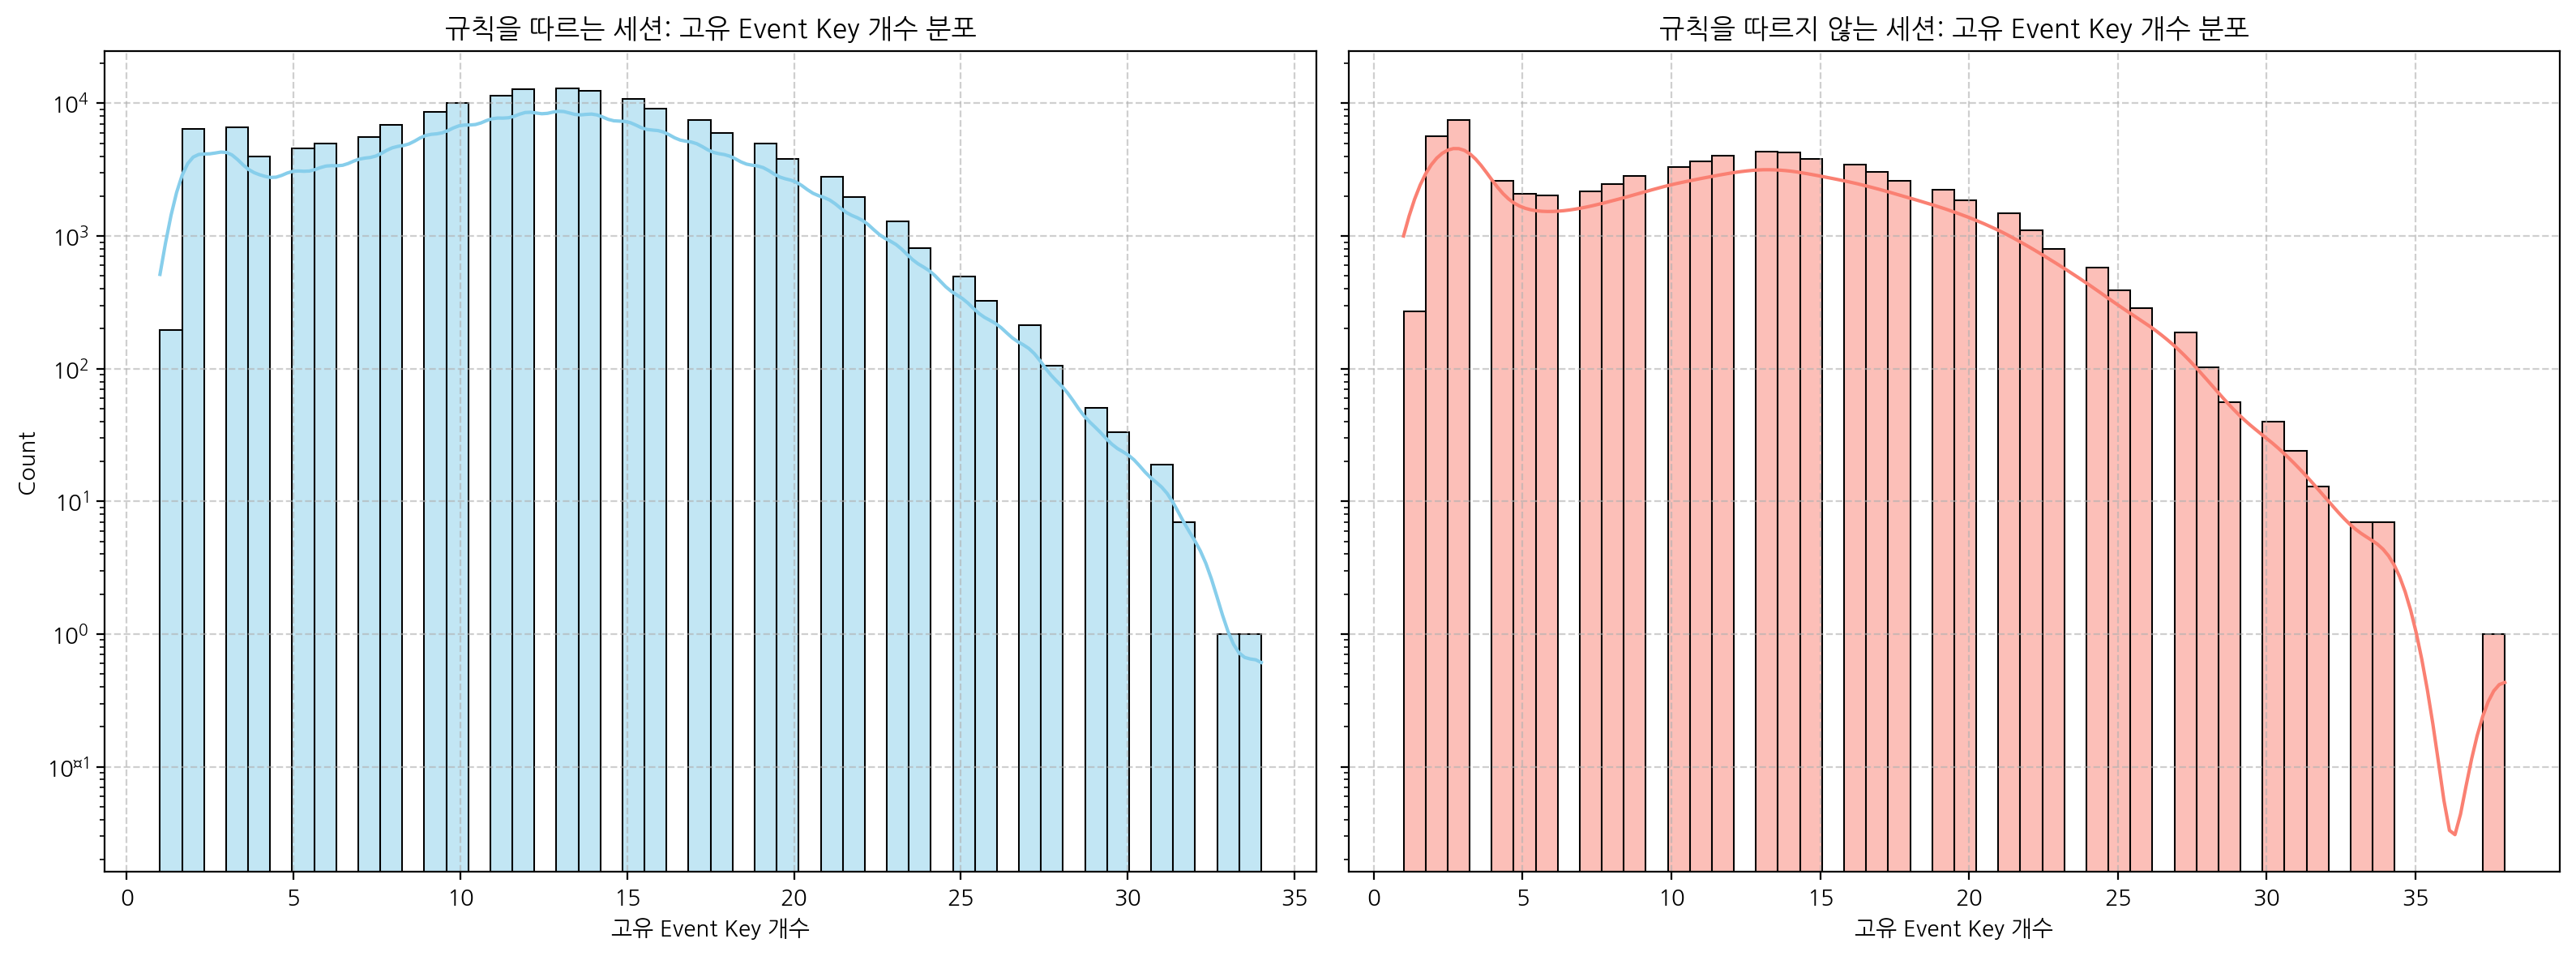


[규칙을 따르지 않는 세션 요약]
                              session_id                       user_id  \
2   6bcea65d-9f40-46fc-888c-700fe707483f                       1545130   
5           LztzUUFoRxdqTSPgQrX3MAAyNkM2  LztzUUFoRxdqTSPgQrX3MAAyNkM2   
6   d2b3ca43-4716-4852-b0e2-334848eb66f4                       1018001   
7   414540BA-1980-4371-BF37-5BFA71158C4D                       1475326   
9   94860349-d46f-4e98-8505-e96877376cee                       1537177   
11  496C4656-1079-4284-826B-5D9A8F359ECF                       1556429   
14  d693864e-577e-40a3-9477-b4826acac5c6                       1046670   
19  65e6274a-bf54-4638-83df-f37b6e6ab31c                       1188691   
25  7f0fa1b4-41b8-4267-9033-97c741099f10                       1557770   
26  D9BB24D9-6373-4D97-8EF6-800447CF7190                        947294   

                               device_id  has_numeric_user_id  \
2   6bcea65d-9f40-46fc-888c-700fe707483f                 True   
5   3F199073-9390-4137-B0B0-0DC4FC1

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. session_id별로 user_id, device_id 매핑
session_map = hackle_properties.groupby('session_id')[['user_id', 'device_id']].first().reset_index()

# 2. 병합
df = hackle_events.merge(session_map, on='session_id', how='left')

# 3. 형변환 및 정리
for col in ['user_id', 'session_id', 'device_id', 'event_key', 'page_name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

df['event_datetime'] = pd.to_datetime(df['event_datetime'], errors='coerce')
df_clean = df[df['user_id'] != 'nan'].copy()

# 4. 규칙 검사 함수
def check_rules(row):
    user_rule = bool(re.fullmatch(r'\d+', row['user_id']))
    session_rule = bool(re.search(r'[a-zA-Z]', row['session_id'])) and not '-' in row['session_id']
    device_rule = bool(re.search(r'[a-zA-Z]', row['device_id'])) and '-' in row['device_id']
    return pd.Series({
        'has_numeric_user_id': user_rule,
        'has_valid_session_id': session_rule,
        'has_valid_device_id': device_rule
    })

# 5. 세션 단위 규칙 확인
session_compliance = df_clean[['session_id', 'user_id', 'device_id']].drop_duplicates()
session_compliance = session_compliance.join(session_compliance.apply(check_rules, axis=1))
session_compliance['is_abiding_all_rules'] = session_compliance[
    ['has_numeric_user_id', 'has_valid_session_id', 'has_valid_device_id']
].all(axis=1)

# 6. 병합 후 규칙별 분리
df_final = df_clean.merge(session_compliance[['session_id', 'is_abiding_all_rules']], on='session_id', how='left')
df_abide = df_final[df_final['is_abiding_all_rules']]
df_violate = df_final[~df_final['is_abiding_all_rules']]

# 7. 고유 이벤트 수 비교
def plot_event_key_distribution(df1, df2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for i, (dfx, title, color) in enumerate([
        (df1, '규칙을 따르는 세션', 'skyblue'),
        (df2, '규칙을 따르지 않는 세션', 'salmon')
    ]):
        event_counts = dfx.groupby('session_id')['event_key'].nunique()
        sns.histplot(event_counts, bins=50, kde=True, ax=axes[i], color=color)
        axes[i].set_title(f'{title}: 고유 Event Key 개수 분포')
        axes[i].set_xlabel('고유 Event Key 개수')
        axes[i].set_yscale('log')
        axes[i].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_event_key_distribution(df_abide, df_violate)

# 8. 규칙 위반 예시 출력
print("\n[규칙을 따르지 않는 세션 요약]")
violation_samples = session_compliance[~session_compliance['is_abiding_all_rules']].head(10)
print(violation_samples[['session_id', 'user_id', 'device_id',
                         'has_numeric_user_id', 'has_valid_session_id', 'has_valid_device_id']])

# 9. 위반 유형별 device_id/user_id/session_id 예시
for col, rule_col in zip(['device_id', 'user_id', 'session_id'],
                         ['has_valid_device_id', 'has_numeric_user_id', 'has_valid_session_id']):
    print(f"\n--- {col} 규칙 위반 예시 ---")
    violated = session_compliance[~session_compliance[rule_col]][col].drop_duplicates().head(10)
    if not violated.empty:
        print(violated.to_string(index=False))
    else:
        print(f"{col} 규칙 위반 없음")


규칙을 따르지 않는 세션을 제거하는 이유

| 이유                          | 설명                                                                                             |
| --------------------------- | ---------------------------------------------------------------------------------------------- |
| 🔄 **세션 ID / 유저 ID 불일치**    | `session_id`나 `user_id`가 비정상적이면 사용자 단위 분석이 왜곡됩니다. <br>→ 동일 사용자의 세션이 나뉘거나, 여러 사용자 세션이 혼합될 수 있음. |
| 🧹 **데이터 노이즈 제거**           | 잘못된 ID 형식은 **자동화된 비정상 트래픽, 봇, 내부 테스트, 로그 누락 등**을 반영할 수 있음.                                     |
| 📉 **정확한 퍼널 분석/전환율 계산** 어려움 | 이벤트 흐름이 잘못되면 A→B→C 분석이 의미 없어짐.                                                                 |
| 🧪 **실험 그룹간 왜곡**            | A/B 테스트나 실험 중이라면, 노이즈 세션이 실험 결과를 흐릴 수 있음.                                                      |
| 🧠 **모델 학습 데이터 정제**         | 사용자 행동 기반 추천, 분류 모델 등에 사용할 경우 학습에 악영향을 줌.                                                      |


In [ ]:
import pandas as pd

# 예시: 세션 데이터 불러오기
# df = pd.read_csv('your_session_data.csv')

# 규칙 정의
user_id_valid = df['user_id'].astype(str).str.match(r'^\d+$')
session_id_valid = df['session_id'].astype(str).str.match(r'^(?!.*-).*[a-zA-Z]+.*$')
device_id_valid = df['device_id'].astype(str).str.match(r'^(?=.*[a-zA-Z])(?=.*-).+$')

# 모든 규칙 만족 여부
valid_sessions = user_id_valid & session_id_valid & device_id_valid

# ✅ 규칙을 따르는 세션만 남기기
df_cleaned = df[valid_sessions].copy()

# ❌ 제거된 세션 (필요시 확인용)
df_removed = df[~valid_sessions].copy()


In [ ]:
print(f"전체 세션 수: {len(df)}")
print(f"규칙을 따르는 세션 수: {len(df_cleaned)}")
print(f"제거된 세션 수: {len(df_removed)}")


전체 세션 수: 11441319
규칙을 따르는 세션 수: 7089045
제거된 세션 수: 4352274


## event_key 내용 파악

### heart_balance 파악 및 제거

In [ ]:
# hackle_events 데이터프레임에서 event_id가 결측값이 아닌 행만 선택
events_with_valid_event_id = df_cleaned[df_cleaned['event_key'].notna()]

print(f"원본 hackle_events 데이터프레임 행 개수: {len(df_cleaned)}개")
print(f"event_id가 결측값이 아닌 행 개수: {len(events_with_valid_event_id)}개")

print("\n--- event_key가 결측값이 아닌 데이터의 상위 5개 행 ---")
print(events_with_valid_event_id.head())

print("\n--- event_key가 결측값이 아닌 데이터의 정보 ---")
events_with_valid_event_id.info()

원본 hackle_events 데이터프레임 행 개수: 7089045개
event_id가 결측값이 아닌 행 개수: 7089045개

--- event_key가 결측값이 아닌 데이터의 상위 5개 행 ---
                                event_id      event_datetime  \
1   00000716-27e9-4e72-a602-d0ce61784b06 2023-07-18 21:07:24   
3   00000981-5e2a-4111-993e-4f1891ad9a53 2023-08-05 01:46:10   
4   00000a7a-ba72-4332-b4a9-7910670aaeb2 2023-07-24 15:03:37   
8   00001321-c6aa-4d28-ad3d-55aa4450aad7 2023-07-21 15:21:56   
10  00001661-7e46-4e66-8e38-41ac668371eb 2023-07-18 15:41:11   

                            event_key                    session_id  \
1                 click_question_open  8QXy31PQxbW9qLzq0Y1dhR8Ypm52   
3                           view_shop  XVYNT6zfhFWqIg9omwg2AHDjTLx2   
4         click_bottom_navigation_lab  XFB2SPiGfjbVhvJ3Q3DBsaT3m2B3   
8   click_bottom_navigation_questions  AOMLgbQlhNUGnyvbsrdtbnUcOOc2   
10                      skip_question  V3LLobUFnpeakqUYgsVUnaWEFoe2   

                                      id item_name page_name  friend_count 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\3965895016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_key_counts.head(20), x='count', y='event_key', palette='viridis')


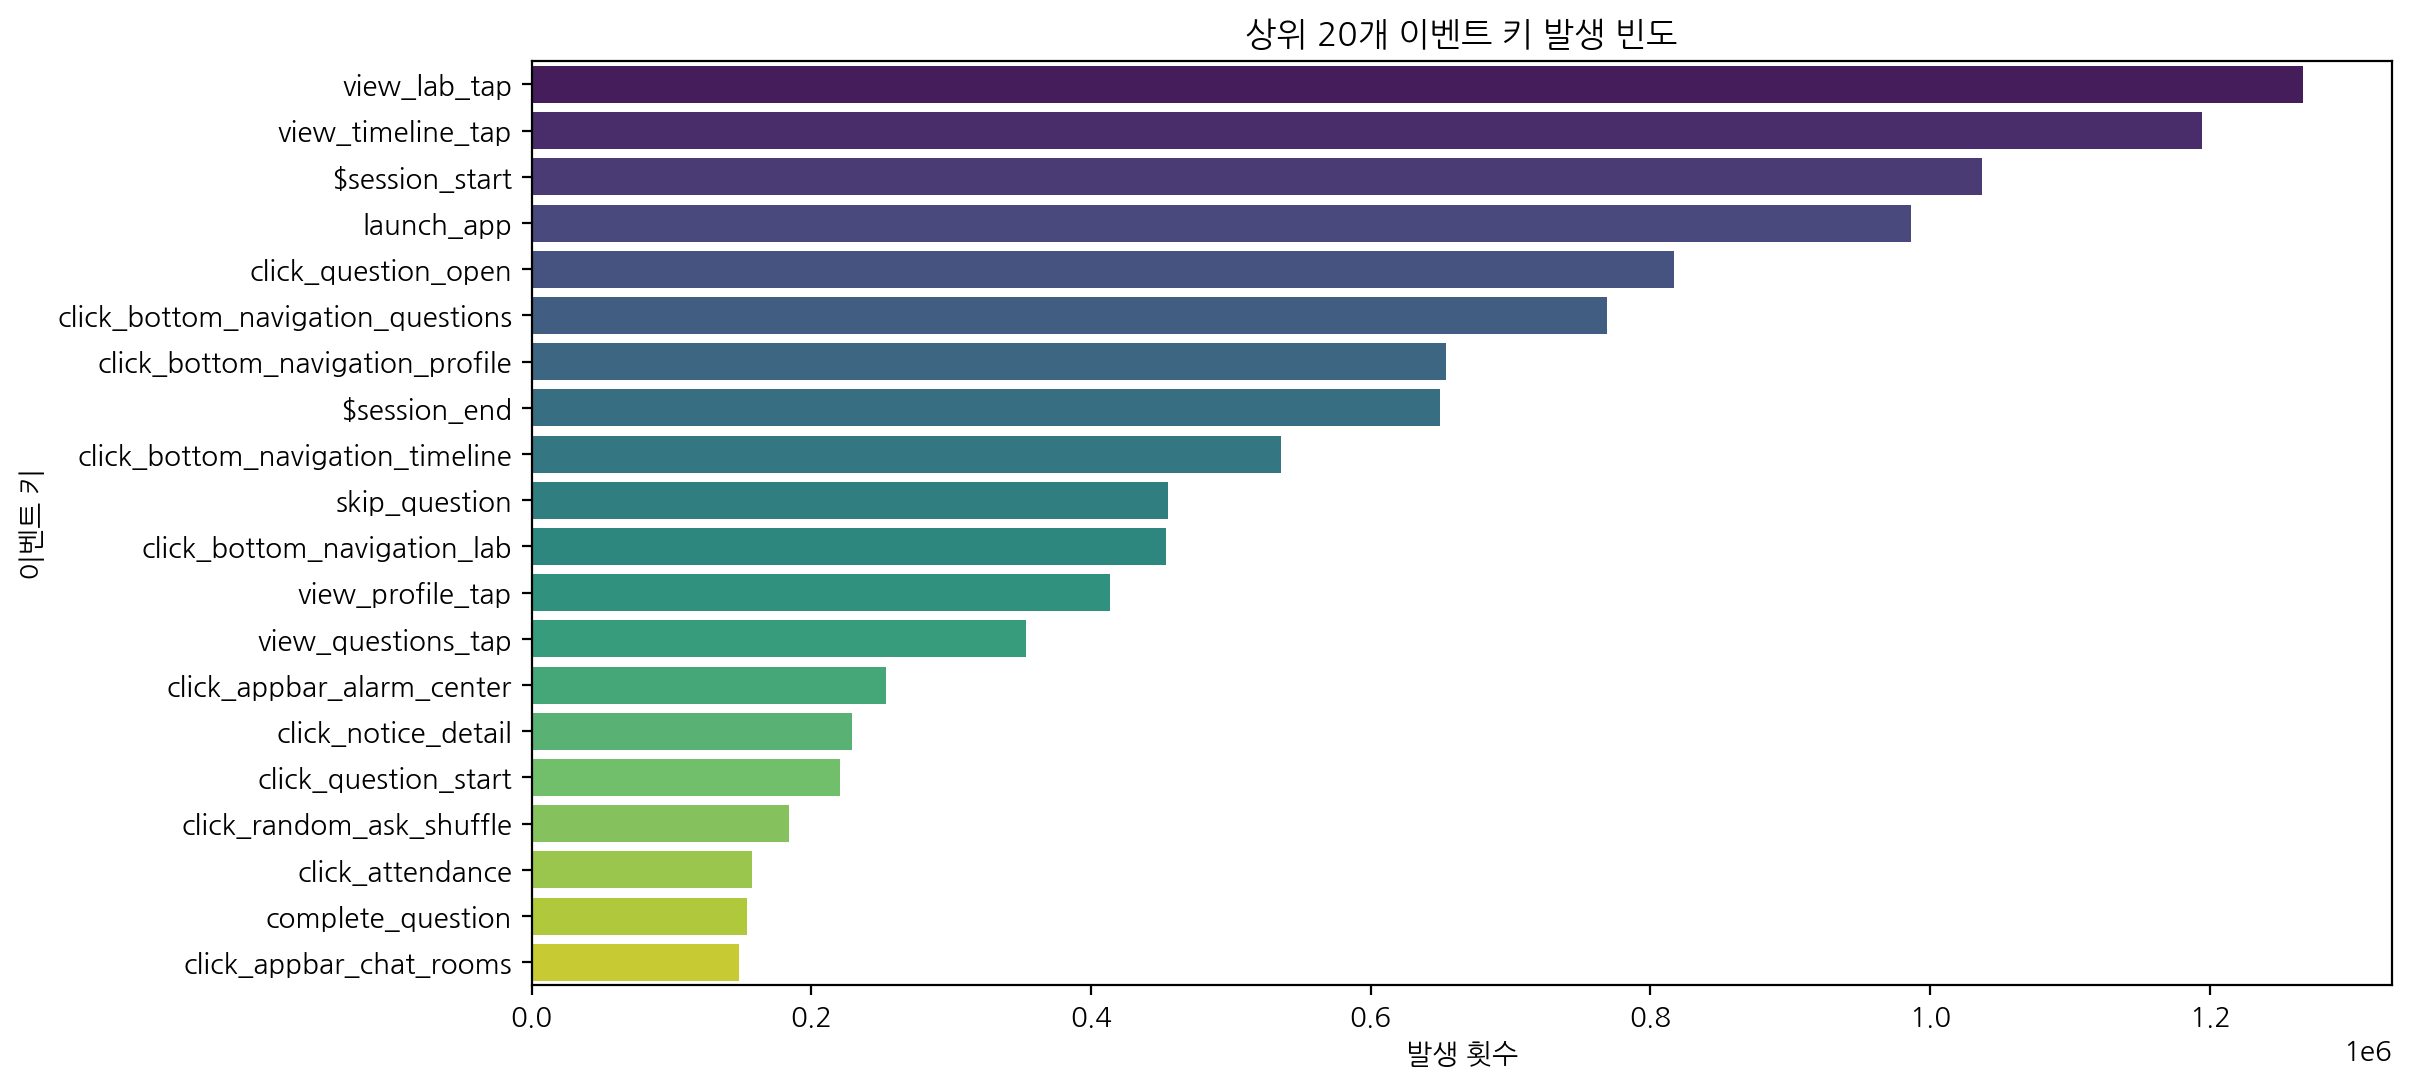

In [ ]:
# event_key별 발생 횟수 집계
event_key_counts = df_cleaned['event_key'].value_counts().reset_index()
event_key_counts.columns = ['event_key', 'count']

# 상위 20개 이벤트 키 시각화
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(12,6))
sns.barplot(data=event_key_counts.head(20), x='count', y='event_key', palette='viridis')
plt.title('상위 20개 이벤트 키 발생 빈도')
plt.xlabel('발생 횟수')
plt.ylabel('이벤트 키')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# sessions_following_all_rules_df가 이미 생성되어 있다고 가정합니다.
# (우리가 정의한 모든 ID 규칙을 따르는 깨끗한 데이터입니다.)

# 1. 데이터프레임 복사 및 정렬 확인
df_analyzed = df_cleaned.copy()

# 2. heart_balance 컬럼을 숫자 타입으로 변환 (오류 처리 포함)
df_analyzed['heart_balance'] = pd.to_numeric(df_analyzed['heart_balance'], errors='coerce')

# 3. 하트 잔여량의 변화(diff) 계산
#    diff()는 현재 값에서 이전 값을 뺀 차이를 계산합니다.
#    groupby('session_id')를 통해 각 세션 내에서만 계산이 이루어지도록 합니다.
df_analyzed['heart_balance_change'] = df_analyzed.groupby('session_id')['heart_balance'].diff()

# 4. 하트가 감소한 이벤트만 필터링 (heart_balance_change < 0)
heart_decrease_events = df_analyzed[df_analyzed['heart_balance_change'] < 0].copy()

print(f"**전체 하트 감소 이벤트 수: {len(heart_decrease_events)}개**")
print(f"하트 감소 이벤트가 발생한 고유 세션 수: {heart_decrease_events['session_id'].nunique()}개")
print(f"하트 감소 이벤트가 발생한 고유 사용자 수: {heart_decrease_events['user_id'].nunique()}개")

# 5. 하트 감소를 가장 많이 유발하는 event_key들의 빈도수 계산
print("\n### 실제 하트 감소를 가장 많이 유발하는 Event Key 빈도수 ###")
real_consumption_event_key_counts = heart_decrease_events['event_key'].value_counts()
print(real_consumption_event_key_counts)

# 6. 상위 N개의 Event Key만 대상으로 소비량 일관성 재검증 (선택 사항)
#    여기서는 상위 5개 또는 10개 등 빈도가 높은 Event Key를 선택하여 검증할 수 있습니다.
#    예시: 상위 5개 event_key
if not real_consumption_event_key_counts.empty:
    top_consumption_event_keys = real_consumption_event_key_counts.head(5).index.tolist()
    print(f"\n--- 실제 하트 감소를 가장 많이 유발하는 Event Key (상위 5개): {top_consumption_event_keys} ---")

    filtered_decrease_events_rechecked = heart_decrease_events[
        heart_decrease_events['event_key'].isin(top_consumption_event_keys)
    ].copy()

    # 하트 감소량은 음수이므로 절대값으로 변환하여 소비량으로 표시
    filtered_decrease_events_rechecked['heart_consumption_amount'] = filtered_decrease_events_rechecked['heart_balance_change'].abs()

    heart_consumption_summary_rechecked = filtered_decrease_events_rechecked.groupby('event_key')['heart_consumption_amount'].agg(
        total_consumed='sum',
        average_consumption='mean',
        median_consumption='median',
        std_consumption='std',
        min_consumption='min',
        max_consumption='max',
        number_of_consumptions='count',
        unique_consumption_values=lambda x: x.unique().tolist()
    ).reset_index()

    heart_consumption_summary_rechecked = heart_consumption_summary_rechecked.sort_values(by='total_consumed', ascending=False)

    print("\n### (재검증) 실제 하트 감소 빈도 상위 Event Key별 하트 소비량 분석 ###")
    print(heart_consumption_summary_rechecked)

    # 7. 소비량 분포 시각화 재검증
    for event_key in top_consumption_event_keys:
        if event_key in heart_consumption_summary_rechecked['event_key'].values:
            data_to_plot = filtered_decrease_events_rechecked[filtered_decrease_events_rechecked['event_key'] == event_key]['heart_consumption_amount']

            if not data_to_plot.empty:
                plt.figure(figsize=(8, 5))
                sns.histplot(data_to_plot, bins=max(1, len(data_to_plot.unique())), kde=False, color='purple')
                plt.title(f"'{event_key}' 발생 시 하트 소비량 분포 (재검증)")
                plt.xlabel('하트 소비량')
                plt.ylabel('발생 횟수')
                plt.grid(True, linestyle='--', alpha=0.6)
                plt.show()

else:
    print("\n하트 감소 이벤트가 없습니다. (heart_balance_change < 0에 해당하는 이벤트 없음)")


- 하트 소비 및 획득과 관련이 없는 event_key 존재(ex. "$session_start", "launch_app" 등)
- 구매 및 소비 관련된 다른 event_key 가 존재하고, event_key에 따라 하트 변화량이 뚜렷하게 보이는 event_key들이 있다면 heart_balance를 살릴 수 있다고 판단 후에 관련 내용 파악

In [ ]:
df_cleaned['item_name'].unique()

array([nan, '무료충전소', '1000 하트', '200 하트', '777 하트', '4000 하트'],
      dtype=object)

- item_name 은 하트 구매 관련 내용일 것으로 추측 ! 따라서, itenm_name이 "1000 하트"인데 하트 변화량이 + 1000 으로 나타난다면, 이는 신뢰할 수 있는 정보로 판단 후 확인

In [ ]:
import pandas as pd
import numpy as np


# 1. 데이터프레임 복사 및 정렬 확인
#    (heart_balance_diff 계산을 위해 세션 ID와 시간 순서로 정렬되어야 합니다.)
df_analyzed = df_cleaned.sort_values(by=['session_id', 'event_datetime']).copy()

# 2. heart_balance 컬럼을 숫자 타입으로 변환
#    이전에 astype(str)로 변환했을 수 있으므로, 계산을 위해 다시 숫자로 변환합니다.
#    'nan' 문자열이 있으면 에러가 날 수 있으므로, to_numeric에 errors='coerce'를 사용합니다.
df_analyzed['heart_balance'] = pd.to_numeric(df_analyzed['heart_balance'], errors='coerce')

# 3. 하트 잔여량의 변화(diff) 계산
#    df.diff()는 현재 값에서 이전 값을 뺀 차이를 계산합니다.
#    groupby('session_id')를 통해 각 세션 내에서만 계산이 이루어지도록 합니다.
df_analyzed['heart_balance_change'] = df_analyzed.groupby('session_id')['heart_balance'].diff()

# 4. 하트가 증가한 이벤트만 필터링 (heart_balance_change > 0)
heart_increase_events = df_analyzed[df_analyzed['heart_balance_change'] > 0].copy()

# 5. 분석 대상 item_name 정의
#    NaN은 분석 대상에서 제외됩니다.
target_item_names = ['777 하트', '무료충전소', '1000 하트', '200 하트', '4000 하트']

# 6. 대상 item_name에 해당하는 하트 증가 이벤트만 필터링
filtered_increase_events = heart_increase_events[
    heart_increase_events['item_name'].isin(target_item_names)
].copy()

print(f"하트 증가 이벤트 중 대상 item_name을 가진 이벤트 수: {len(filtered_increase_events)}개")
print(f"해당 이벤트가 발생한 고유 세션 수: {filtered_increase_events['session_id'].nunique()}개")
print(f"해당 이벤트가 발생한 고유 사용자 수: {filtered_increase_events['user_id'].nunique()}개")


# 7. item_name별 하트 증가량 분석
if not filtered_increase_events.empty:
    heart_increase_summary = filtered_increase_events.groupby('item_name')['heart_balance_change'].agg(
        total_heart_increase='sum',        # 총 증가한 하트량
        average_heart_increase='mean',     # 한 번에 평균 증가한 하트량
        number_of_increases='count'        # 해당 item_name으로 하트가 증가한 횟수
    ).reset_index()

    # 정렬하여 보기 좋게 출력
    heart_increase_summary = heart_increase_summary.sort_values(by='total_heart_increase', ascending=False)

    print("\n### Item Name별 하트 증가량 분석 ###")
    print(heart_increase_summary)

    # 8. 필요하다면, 각 item_name별로 어떤 event_key와 함께 발생하는지 확인 (주로 'complete_purchase' 등이 있을 것)
    print("\n### Item Name별 하트 증가 관련 주요 Event Key (예시) ###")
    for item in target_item_names:
        item_events = filtered_increase_events[filtered_increase_events['item_name'] == item]
        if not item_events.empty:
            print(f"- '{item}' 관련 주요 Event Key: {item_events['event_key'].value_counts().index.tolist()[:3]}") # 상위 3개 Event Key
else:
    print("\n분석 대상 item_name을 가진 하트 증가 이벤트가 충분하지 않습니다.")


하트 증가 이벤트 중 대상 item_name을 가진 이벤트 수: 1946개
해당 이벤트가 발생한 고유 세션 수: 1545개
해당 이벤트가 발생한 고유 사용자 수: 1545개

### Item Name별 하트 증가량 분석 ###
  item_name  total_heart_increase  average_heart_increase  number_of_increases
4     무료충전소              314435.0              240.577659                 1307
3    777 하트               54300.0              172.380952                  315
1    200 하트               51452.0              273.680851                  188
0   1000 하트               28883.0              215.544776                  134
2   4000 하트                 555.0              277.500000                    2

### Item Name별 하트 증가 관련 주요 Event Key (예시) ###
- '777 하트' 관련 주요 Event Key: ['click_purchase']
- '무료충전소' 관련 주요 Event Key: ['click_purchase']
- '1000 하트' 관련 주요 Event Key: ['click_purchase']
- '200 하트' 관련 주요 Event Key: ['click_purchase']
- '4000 하트' 관련 주요 Event Key: ['click_purchase']


In [ ]:
import pandas as pd
import numpy as np
import re # 정규표현식 사용을 위해 임포트


# 2. heart_balance 컬럼을 숫자 타입으로 변환 (오류 처리 포함)
df_analyzed['heart_balance'] = pd.to_numeric(df_analyzed['heart_balance'], errors='coerce')

# 3. 하트 잔여량의 변화(diff) 계산
df_analyzed['heart_balance_change'] = df_analyzed.groupby('session_id')['heart_balance'].diff()

# 4. 하트가 증가한 이벤트만 필터링 (heart_balance_change > 0)
heart_increase_events = df_analyzed[df_analyzed['heart_balance_change'] > 0].copy()

# 5. 분석 대상 item_name 정의 및 해당 item_name에서 기대되는 하트량 추출 함수 정의
target_item_names_for_exact_match = ['777 하트', '1000 하트', '200 하트', '4000 하트']

def get_expected_heart_from_item_name(item_name_str):
    if isinstance(item_name_str, str): # 문자열인 경우에만 처리
        match = re.search(r'(\d+)\s*하트', item_name_str) # 숫자와 '하트' 사이에 공백 허용
        if match:
            return float(match.group(1)) # 추출된 숫자를 float으로 변환
    return np.nan # 매칭되지 않으면 NaN 반환

# expected_heart_increase 컬럼 생성
heart_increase_events['expected_heart_increase'] = heart_increase_events['item_name'].apply(get_expected_heart_from_item_name)

# NaN이 아닌 expected_heart_increase 값과 target_item_names에 포함된 경우만 분석 대상으로 함
exact_match_analysis_df = heart_increase_events[
    heart_increase_events['item_name'].isin(target_item_names_for_exact_match) &
    heart_increase_events['expected_heart_increase'].notna()
].copy()

# 6. 실제 증가량과 기대 증가량이 정확히 일치하는 경우 카운트
exact_match_count = exact_match_analysis_df[
    exact_match_analysis_df['heart_balance_change'] == exact_match_analysis_df['expected_heart_increase']
].shape[0]

# 7. 실제 증가량이 기대 증가량보다 크거나 작은 경우 카운트 (보너스/패널티 등 확인)
greater_than_expected_count = exact_match_analysis_df[
    exact_match_analysis_df['heart_balance_change'] > exact_match_analysis_df['expected_heart_increase']
].shape[0]

less_than_expected_count = exact_match_analysis_df[
    exact_match_analysis_df['heart_balance_change'] < exact_match_analysis_df['expected_heart_increase']
].shape[0]

print("\n### Item Name 명시된 하트량과 실제 증가량 일치 여부 분석 ###")
print(f"분석 대상 Item Name을 가진 하트 증가 이벤트 총 개수: {len(exact_match_analysis_df)}개")
print(f"  (이 중 '{' | '.join(target_item_names_for_exact_match)}'에 해당하는 경우만)")

print(f"\n1. 명시된 하트량과 실제 증가량이 정확히 일치하는 경우: {exact_match_count}개")
print(f"2. 실제 증가량이 명시된 하트량보다 큰 경우 (보너스 예상): {greater_than_expected_count}개")
print(f"3. 실제 증가량이 명시된 하트량보다 작은 경우 (오류/누락 예상): {less_than_expected_count}개")

# 각 Item Name별로 상세 분석
print("\n### Item Name별 상세 분석 ###")
for item_name in target_item_names_for_exact_match:
    item_df = exact_match_analysis_df[exact_match_analysis_df['item_name'] == item_name].copy()

    if not item_df.empty:
        expected_val = item_df['expected_heart_increase'].iloc[0] # 해당 item_name의 기대값

        item_exact_match_count = item_df[item_df['heart_balance_change'] == expected_val].shape[0]
        item_greater_count = item_df[item_df['heart_balance_change'] > expected_val].shape[0]
        item_less_count = item_df[item_df['heart_balance_change'] < expected_val].shape[0]

        print(f"\n--- Item Name: '{item_name}' (기대값: {int(expected_val)} 하트) ---")
        print(f"  총 발생 횟수: {len(item_df)}개")
        print(f"  - 정확히 일치: {item_exact_match_count}개")
        print(f"  - 더 많이 증가: {item_greater_count}개")
        print(f"  - 더 적게 증가: {item_less_count}개")

        # 더 적게 증가한 경우의 예시 출력
        if item_less_count > 0:
            print(f"  [더 적게 증가한 경우 예시 (heart_balance_change < {int(expected_val)})]:")
            print(item_df[item_df['heart_balance_change'] < expected_val][
                ['item_name', 'heart_balance_change', 'expected_heart_increase', 'event_key']
            ].head(3).to_string())

        # 더 많이 증가한 경우의 예시 출력
        if item_greater_count > 0:
            print(f"  [더 많이 증가한 경우 예시 (heart_balance_change > {int(expected_val)})]:")
            print(item_df[item_df['heart_balance_change'] > expected_val][
                ['item_name', 'heart_balance_change', 'expected_heart_increase', 'event_key']
            ].head(3).to_string())



### Item Name 명시된 하트량과 실제 증가량 일치 여부 분석 ###
분석 대상 Item Name을 가진 하트 증가 이벤트 총 개수: 639개
  (이 중 '777 하트 | 1000 하트 | 200 하트 | 4000 하트'에 해당하는 경우만)

1. 명시된 하트량과 실제 증가량이 정확히 일치하는 경우: 22개
2. 실제 증가량이 명시된 하트량보다 큰 경우 (보너스 예상): 100개
3. 실제 증가량이 명시된 하트량보다 작은 경우 (오류/누락 예상): 517개

### Item Name별 상세 분석 ###

--- Item Name: '777 하트' (기대값: 777 하트) ---
  총 발생 횟수: 315개
  - 정확히 일치: 0개
  - 더 많이 증가: 3개
  - 더 적게 증가: 312개
  [더 적게 증가한 경우 예시 (heart_balance_change < 777)]:
         item_name  heart_balance_change  expected_heart_increase       event_key
935468      777 하트                  64.0                    777.0  click_purchase
11286523    777 하트                  11.0                    777.0  click_purchase
2697755     777 하트                  59.0                    777.0  click_purchase
  [더 많이 증가한 경우 예시 (heart_balance_change > 777)]:
         item_name  heart_balance_change  expected_heart_increase       event_key
8059593     777 하트                1545.0                    777.0  click_purchase
10417143    

- 종합 결론

- item_name에 따라 정확히 일치하는 하트 변화량이 단 22건이기 때문에, 믿을 수 없는 정보라고 판단
- 따라서, 해당 문제점(하트 소비 및 획득)에 대한 정확한 내용은 추후 분석 혹은 모델링 과정에서 고려 x

### 유저가 첫 등장 시 하는 행동 파악

In [ ]:

first_event_per_user_overall = df_cleaned.sort_values(by=['user_id', 'event_datetime']).groupby('user_id').head(1).copy()

print(f"전체 고유 user_id의 첫 이벤트 수: {len(first_event_per_user_overall)}개")

# --- 3. 첫 이벤트가 모든 ID 규칙을 따르는 경우만 필터링 ---
# 추출된 첫 이벤트들에 대해 user_id, session_id, device_id가 모두 규칙을 따르는지 확인합니다.
first_events_rule_abiding_users = first_event_per_user_overall[
    first_event_per_user_overall['user_id'].apply(is_numeric_user_id) &
    first_event_per_user_overall['session_id'].apply(is_valid_session_id) &
    first_event_per_user_overall['device_id'].apply(is_valid_device_id)
].copy()

print(f"모든 ID 규칙을 따르는 고유 user_id의 첫 이벤트 수: {len(first_events_rule_abiding_users)}개")

# --- 4. 필터링된 첫 이벤트들의 event_key 빈도수 계산 ---
first_event_key_frequencies_rule_abiding_users = first_events_rule_abiding_users['event_key'].value_counts().reset_index()

# 5. 컬럼 이름을 명확하게 지정합니다.
first_event_key_frequencies_rule_abiding_users.columns = ['event_key', 'count']

print("\n### 규칙을 따르는 처음 발견된 유저의 첫 Event Key 고유값 빈도수 ###")
print(first_event_key_frequencies_rule_abiding_users)

# 필요하다면 상위 N개만 볼 수도 있습니다.
# print("\n--- 상위 10개 첫 Event Key 빈도수 (규칙을 따르는 유저) ---")
# print(first_event_key_frequencies_rule_abiding_users.head(10))

전체 고유 user_id의 첫 이벤트 수: 157829개
모든 ID 규칙을 따르는 고유 user_id의 첫 이벤트 수: 157829개

### 규칙을 따르는 처음 발견된 유저의 첫 Event Key 고유값 빈도수 ###
                            event_key  count
0                      $session_start  70077
1                          launch_app  61854
2                        $session_end  25737
3                              button     99
4                       view_home_tap     13
5                        view_lab_tap      9
6                 click_question_open      5
7   click_bottom_navigation_questions      5
8                    click_attendance      5
9         click_bottom_navigation_lab      4
10                      skip_question      4
11                  complete_question      3
12    click_bottom_navigation_profile      3
13   click_bottom_navigation_timeline      2
14            click_appbar_chat_rooms      2
15               click_question_share      1
16               click_appbar_setting      1
17                 click_question_ask      1
18               click

- 첫 이벤트로 등장하는 event_key의 구성에서 비정상적인 경향이 관측
    - $session_start: 70,077건
    - launch_app: 61,854건
    - $session_end: 25,737건
        - 앱 실행 시작과 관련된 이벤트들이 대부분을 차지하고 있는 것은 타당해 보입니다. 그러나,$session_end가 처음 등장 이벤트로 25,737건이나 존재하는 점은 비정상적입니다.
일반적으로 종료 이벤트가 첫 이벤트로 등장하는 것은 논리적 오류 또는 로깅 문제일 가능성이 큼.
        - $session_start와 launch_app는 모두 앱 진입 또는 활성화 시 발생하는 시스템 이벤트로 추정됨
            - 따라서 $session_start와 launch_app는 모두 "시스템 진입"이다. 라는 가설을 세운 뒤, 연속성 검증을 진행과
            - $session_end는 실제로 세션 종료를 의미한다. 라는 가설을 세운 뒤, 정합성 검증을 진행.

#### "$session_start와 launch_app"연속성 검증

In [ ]:
import pandas as pd
import re


# --- 3. 각 '규칙을 따르는' 사용자별로 첫 두 이벤트 추출 ---
# 사용자별로 event_datetime 기준으로 정렬
rule_abiding_events_sorted = df_cleaned.sort_values(by=['user_id', 'event_datetime'])

# 각 user_id별로 상위 2개 이벤트를 가져옵니다.
first_two_events_per_user = rule_abiding_events_sorted.groupby('user_id').head(2).copy()

# 4. 첫 두 이벤트 시퀀스 생성 및 분석
first_two_event_sequences = []

# user_id별로 그룹화하여 첫 두 이벤트의 event_key를 시퀀스로 만듭니다.
for user_id, group in first_two_events_per_user.groupby('user_id'):
    if len(group) >= 2: # 이벤트가 2개 이상인 사용자만 고려
        sequence = tuple(group['event_key'].tolist())
        first_two_event_sequences.append(sequence)
    elif len(group) == 1: # 이벤트가 1개만 있는 사용자 (첫 이벤트만 있는 경우)
        first_two_event_sequences.append(tuple(group['event_key'].tolist()))

# 시퀀스 빈도수 계산
from collections import Counter
sequence_counts = Counter(first_two_event_sequences)

print("### 규칙을 따르는 유저의 첫 두 이벤트 키 시퀀스 빈도수 ###")
print(sequence_counts.most_common(10)) # 상위 10개 시퀀스 출력

# 5. '$session_start'와 'launch_app' 조합의 연속성 검증
session_start_launch_app_count = sequence_counts.get(('$session_start', 'launch_app'), 0)
launch_app_session_start_count = sequence_counts.get(('launch_app', '$session_start'), 0)

print(f"\n- ('$session_start', 'launch_app') 순서로 시작하는 사용자 수: {session_start_launch_app_count}명")
print(f"- ('launch_app', '$session_start') 순서로 시작하는 사용자 수: {launch_app_session_start_count}명")

total_consecutive_system_events = session_start_launch_app_count + launch_app_session_start_count

# 전체 사용자 수 (이벤트가 2개 이상인 사용자)
total_users_with_at_least_two_events = len([s for s in first_two_event_sequences if len(s) >= 2])
if total_users_with_at_least_two_events > 0:
    percentage_consecutive = (total_consecutive_system_events / total_users_with_at_least_two_events) * 100
    print(f"- 전체 사용자 중 이 두 이벤트가 연속으로 나타나는 비율 (이벤트 2개 이상인 사용자 기준): {percentage_consecutive:.2f}%")
else:
    print("- 이벤트가 2개 이상인 사용자가 없어 비율을 계산할 수 없습니다.")


### 규칙을 따르는 유저의 첫 두 이벤트 키 시퀀스 빈도수 ###
[(('$session_start', 'launch_app'), 54994), (('launch_app', '$session_start'), 48285), (('$session_start', '$session_end'), 14696), (('launch_app', '$session_end'), 13062), (('$session_end', 'launch_app'), 12983), (('$session_end', '$session_start'), 12706), (('launch_app', 'launch_app'), 206), (('$session_start', '$session_start'), 175), (('launch_app',), 142), (('$session_start',), 44)]

- ('$session_start', 'launch_app') 순서로 시작하는 사용자 수: 54994명
- ('launch_app', '$session_start') 순서로 시작하는 사용자 수: 48285명
- 전체 사용자 중 이 두 이벤트가 연속으로 나타나는 비율 (이벤트 2개 이상인 사용자 기준): 65.51%


- ✅ 사용자 진입 이벤트 ($session_start, launch_app)에 대한 분석 정당성
    - $session_start와 launch_app는 모두 앱 진입 또는 활성화 시 발생하는 시스템 이벤트로 추정됩니다.

    - 실제로 이벤트가 2개 이상인 사용자 기준으로, 이 두 이벤트가 연속적으로 등장하는 비율은 **65.51%**에 달함.
        - → 두 이벤트를 같은 의미의 시작 이벤트로 묶어 사용하는 것은 합리적이며, 사용자 앱 사용의 시작으로 정의 가능.
        - 후에 분석 내용에서 "어플 실행" 이라는 카테고리로 묶을 예정

#### $session_end 정합성 검정

총 `$session_end` 이벤트 수: 375697개
`$session_end` 이후 다음 이벤트가 존재하는 경우: 372973개

### `$session_end` 이후 다음 이벤트까지의 시간 차이 분석 ###

--- 시간 차이 (초 단위) 통계 ---
count    3.729730e+05
mean     5.276861e+04
std      8.464386e+04
min      0.000000e+00
25%      2.000000e+00
50%      1.220900e+04
75%      7.266800e+04
max      1.918355e+06
Name: time_diff_after_end_seconds, dtype: float64


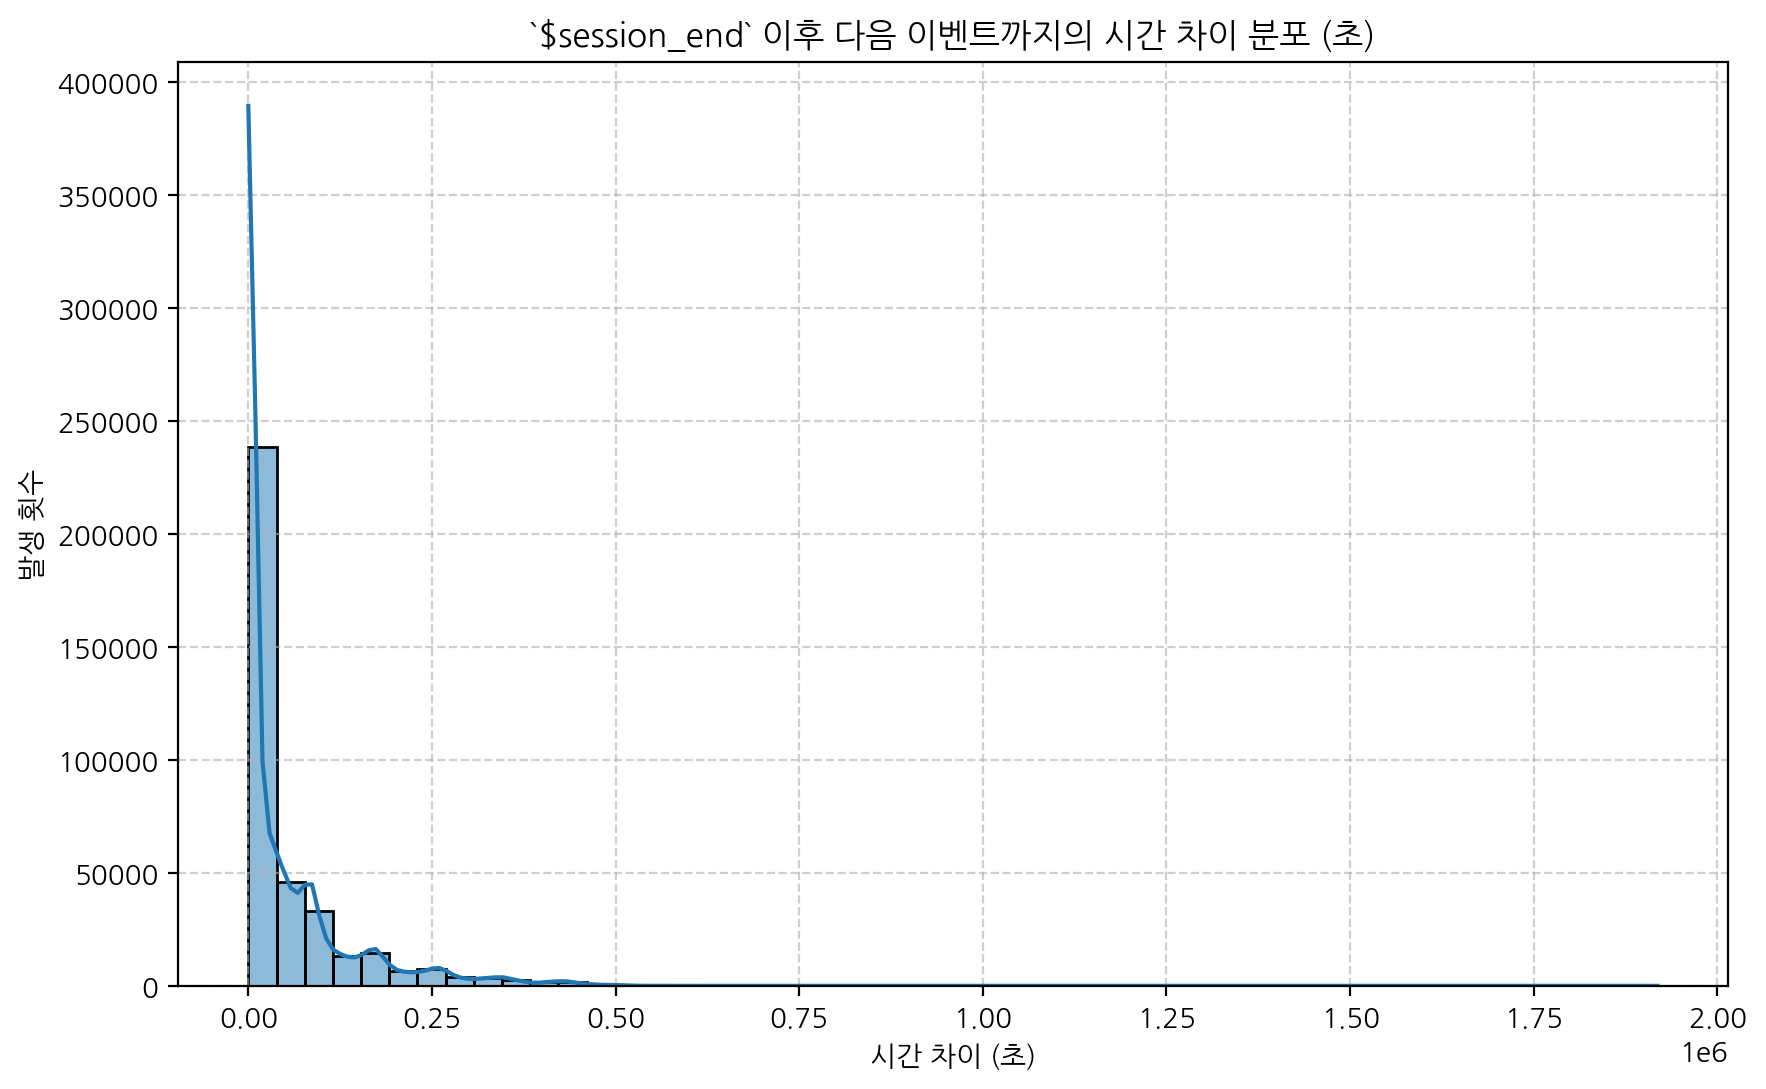


시간 차이가 0초인 `$session_end` 이벤트 이후 다음 이벤트 수: 77025개

--- 시간 차이가 0초인 `$session_end` 이벤트 예시 (상위 5개) ---
                            session_id      event_datetime     event_key  \
4637897   001zjRPEGWWVou4CbhLU7JQ9K9W2 2023-07-18 11:17:19  $session_end   
1938546   002KHtytQcVvLzOzvprOv0sxVTM2 2023-08-05 20:57:25  $session_end   
78298     002r3iOqdkTogNK959c80mHZpIz2 2023-07-21 20:55:27  $session_end   
3026222   008tC2rC0BaMMbCssEPu71R8kGm1 2023-08-06 19:51:43  $session_end   
10037606  00GmYqjW7Bf8I5iB1xrV4GWdGOu1 2023-07-20 20:28:49  $session_end   

         next_event_datetime next_event_event_key  
4637897  2023-07-18 11:17:19       $session_start  
1938546  2023-08-05 20:57:25           view_login  
78298    2023-07-21 20:55:27       $session_start  
3026222  2023-08-06 19:51:43           launch_app  
10037606 2023-07-20 20:28:49       $session_start  

시간 차이가 0초보다 큰 `$session_end` 이벤트 이후 다음 이벤트 수: 295948개

--- 시간 차이가 0초보다 큰 `$session_end` 이벤트 예시 (상위 5개) ---
                      

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import koreanize_matplotlib

# df_events_cleaned_filtered는 user_id가 'nan'이 아닌 필터링된 데이터프레임입니다.
# (이전 분석에서 사용된, user_id, session_id, event_datetime이 datetime 타입인 데이터프레임입니다.)

# 데이터가 session_id와 event_datetime 순으로 정렬되어 있는지 다시 확인합니다.
df_events_cleaned_filtered_sorted = df_cleaned.sort_values(by=['session_id', 'event_datetime']).copy()

# 1. 각 이벤트의 다음 이벤트 시간 찾기
#    groupby('session_id')를 통해 각 세션 내에서만 shift가 적용되도록 합니다.
df_events_cleaned_filtered_sorted['next_event_datetime'] = \
    df_events_cleaned_filtered_sorted.groupby('session_id')['event_datetime'].shift(-1)
df_events_cleaned_filtered_sorted['next_event_event_key'] = \
    df_events_cleaned_filtered_sorted.groupby('session_id')['event_key'].shift(-1)

# 2. `$session_end` 이벤트만 필터링합니다.
session_end_events = df_events_cleaned_filtered_sorted[
    df_events_cleaned_filtered_sorted['event_key'] == '$session_end'
].copy()

# 3. `$session_end` 이후 다음 이벤트가 존재하는 경우만 선택합니다.
#    (즉, `$session_end`가 해당 세션의 마지막 이벤트가 아닌 경우)
session_end_with_next_event = session_end_events[
    session_end_events['next_event_datetime'].notna()
].copy()

# 4. 시간 차이 계산
session_end_with_next_event['time_diff_after_end_seconds'] = \
    (session_end_with_next_event['next_event_datetime'] - session_end_with_next_event['event_datetime']).dt.total_seconds()

print(f"총 `$session_end` 이벤트 수: {len(session_end_events)}개")
print(f"`$session_end` 이후 다음 이벤트가 존재하는 경우: {len(session_end_with_next_event)}개")

print("\n### `$session_end` 이후 다음 이벤트까지의 시간 차이 분석 ###")

if not session_end_with_next_event.empty:
    # 시간 차이 통계
    print("\n--- 시간 차이 (초 단위) 통계 ---")
    print(session_end_with_next_event['time_diff_after_end_seconds'].describe())

    # 분포 시각화 (0초 이상인 경우만)
    plt.figure(figsize=(10, 6))
    sns.histplot(
        session_end_with_next_event[session_end_with_next_event['time_diff_after_end_seconds'] >= 0]['time_diff_after_end_seconds'],
        bins=50, kde=True
    )
    plt.title('`$session_end` 이후 다음 이벤트까지의 시간 차이 분포 (초)')
    plt.xlabel('시간 차이 (초)')
    plt.ylabel('발생 횟수')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # 시간 차이가 0초인 경우의 예시
    zero_diff_count = session_end_with_next_event[session_end_with_next_event['time_diff_after_end_seconds'] == 0].shape[0]
    print(f"\n시간 차이가 0초인 `$session_end` 이벤트 이후 다음 이벤트 수: {zero_diff_count}개")
    if zero_diff_count > 0:
        print("\n--- 시간 차이가 0초인 `$session_end` 이벤트 예시 (상위 5개) ---")
        print(session_end_with_next_event[session_end_with_next_event['time_diff_after_end_seconds'] == 0][
            ['session_id', 'event_datetime', 'event_key', 'next_event_datetime', 'next_event_event_key']
        ].head())

    # 시간 차이가 0초보다 큰 경우의 예시
    positive_diff_count = session_end_with_next_event[session_end_with_next_event['time_diff_after_end_seconds'] > 0].shape[0]
    print(f"\n시간 차이가 0초보다 큰 `$session_end` 이벤트 이후 다음 이벤트 수: {positive_diff_count}개")
    if positive_diff_count > 0:
        print("\n--- 시간 차이가 0초보다 큰 `$session_end` 이벤트 예시 (상위 5개) ---")
        print(session_end_with_next_event[session_end_with_next_event['time_diff_after_end_seconds'] > 0].sort_values(by='time_diff_after_end_seconds', ascending=False).head())

else:
    print("`$session_end` 이후 다음 이벤트가 존재하는 경우가 없습니다.")


⚠️ 종료 이벤트 ($session_end)의 비정상적 패턴
- $session_end 이벤트의 총 발생 수는 626,000건이며,
- 이 중 다음 이벤트 발생까지 0초 이내인 경우는 114,000건으로, 시스템상 종료 이벤트가 실제 종료가 아닌 중간 이벤트로 오기록되었을 가능성이 있음.

- 또한 사용자 첫 이벤트로 $session_end가 등장하는 경우까지 존재함 → 종료 이벤트의 의미에 대해 신뢰성 없음 판단.
🛠 처리 및 후속 조치
- 기존 $session_end 삭제, 그리고 사용자 행동 로그 기준으로 20분 이상 행동이 없을 경우 session_end를 삽입하는 방식으로 세션 구간을 재정의.

In [ ]:
import pandas as pd
import numpy as np
import re
import uuid # 새로운 session_id 생성을 위해 임포트

# sessions_following_all_rules_df는 이전 코드에서 모든 규칙을 따르는 세션들로 필터링된 데이터프레임입니다.
# 이 데이터프레임이 준비되어 있다고 가정합니다.

# --- 1. 기존 '$session_end' 이벤트 제거 ---
df_redefined_sessions = df_cleaned[
    df_cleaned['event_key'] != '$session_end'
].copy()

print(f"기존 `$session_end` 제거 후 총 이벤트 수: {len(df_redefined_sessions)}개")

# --- 2. user_id 및 event_datetime 기준으로 정렬 ---
df_redefined_sessions = df_redefined_sessions.sort_values(by=['user_id', 'event_datetime']).reset_index(drop=True)

# --- 3. 세션 경계 이벤트 삽입 및 Session ID 재할당 ---
session_timeout_seconds = 20 * 60 # 20분 * 60초

# 결과를 담을 리스트 (각 행을 그대로 추가)
processed_events = []

# 각 user_id별로 순회
for user_id, user_group in df_redefined_sessions.groupby('user_id'):
    user_group = user_group.sort_values(by='event_datetime').reset_index(drop=True)

    # 현재 세션 ID 추적 (첫 번째 이벤트의 session_id로 시작)
    current_session_id = user_group.loc[0, 'session_id']

    # 각 이벤트의 다음 이벤트와의 시간 차이 계산
    user_group['time_diff_to_next'] = user_group['event_datetime'].diff().dt.total_seconds().shift(-1)

    for idx, row in user_group.iterrows():
        # 현재 이벤트 추가
        processed_events.append(row.copy()) # 원본 행을 그대로 추가

        # 마지막 이벤트가 아니고, 다음 이벤트와의 시간 간격이 20분 이상인 경우
        if pd.notna(row['time_diff_to_next']) and row['time_diff_to_next'] >= session_timeout_seconds:
            # 1) '$session_end' 이벤트 추가
            new_session_end = row.copy() # 현재 이벤트 정보 복사
            new_session_end['event_key'] = '$session_end' # 사용자 정의 세션 종료
            new_session_end['event_datetime'] = row['event_datetime'] # 현재 이벤트와 동일 시간
            new_session_end['session_id'] = current_session_id # 현재 세션 ID 유지
            processed_events.append(new_session_end)

            # 2) '$session_start' 이벤트 추가 (다음 이벤트 정보를 복사하여 생성)
            # 새로운 session_id 생성 (하이픈 없이)
            new_session_id = str(uuid.uuid4()).replace('-', '')

            # 다음 이벤트는 user_group.loc[idx + 1] 이므로, 그 이벤트를 위한 session_start 생성
            next_original_event = user_group.loc[idx + 1]

            new_session_start = next_original_event.copy()
            new_session_start['event_key'] = '$session_start' # 사용자 정의 세션 시작
            new_session_start['event_datetime'] = next_original_event['event_datetime'] # 다음 이벤트와 동일 시간
            new_session_start['session_id'] = new_session_id # 새 세션 ID 할당
            processed_events.append(new_session_start)

            # 여기서부터 다음 '$session_end' 또는 사용자의 마지막 이벤트까지
            # 새로운 session_id를 할당합니다.
            current_session_id = new_session_id # 현재 세션 ID를 새로운 ID로 업데이트
            # 다음 for 루프 반복 시, 이 새로운 current_session_id가 사용됩니다.

        # 실제 user_group 내의 이벤트의 session_id를 새로운 current_session_id로 덮어씌웁니다.
        # 이렇게 하면 기존 이벤트들의 session_id도 새롭게 할당됩니다.
        user_group.loc[idx, 'session_id'] = current_session_id

    # user_group의 마지막 이벤트 처리 (time_diff_to_next가 NaN인 경우)
    # 마지막 이벤트 이후 20분 이상 활동이 없었다면 $ 추가
    if user_group.iloc[-1]['time_diff_to_next'] is np.nan: # 마지막 행이고 time_diff_to_next가 NaN인 경우
        # 마지막 이벤트의 session_id를 기준으로 $session_end을 추가
        new_session_end_last = user_group.iloc[-1].copy()
        new_session_end_last['event_key'] = '$session_end'
        new_session_end_last['event_datetime'] = user_group.iloc[-1]['event_datetime']
        new_session_end_last['session_id'] = current_session_id # 현재 세션 ID 유지
        processed_events.append(new_session_end_last)


# 새로운 이벤트들을 포함하여 최종 데이터프레임 생성
# processed_events 리스트는 이제 user_group의 원래 행들과 삽입된 새로운 행들을 모두 포함
# 그리고 user_group의 원래 행들의 session_id도 재할당된 상태
df_final_sessions = pd.DataFrame(processed_events)

# 불필요한 임시 컬럼 제거 후 정렬
if 'time_diff_to_next' in df_final_sessions.columns:
    df_final_sessions = df_final_sessions.drop(columns=['time_diff_to_next'])

df_final_sessions = df_final_sessions.sort_values(by=['user_id', 'event_datetime']).reset_index(drop=True)


print(f"새로운 `$session_end` 및 `$session_start` 삽입 완료.")
print(f"최종 데이터의 총 이벤트 수: {len(df_final_sessions)}개")
print(f"추가된 `$session_end` 수: {df_final_sessions[df_final_sessions['event_key'] == '$session_end'].shape[0]}개")
print(f"추가된 `$session_start` 수: {df_final_sessions[df_final_sessions['event_key'] == '$session_start'].shape[0]}개")

# 결과 확인을 위한 샘플 출력 (session_id에 하이픈이 없는지 확인)
print("\n--- 재정의된 세션 데이터 샘플 (user_id, event_datetime, event_key, session_id) ---")
# 임의의 사용자 ID를 선택하여 해당 사용자의 이벤트를 확인하면 더 좋습니다.
# sample_user_id_to_check = df_final_sessions['user_id'].iloc[0] # 임의의 사용자 ID
# print(df_final_sessions[df_final_sessions['user_id'] == sample_user_id_to_check][['event_datetime', 'event_key', 'session_id']].head(20).to_string())
# print(df_final_sessions[['user_id', 'event_datetime', 'event_key', 'session_id']].head(50).to_string())

# 전체 session_id에 하이픈이 있는지 확인 (최종 검증)
hyphenated_session_ids_check = df_final_sessions[
    df_final_sessions['session_id'].str.contains('-')
]
print(f"\n하이픈을 포함하는 session_id 개수: {hyphenated_session_ids_check['session_id'].nunique()}개")
if hyphenated_session_ids_check.empty:
    print("=> 모든 session_id가 하이픈을 포함하지 않습니다. 규칙 준수.")
else:
    print("=> !!! 하이픈을 포함하는 session_id가 아직 존재합니다. !!!")
    print(hyphenated_session_ids_check['session_id'].head().tolist()) # 예시 출력

기존 `$session_end` 제거 후 총 이벤트 수: 6713348개
새로운 `$session_end` 및 `$session_start` 삽입 완료.
최종 데이터의 총 이벤트 수: 7496628개
추가된 `$session_end` 수: 391640개
추가된 `$session_start` 수: 1017657개

--- 재정의된 세션 데이터 샘플 (user_id, event_datetime, event_key, session_id) ---

하이픈을 포함하는 session_id 개수: 0개
=> 모든 session_id가 하이픈을 포함하지 않습니다. 규칙 준수.


In [ ]:

# user_id별로 정렬
df_sorted = df_final_sessions.sort_values(["user_id", "event_datetime"])

# 연속된 중복 event_key 제거
df_sorted["prev_event_key"] = df_sorted.groupby("user_id")["event_key"].shift(1)
removed_df = df_sorted[df_sorted["event_key"] != df_sorted["prev_event_key"]].drop(columns="prev_event_key").reset_index(drop=True)

- 위 세션 재정의 작업의 시간 소요가 많기에 이를 따로 csv 파일로 저장 후 분석 단계에서 임포트 예정을 위한 csv 파일 저장

In [ ]:
removed_df.to_csv("event_duplicate_removed.csv", index=False, encoding="utf-8-sig")

# EDA 및 분석

## 소비 유도에 기여하는 행동 경로 분석

- 목적 : 사용자들이 ‘하트 관련 소비 행동’을 하기 직전에 어떤 행동을 했는지 분석하여, **소비 유도에 기여하는 행동 경로(=전환 유도 흐름)**를 파악하기 위함.



In [ ]:
df = "C:/Users/PC/Downloads/event_duplicate_removed.csv"

In [ ]:
try:
    df = pd.read_csv(df, encoding='utf-8', on_bad_lines='skip')
    print("UTF-8 인코딩으로 데이터 로드에 성공했습니다.")
except UnicodeDecodeError:
    df = pd.read_csv(df, encoding='cp949', on_bad_lines='skip')
    print("CP949 인코딩으로 데이터 로드에 성공했습니다.")

UTF-8 인코딩으로 데이터 로드에 성공했습니다.


--- 1단계: event_category 매핑 업데이트 및 적용 시작 (NaN 값 채우기 포함) ---
데이터프레임 'df'의 'event_category' 컬럼이 업데이트되었습니다 (NaN 값 포함).
=> 모든 'event_key'가 카테고리에 성공적으로 매핑되었습니다. NaN 값이 없습니다.

--- 1단계: event_category 매핑 업데이트 및 적용 완료 ---

--- 2단계: '소비(하트 진입)' 직전 행동 분석 시작 ---
'complete_purchase' 이벤트로 도달하는 직전 행동을 분석합니다.

--- '소비(하트 진입)' 직전 행동 이벤트 키 빈도 분석 결과 ---
previous_event_key_in_session
click_purchase    1603
view_shop            6
Name: count, dtype: int64

총 직전 행동 발생 횟수: 1609회

--- 2단계: '소비(하트 진입)' 직전 행동 분석 완료 ---

--- 3단계: 분석 결과 시각화 시작 ---


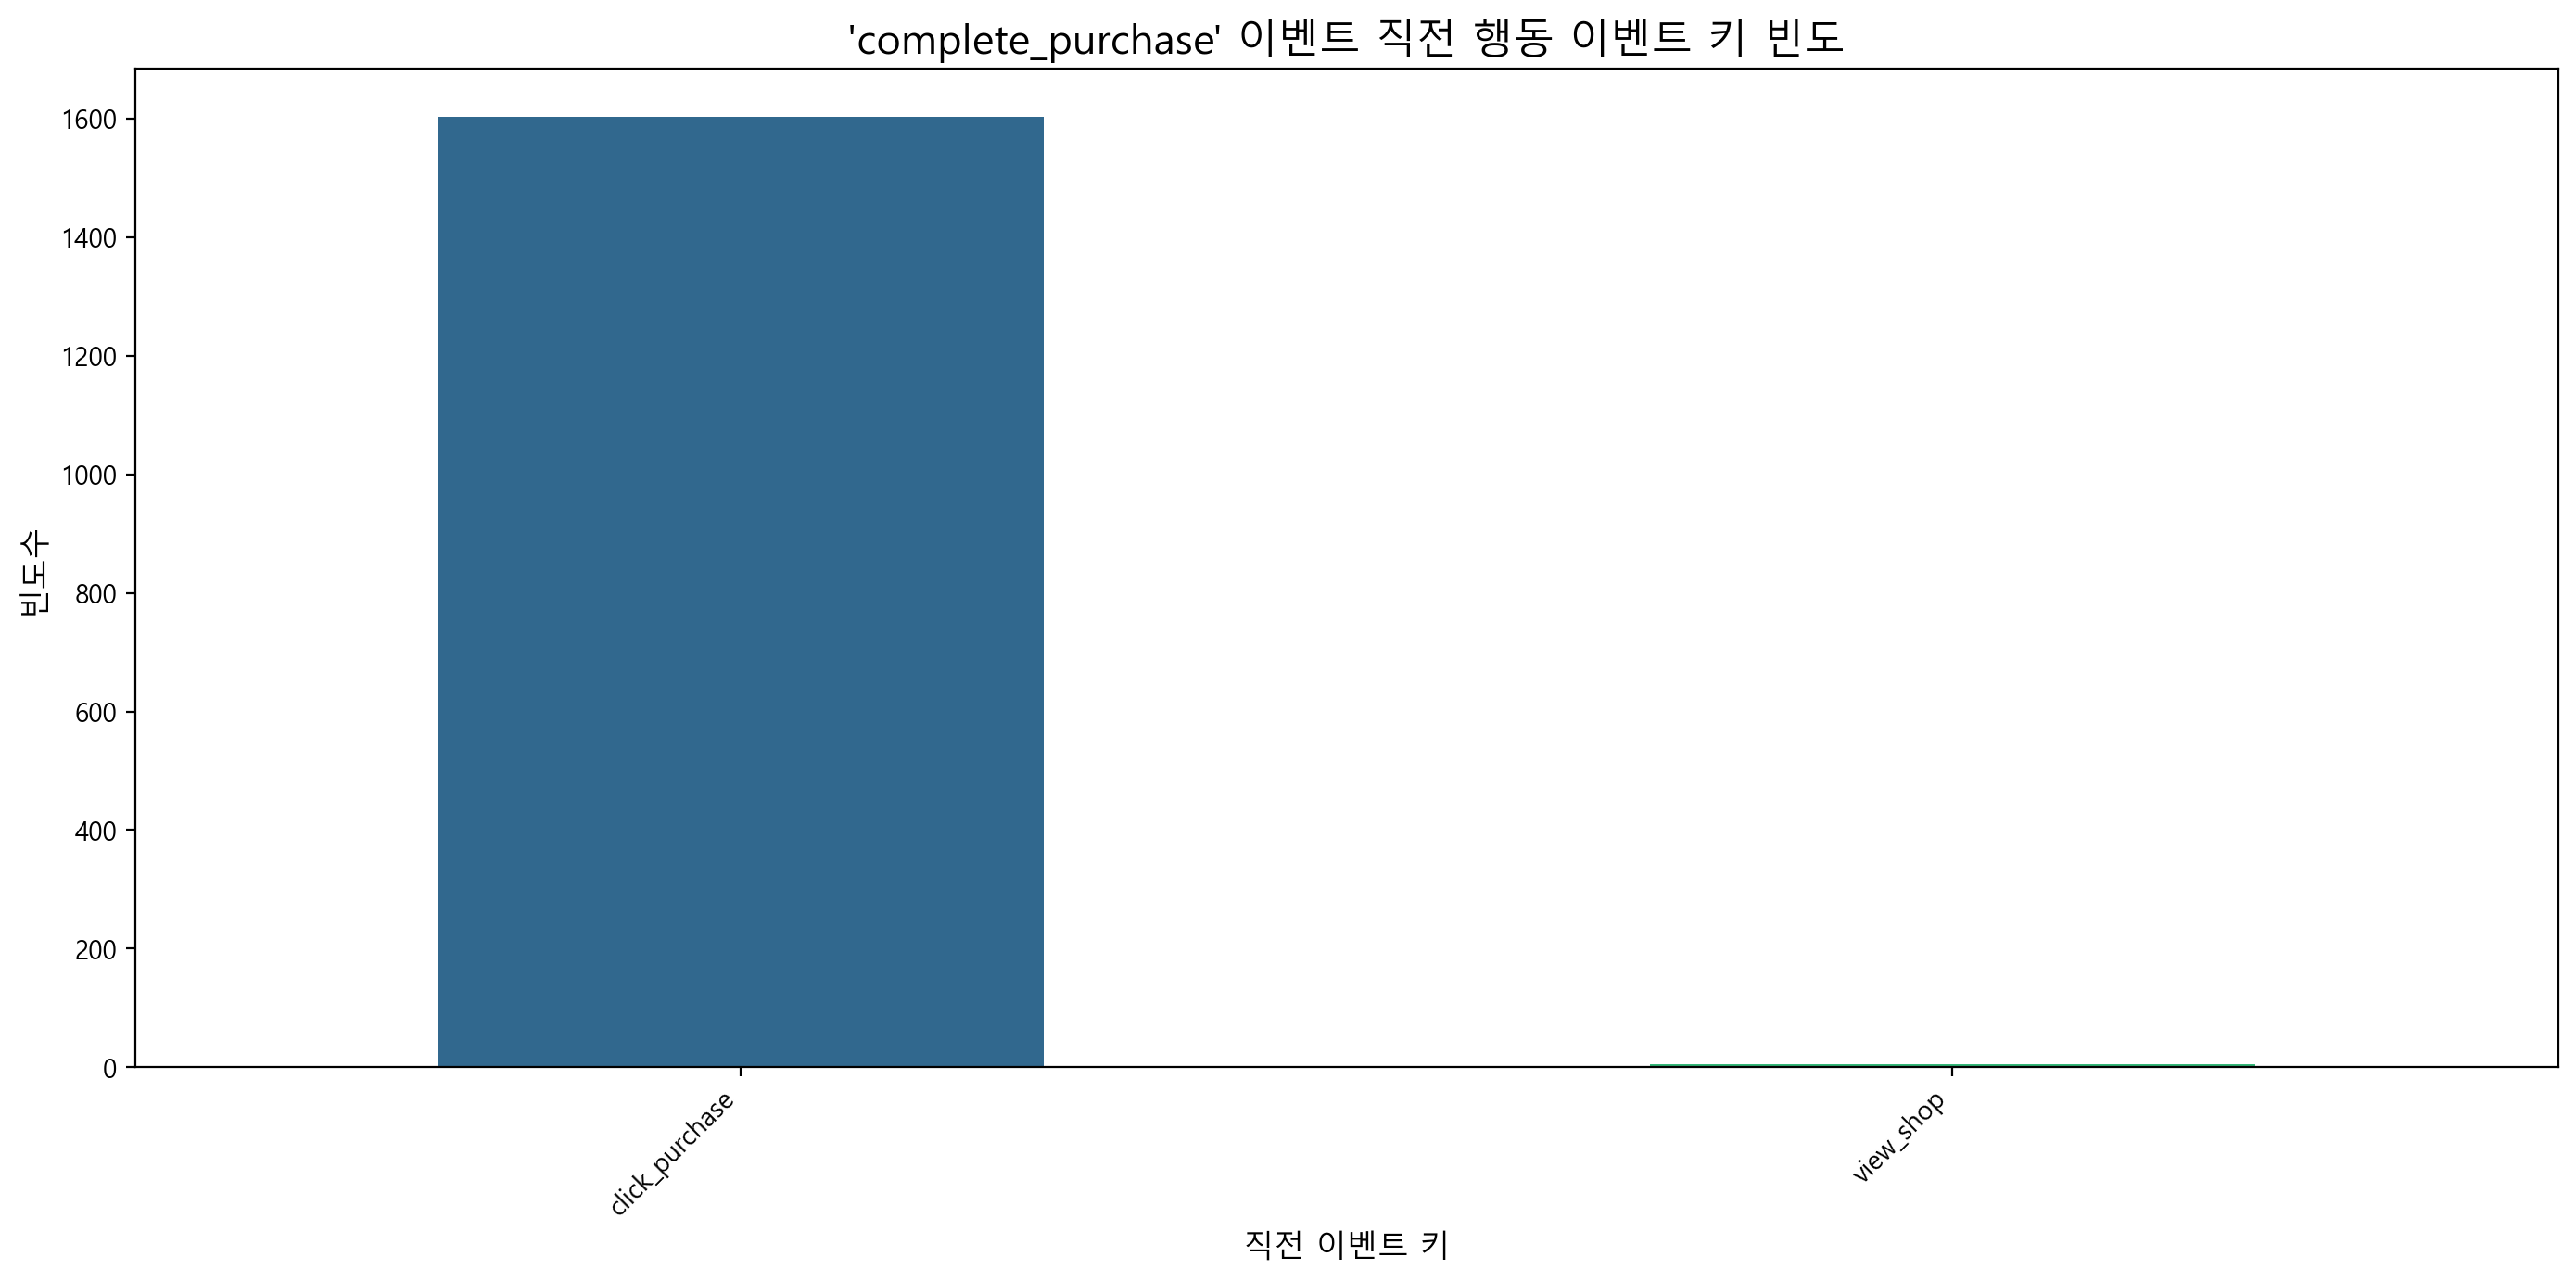


--- 3단계: 분석 결과 시각화 완료 ---

모든 요청된 작업이 완료되었습니다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # np.nan 확인을 위해 추가

# --- 0. 가정: df 데이터프레임은 이미 준비되어 있다고 가정합니다. ---
# df = df_final_sessions.copy() # 이 라인은 df가 정의되지 않았을 때만 사용하세요.


print("--- 1단계: event_category 매핑 업데이트 및 적용 시작 (NaN 값 채우기 포함) ---")

# 1.1. 이벤트 키와 카테고리 매핑 정의 (최종 재분류 적용 + NaN 값 채우기)
event_category_mapping = {
    # 📱 App 실행 및 세션 시작
    'launch_app': '📱 App 실행 및 세션 시작',
    '$session_start': '📱 App 실행 및 세션 시작',

    # 🔚 세션 종료
    '$session_end': '🔚 세션 종료',

    # 🏠 메인/홈 진입
    'view_home_tap': '🏠 메인/홈 진입',
    'view_lab_tap': '🏠 메인/홈 진입',

    # 🔽 하단 네비게이션 클릭 (누락된 이벤트 키 추가)
    'click_bottom_navigation_lab': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_profile': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_questions': '🔽 하단 네비게이션 클릭', # <--- 추가
    'click_bottom_navigation_timeline': '🔽 하단 네비게이션 클릭', # <--- 추가

    # 🔼 상단 앱바 클릭 (누락된 이벤트 키 추가)
    'click_appbar_alarm_center': '🔼 상단 앱바 클릭',
    'click_appbar_chat_rooms': '🔼 상단 앱바 클릭',
    'click_appbar_friend_plus': '🔼 상단 앱바 클릭', # <--- 추가
    'click_appbar_setting': '🔼 상단 앱바 클릭', # <--- 추가

    # 🧾 회원가입/로그인 관련
    'complete_signup': '🧾 회원가입/로그인 관련',
    'view_login': '🧾 회원가입/로그인 관련',
    'view_signup': '🧾 회원가입/로그인 관련',

    # 💰 하트/구매 관련
    'click_purchase': '💰 하트/구매 관련',
    'complete_purchase': '💰 하트/구매 관련',
    'view_shop': '💰 하트/구매 관련',

    # ❓ 질문 생성/공유/답변 등 (누락된 이벤트 키 추가)
    'click_copy_profile_link_ask': '❓ 질문 생성/공유/답변 등',
    'click_profile_ask': '❓ 질문 생성/공유/답변 등',
    'click_question_ask': '❓ 질문 생성/공유/답변 등',
    'click_question_open': '❓ 질문 생성/공유/답변 등',
    'click_question_share': '❓ 질문 생성/공유/답변 등',
    'click_question_start': '❓ 질문 생성/공유/답변 등', # <--- 추가
    'click_random_ask_normal': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_other': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_shuffle': '❓ 질문 생성/공유/답변 등',
    'complete_question': '❓ 질문 생성/공유/답변 등', # <--- 추가
    'skip_question': '❓ 질문 생성/공유/답변 등', # <--- 추가
    'view_questions_tap': '❓ 질문 생성/공유/답변 등', # <--- 추가

    # 👥 친구/소셜 기능 (누락된 이벤트 키 추가)
    'click_autoadd_contact': '👥 친구/소셜 기능',
    'click_friend_invite': '👥 친구/소셜 기능',
    'click_invite_friend': '👥 친구/소셜 기능',
    'view_friendplus_tap': '👥 친구/소셜 기능', # <--- 추가

    # 💬 채팅 기능
    'click_community_chat': '💬 채팅 기능',
    'click_timeline_chat_start': '💬 채팅 기능',

    # 🔔 알림 기능
    'click_notice': '🔔 알림 기능',
    'click_notice_detail': '🔔 알림 기능',

    # 👤 프로필/계정 관리
    'view_profile_tap': '👤 프로필/계정 관리',

    # 📰 타임라인/피드 보기
    'view_timeline_tap': '📰 타임라인/피드 보기',

    # 🛠 기타 기능/설정/유틸리티
    'button': '🛠 기타 기능/설정/유틸리티',
    'click_attendance': '🛠 기타 기능/설정/유틸리티',
    'click_copy_profile_link_profile': '🛠 기타 기능/설정/유틸리티',
}


# 1.2. 데이터프레임에 'event_category' 컬럼 재매핑
df['event_category'] = df['event_key'].map(event_category_mapping)
print("데이터프레임 'df'의 'event_category' 컬럼이 업데이트되었습니다 (NaN 값 포함).")

# 1.3. NaN 값 여부 재확인
nan_event_category_count = df['event_category'].isna().sum()
if nan_event_category_count == 0:
    print("=> 모든 'event_key'가 카테고리에 성공적으로 매핑되었습니다. NaN 값이 없습니다.")
else:
    print(f"=> 아직 매핑되지 않은 'event_key' (NaN 값)가 {nan_event_category_count}개 존재합니다.")
    print("\n매핑되지 않은 유니크 이벤트 키 및 개수:")
    print(df[df['event_category'].isna()]['event_key'].value_counts())

print("\n--- 1단계: event_category 매핑 업데이트 및 적용 완료 ---")


print("\n--- 2단계: '소비(하트 진입)' 직전 행동 분석 시작 ---")

# 2.1. '소비(하트 진입)' 이벤트 키 정의
# 채소리1님께서 정의하신 '소비' 이벤트를 여기에 지정해주세요.
# 현재는 'complete_purchase'로 설정되어 있습니다.
consumption_event_keys = ['complete_purchase']

print(f"'{', '.join(consumption_event_keys)}' 이벤트로 도달하는 직전 행동을 분석합니다.")

# 2.2. user_id 및 event_datetime 기준으로 정렬
df_sorted_for_analysis = df.sort_values(by=['session_id', 'event_datetime']).copy()

# 2.3. 각 세션 내에서 현재 이벤트의 바로 이전 이벤트 키 식별
df_sorted_for_analysis['previous_event_key_in_session'] = \
    df_sorted_for_analysis.groupby('session_id')['event_key'].shift(1)

# 2.4. 정의된 '소비(하트 진입)' 이벤트에 해당하는 행 필터링
events_leading_to_consumption = df_sorted_for_analysis[
    (df_sorted_for_analysis['event_key'].isin(consumption_event_keys)) &
    (df_sorted_for_analysis['previous_event_key_in_session'].notna())
]

# 2.5. 직전 이벤트 키들의 빈도수 계산
frequency_of_preceding_events_to_consumption = \
    events_leading_to_consumption['previous_event_key_in_session'].value_counts()

print("\n--- '소비(하트 진입)' 직전 행동 이벤트 키 빈도 분석 결과 ---")
if not frequency_of_preceding_events_to_consumption.empty:
    print(frequency_of_preceding_events_to_consumption)
    print(f"\n총 직전 행동 발생 횟수: {frequency_of_preceding_events_to_consumption.sum()}회")
else:
    print(f"'{', '.join(consumption_event_keys)}' 이벤트 이전에 발생한 이벤트를 찾을 수 없습니다.")

print("\n--- 2단계: '소비(하트 진입)' 직전 행동 분석 완료 ---")


print("\n--- 3단계: 분석 결과 시각화 시작 ---")

# 3.1. 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

# 3.2. 결과 데이터가 비어있지 않은 경우에만 시각화 수행
if not frequency_of_preceding_events_to_consumption.empty:
    # 그래프 크기 설정
    plt.figure(figsize=(14, 7))

    # 막대 그래프 생성
    frequency_of_preceding_events_to_consumption.plot(
        kind='bar',
        color=sns.color_palette('viridis', len(frequency_of_preceding_events_to_consumption))
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title(f"'{', '.join(consumption_event_keys)}' 이벤트 직전 행동 이벤트 키 빈도", fontsize=16)
    plt.xlabel("직전 이벤트 키", fontsize=12)
    plt.ylabel("빈도수", fontsize=12)

    # x축 라벨 회전 (라벨이 길어서 겹칠 경우 대비)
    plt.xticks(rotation=45, ha='right', fontsize=10)

    # 그래프 레이아웃 자동 조정
    plt.tight_layout()

    # 그래프 보여주기
    plt.show()
else:
    print("시각화할 직전 행동 빈도 데이터가 비어있어 시각화를 수행할 수 없습니다.")

print("\n--- 3단계: 분석 결과 시각화 완료 ---")

print("\n모든 요청된 작업이 완료되었습니다.")

| 이벤트 키               | 의미          |
| ------------------- | ----------- |
| `view_shop`         | 하트 상점 진입    |
| `click_purchase`    | 하트 구매 클릭    |
| `complete_purchase` | 실제 하트 구매 완료 |

- 구매 완료 직전 패턴: 사용자가 하트 구매를 완료(complete_purchase)하기 직전에는 하트 상품 클릭(click_purchase)**이 압도적으로 많습니다 (1603회).
- 하트 충전소 진입(view_shop)이 구매 완료로 직접 이어지는 경우는 매우 적습니다 (6회).

--- 다음 분석 작업 시작 ---

### 1. '소비(하트 진입)' 정의 확장 및 분석 재실행
   - 'complete_purchase' 외에 'click_purchase'와 'view_shop'을 포함하여 직전 행동 분석을 수행합니다.
분석 대상 '소비' 이벤트: 'complete_purchase, click_purchase, view_shop'

--- 확장된 '소비' 이벤트 직전 행동 이벤트 키 빈도 분석 결과 ---
previous_event_key_in_session
view_shop                            6631
click_question_open                  6610
click_attendance                     2761
click_purchase                       2068
click_bottom_navigation_questions    1819
view_questions_tap                    956
launch_app                            898
$session_start                        688
view_timeline_tap                     636
complete_question                     619
view_lab_tap                          489
click_notice_detail                   393
click_question_start                  286
click_appbar_chat_rooms               197
complete_purchase                     181
click_appbar_alarm_center             101
click_friend_invite                    81
click_question

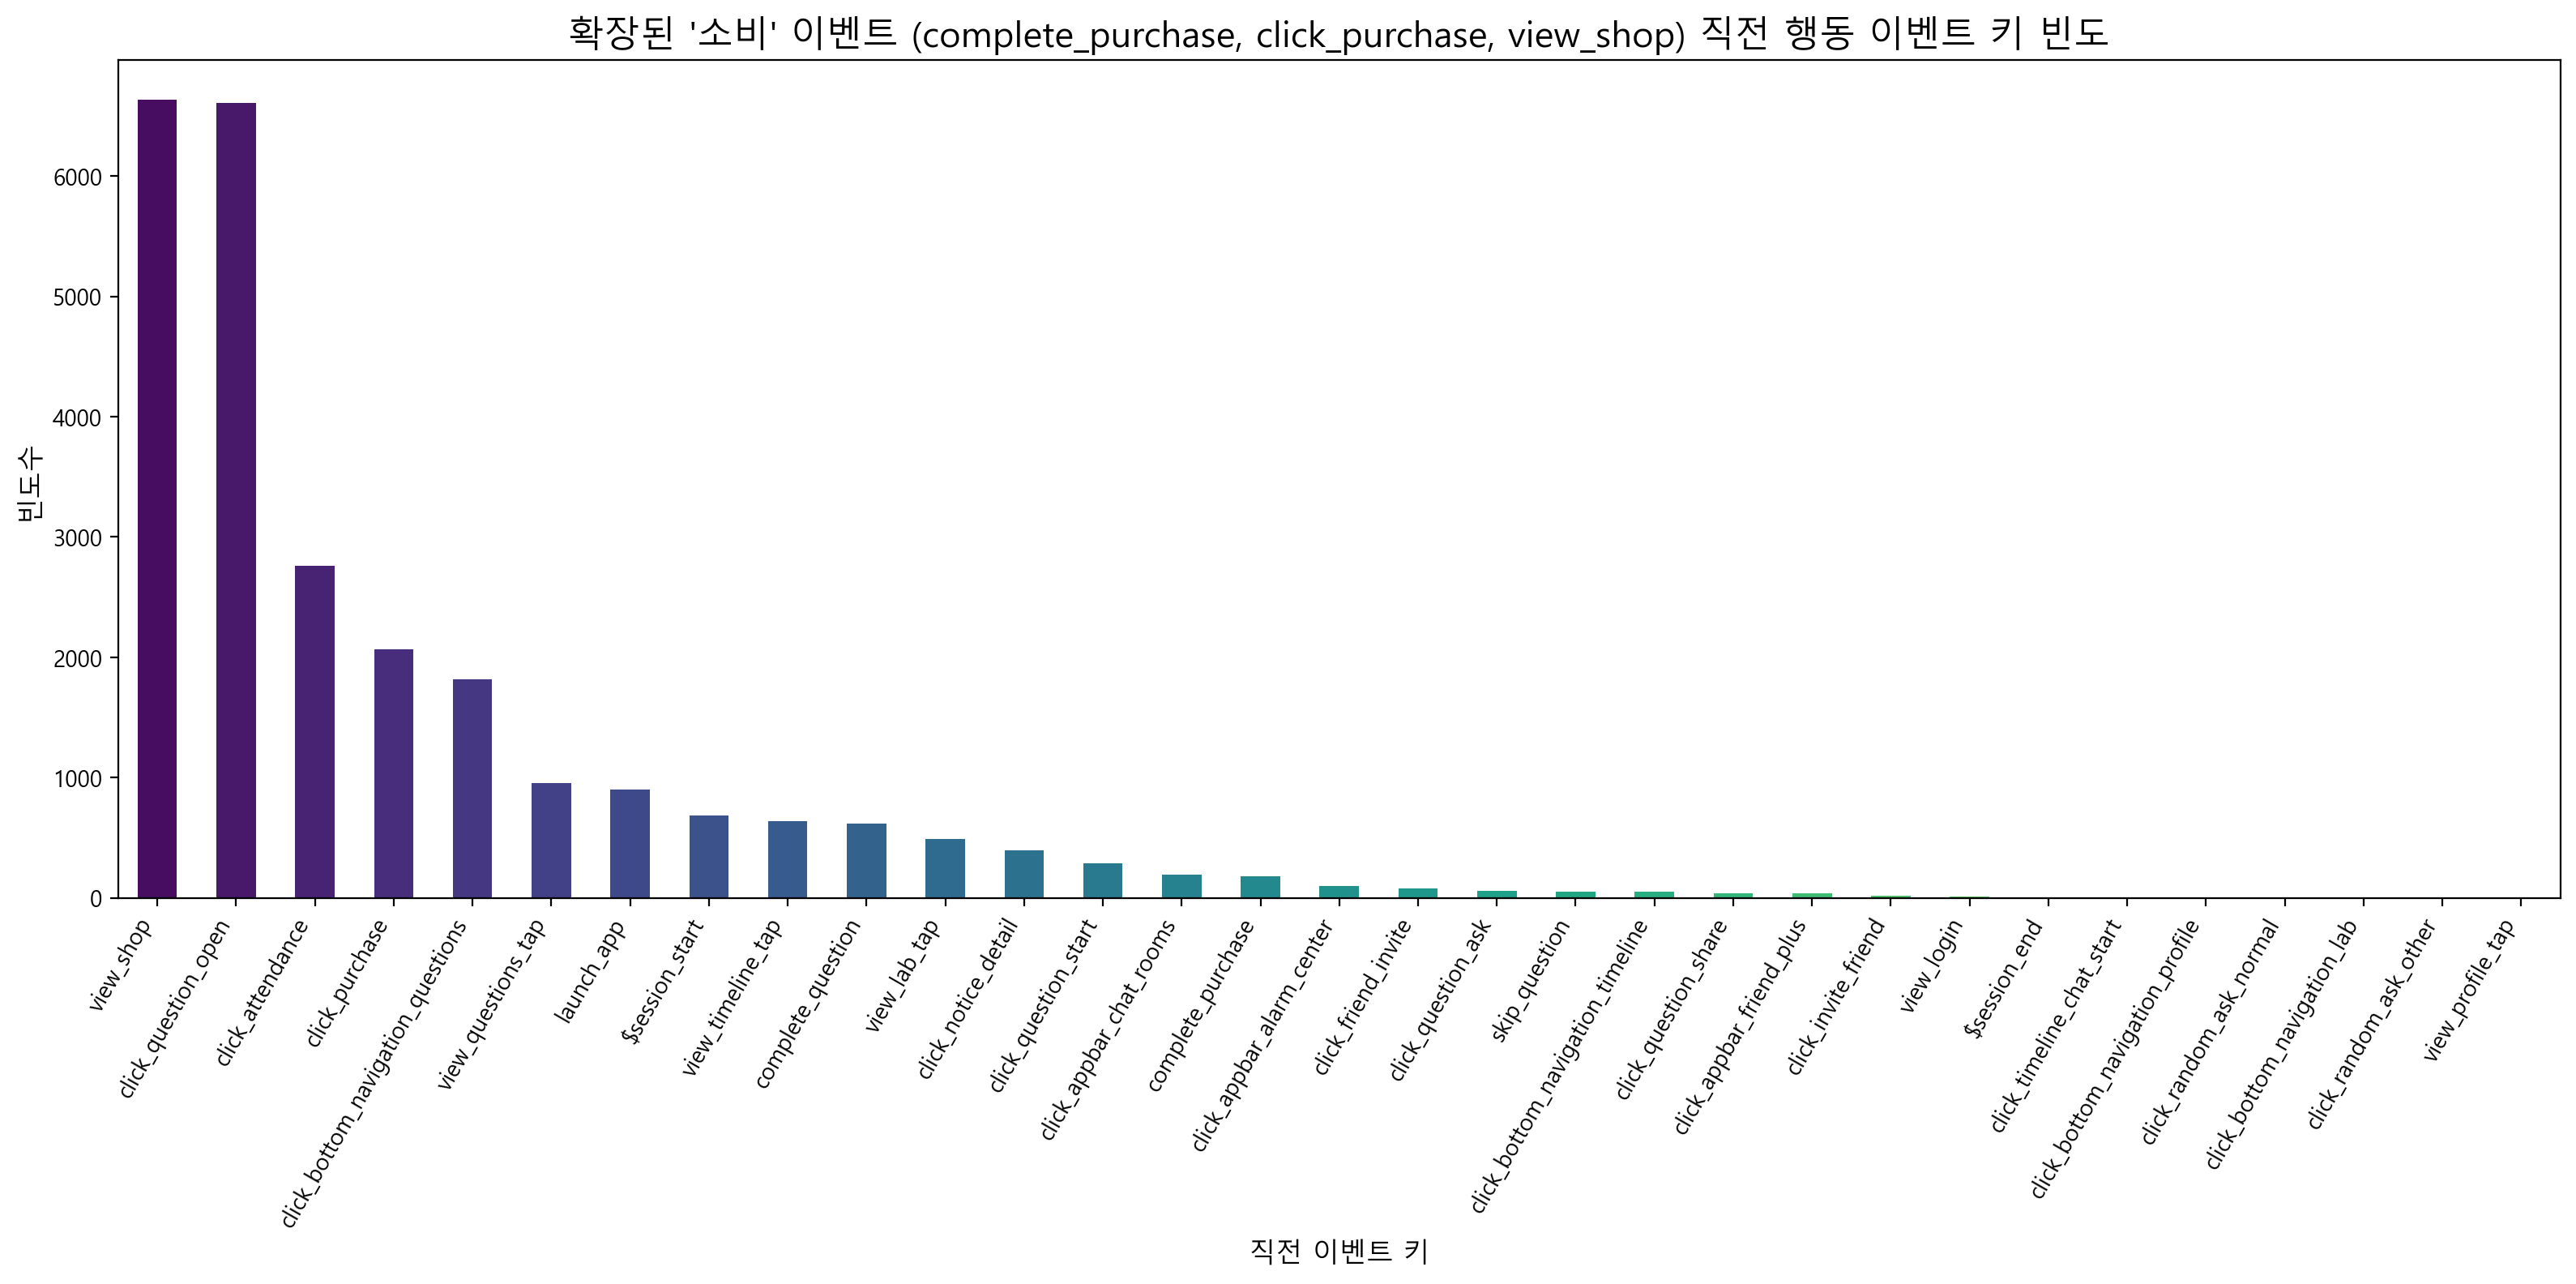

--- 분석 결과 시각화 완료 ---

### 1. 분석 작업 완료 ###


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # np.nan 확인을 위해 추가

# --- 필수 설정 (이전에 진행된 단계의 연속성을 위해) ---
# df는 이전 코드에서 event_category 컬럼이 성공적으로 추가된 데이터프레임입니다.
# (df가 정의되지 않았다면, df = df_final_sessions.copy() 등으로 초기화 필요)

# 시각화를 위한 한글 폰트 설정 (Mac/Windows에 따라 경로를 조절하거나, 코랩/주피터 환경에 맞게 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("--- 다음 분석 작업 시작 ---")

### 1. '소비(하트 진입)' 정의 확장 및 분석 재실행

print("\n### 1. '소비(하트 진입)' 정의 확장 및 분석 재실행")
print("   - 'complete_purchase' 외에 'click_purchase'와 'view_shop'을 포함하여 직전 행동 분석을 수행합니다.")

# 1.1. '소비(하트 진입)' 이벤트 키 정의 (확장된 정의)
# complete_purchase, click_purchase, view_shop을 모두 포함하여 분석
consumption_event_keys_expanded = ['complete_purchase', 'click_purchase', 'view_shop']

print(f"분석 대상 '소비' 이벤트: '{', '.join(consumption_event_keys_expanded)}'")

# 1.2. user_id 및 event_datetime 기준으로 정렬 (재확인)
df_analysis_1 = df.sort_values(by=['session_id', 'event_datetime']).copy()

# 1.3. 각 세션 내에서 현재 이벤트의 바로 이전 이벤트 키 식별
df_analysis_1['previous_event_key_in_session'] = \
    df_analysis_1.groupby('session_id')['event_key'].shift(1)

# 1.4. 정의된 '소비(하트 진입)' 이벤트에 해당하는 행 필터링
events_leading_to_consumption_expanded = df_analysis_1[
    (df_analysis_1['event_key'].isin(consumption_event_keys_expanded)) &
    (df_analysis_1['previous_event_key_in_session'].notna())
].copy() # copy()를 사용하여 SettingWithCopyWarning 방지

# 1.5. 직전 이벤트 키들의 빈도수 계산
frequency_of_preceding_events_expanded = \
    events_leading_to_consumption_expanded['previous_event_key_in_session'].value_counts()

print("\n--- 확장된 '소비' 이벤트 직전 행동 이벤트 키 빈도 분석 결과 ---")
if not frequency_of_preceding_events_expanded.empty:
    print(frequency_of_preceding_events_expanded)
    print(f"\n총 직전 행동 발생 횟수: {frequency_of_preceding_events_expanded.sum()}회")

    # 시각화
    plt.figure(figsize=(16, 8)) # 그래프 크기 확장
    frequency_of_preceding_events_expanded.plot(
        kind='bar',
        color=sns.color_palette('viridis', len(frequency_of_preceding_events_expanded))
    )
    plt.title(f"확장된 '소비' 이벤트 ({', '.join(consumption_event_keys_expanded)}) 직전 행동 이벤트 키 빈도", fontsize=16)
    plt.xlabel("직전 이벤트 키", fontsize=12)
    plt.ylabel("빈도수", fontsize=12)
    plt.xticks(rotation=60, ha='right', fontsize=10) # 라벨 회전 각도 조정
    plt.tight_layout()
    plt.show()
    print("--- 분석 결과 시각화 완료 ---")
else:
    print(f"'{', '.join(consumption_event_keys_expanded)}' 이벤트 이전에 발생한 이벤트를 찾을 수 없습니다.")

print("\n### 1. 분석 작업 완료 ###")


- ✅ 강한 연관 행동 (소비 유도 가능성 높은 흐름):
- 1. 질문 관련 이벤트 → 소비 진입

    - click_question_open, view_questions_tap, complete_question 등
    - → 사용자가 질문을 보고/참여한 직후 하트 관련 소비로 이어지는 경향이 높음.
    - → 질문 콘텐츠가 소비 행동 유도에 효과적이라는 뜻.

- 2. view_shop → 소비 이벤트로 이어짐
    - → 상점을 본 후 다시 구매로 이어지는 경우가 많음 → 상점 진입만으로도 구매 전환 가능성 ↑
    - → 상점 내부 UI/UX 최적화의 가치 큼.

- 3. click_attendance (출석 체크)
    - → 보상성 기능(출석 등)이 소비 유도에 연결됨.
    - → 출석 후 바로 하트 부족을 느껴 구매로 이어질 수 있음.
    - → 리워드 후 하트 소비 유도 흐름 강화 고려.

- 4. launch_app / $session_start
    - → 앱 실행 직후 바로 소비로 이어진 사용자도 다수
    - → 이는 정해진 목적(구매)을 가지고 앱을 켠 유저로 보일 수 있음 (intent-driven)
    - → 이런 사용자는 홈 진입 전 쇼핑몰 진입 유도도 가능.



| 인사이트             | 개선 아이디어                      |
| ---------------- | ---------------------------- |
| 질문 콘텐츠 후 소비 진입↑  | 질문 후 하트 부족 알림, 하트 프로모션 배너 제안 |
| 출석 체크 후 소비 진입↑   | 출석 리워드 수령 후 하트 할인 유도 팝업      |
| 앱 실행 직후 소비 진입 존재 | 앱 시작 시 상점 or 프로모션 노출 테스트 가능  |
| 상점 반복 진입 및 구매    | 상점 내부 UX 개선 또는 하트 묶음 상품 테스트  |


## 하트/구매 관련 활동 직전 행동 확장 분석

- 목적 : "사용자들이 하트 소비 행동을 하기 직전에 어떤 '카테고리의 행동'을 했는가?"를 파악하는 것
- 즉, 개별 이벤트 이름(key)이 아니라, 더 넓은 **행동 유형(category)**으로 묶어, 전반적인 사용자 흐름을 구조적으로 파악하고, 소비를 유도하는 상위 레벨 행동 유형이 무엇인지 이해하는 것이 목적입니다.


### 2. 직전 이벤트 '카테고리' 분석
   - '소비(하트 진입)' 이벤트 직전에 발생한 '이벤트 카테고리'들의 빈도를 분석하고 시각화합니다.

--- '소비' 이벤트 직전 행동 '카테고리' 빈도 분석 결과 ---
previous_event_category_in_session
💰 하트/구매 관련          8880
❓ 질문 생성/공유/답변 등     8628
🛠 기타 기능/설정/유틸리티     2761
🔽 하단 네비게이션 클릭       1878
📱 App 실행 및 세션 시작    1586
📰 타임라인/피드 보기         636
🏠 메인/홈 진입            489
🔔 알림 기능              393
🔼 상단 앱바 클릭           335
👥 친구/소셜 기능            98
🧾 회원가입/로그인 관련         14
🔚 세션 종료                6
💬 채팅 기능                3
👤 프로필/계정 관리            1
Name: count, dtype: int64

총 직전 행동 카테고리 발생 횟수: 25708회


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 128736 (\N{HAMMER AND WRENCH}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 128317 (\N{DOWN-POINTING SMALL RED TRIANGLE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\674524790.py:114: UserWarning:

Glyph 128240 (\N{NEWSPAPER}) missing from font(s) Malg

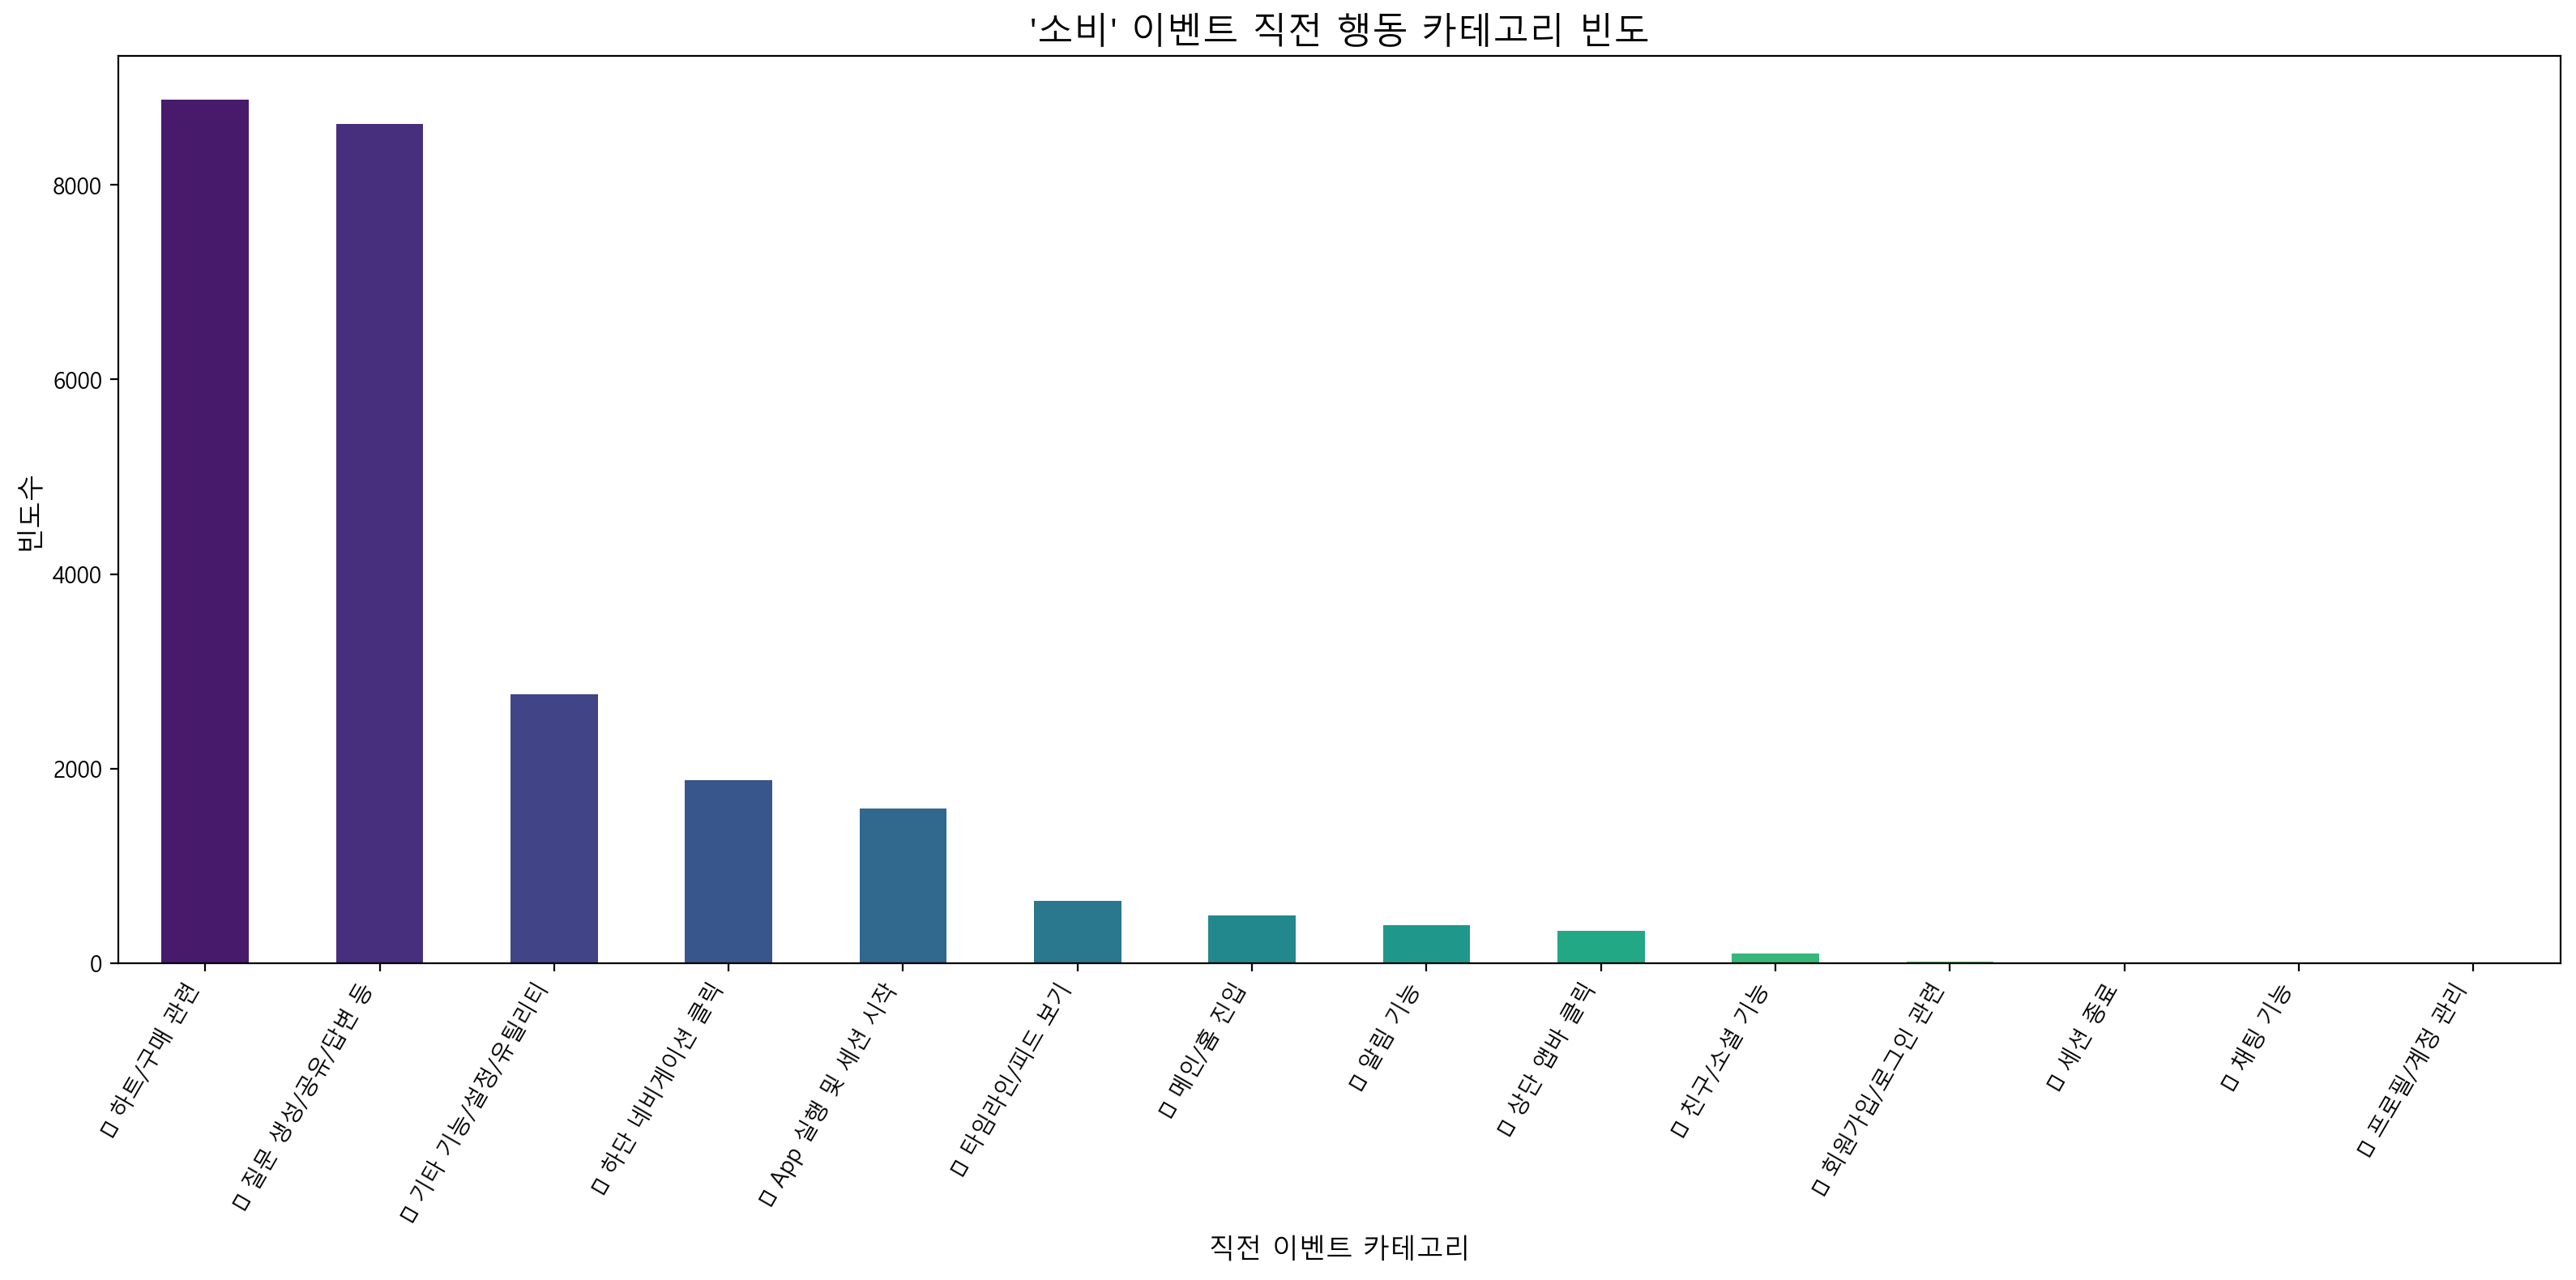

--- 분석 결과 시각화 완료 ---

### 2. 분석 작업 완료 ###


In [ ]:
### 2. 직전 이벤트 '카테고리' 분석

print("\n### 2. 직전 이벤트 '카테고리' 분석")
print("   - '소비(하트 진입)' 이벤트 직전에 발생한 '이벤트 카테고리'들의 빈도를 분석하고 시각화합니다.")

# 2.1. (재확인) 최종 event_category_mapping 딕셔너리 정의
# 이 딕셔너리는 이전에 '1단계: event_category 매핑 업데이트' 코드에서 df에 적용한 것과 동일해야 합니다.
# 이 코드 블록에서 직접 df['event_category']를 사용하므로 딕셔너리 자체는 실행하지 않아도 됩니다.
# 다만, previous_event_key_in_session의 카테고리를 찾기 위해 다시 필요합니다.
# 안전을 위해 가장 최신 매핑 딕셔너리를 여기에 명시해 줍니다.
event_category_mapping_final = {
    # 📱 App 실행 및 세션 시작
    'launch_app': '📱 App 실행 및 세션 시작',
    '$session_start': '📱 App 실행 및 세션 시작',

    # 🔚 세션 종료
    '$session_end': '🔚 세션 종료',

    # 🏠 메인/홈 진입
    'view_home_tap': '🏠 메인/홈 진입',
    'view_lab_tap': '🏠 메인/홈 진입',

    # 🔽 하단 네비게이션 클릭
    'click_bottom_navigation_lab': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_profile': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_questions': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_timeline': '🔽 하단 네비게이션 클릭',

    # 🔼 상단 앱바 클릭
    'click_appbar_alarm_center': '🔼 상단 앱바 클릭',
    'click_appbar_chat_rooms': '🔼 상단 앱바 클릭',
    'click_appbar_friend_plus': '🔼 상단 앱바 클릭',
    'click_appbar_setting': '🔼 상단 앱바 클릭',

    # 🧾 회원가입/로그인 관련
    'complete_signup': '🧾 회원가입/로그인 관련',
    'view_login': '🧾 회원가입/로그인 관련',
    'view_signup': '🧾 회원가입/로그인 관련',

    # 💰 하트/구매 관련
    'click_purchase': '💰 하트/구매 관련',
    'complete_purchase': '💰 하트/구매 관련',
    'view_shop': '💰 하트/구매 관련',

    # ❓ 질문 생성/공유/답변 등
    'click_copy_profile_link_ask': '❓ 질문 생성/공유/답변 등',
    'click_profile_ask': '❓ 질문 생성/공유/답변 등',
    'click_question_ask': '❓ 질문 생성/공유/답변 등',
    'click_question_open': '❓ 질문 생성/공유/답변 등',
    'click_question_share': '❓ 질문 생성/공유/답변 등',
    'click_question_start': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_normal': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_other': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_shuffle': '❓ 질문 생성/공유/답변 등',
    'complete_question': '❓ 질문 생성/공유/답변 등',
    'skip_question': '❓ 질문 생성/공유/답변 등',
    'view_questions_tap': '❓ 질문 생성/공유/답변 등',

    # 👥 친구/소셜 기능
    'click_autoadd_contact': '👥 친구/소셜 기능',
    'click_friend_invite': '👥 친구/소셜 기능',
    'click_invite_friend': '👥 친구/소셜 기능',
    'view_friendplus_tap': '👥 친구/소셜 기능',

    # 💬 채팅 기능
    'click_community_chat': '💬 채팅 기능',
    'click_timeline_chat_start': '💬 채팅 기능',

    # 🔔 알림 기능
    'click_notice': '🔔 알림 기능',
    'click_notice_detail': '🔔 알림 기능',

    # 👤 프로필/계정 관리
    'view_profile_tap': '👤 프로필/계정 관리',

    # 📰 타임라인/피드 보기
    'view_timeline_tap': '📰 타임라인/피드 보기',

    # 🛠 기타 기능/설정/유틸리티
    'button': '🛠 기타 기능/설정/유틸리티',
    'click_attendance': '🛠 기타 기능/설정/유틸리티',
    'click_copy_profile_link_profile': '🛠 기타 기능/설정/유틸리티',
}


# 2.2. (1번 분석에서 사용된) events_leading_to_consumption_expanded 데이터프레임 활용
#      이 데이터프레임에는 이미 'previous_event_key_in_session'이 포함되어 있습니다.
#      만약 1번을 건너뛰고 2번만 실행한다면 1.2~1.4 단계를 다시 수행하여
#      events_leading_to_consumption_expanded를 만들어야 합니다.

# 직전 이벤트 키의 event_category를 매핑하여 새로운 컬럼 생성
events_leading_to_consumption_expanded['previous_event_category_in_session'] = \
    events_leading_to_consumption_expanded['previous_event_key_in_session'].map(event_category_mapping_final)

# 2.3. 직전 이벤트 '카테고리'들의 빈도수 계산
frequency_of_preceding_categories = \
    events_leading_to_consumption_expanded['previous_event_category_in_session'].value_counts()

print("\n--- '소비' 이벤트 직전 행동 '카테고리' 빈도 분석 결과 ---")
if not frequency_of_preceding_categories.empty:
    print(frequency_of_preceding_categories)
    print(f"\n총 직전 행동 카테고리 발생 횟수: {frequency_of_preceding_categories.sum()}회")

    # 시각화
    plt.figure(figsize=(16, 8))
    frequency_of_preceding_categories.plot(
        kind='bar',
        color=sns.color_palette('viridis', len(frequency_of_preceding_categories))
    )
    plt.title(f"'소비' 이벤트 직전 행동 카테고리 빈도", fontsize=16)
    plt.xlabel("직전 이벤트 카테고리", fontsize=12)
    plt.ylabel("빈도수", fontsize=12)
    plt.xticks(rotation=60, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("--- 분석 결과 시각화 완료 ---")
else:
    print("분석할 '소비' 이벤트 직전 카테고리 데이터를 찾을 수 없습니다.")

print("\n### 2. 분석 작업 완료 ###")

---

- 해석

    - 1. 가장 많은 전환 유도 경로는 '질문 관련 콘텐츠'
        - **❓ 질문 카테고리 (8,628건)**은 **전체의 약 33.5%**를 차지

        - 이는 질문 콘텐츠 → 하트 소비 흐름이 매우 강력하다는 것을 보여줌

        - 즉, 사용자가 질문을 보고 난 뒤, 하트가 필요해지는 UX 흐름이 존재

    - 📌 활용 방안:

        - 질문 관련 UX에서 하트 부족 시점에 적절한 소비 유도 (예: 구매 버튼 노출, 하트 알림, 혜택 팝업)

    - 2. 소비 자체 반복 경로 존재
        - **💰 하트/구매 관련 (8,880건)**이 가장 많음
        - → view_shop → click_purchase → 다시 view_shop 등
        - → 사용자들이 구매 동선 내에서 여러 번 시도하는 흐름을 보여줌

    - 📌 활용 방안:

        - 상점 내 구매 UI/UX 최적화 필요 (예: 불필요한 반복 줄이기)

        - 실패 구매 로그가 섞여 있다면 → 구매 실패 원인 분석 필요

    - 3. 출석체크 및 기타 유틸리티에서의 소비 유도
        - 🛠 기타 기능 (2,761건) 중 상당수는 click_attendance (출석 체크)

        - 즉, 리워드를 받은 뒤 바로 소비 행동으로 이어지는 흐름 있음

    - 📌 활용 방안:

        - 출석 보상 후 하트 부족 알림 → 구매 CTA 연결

        - “받은 하트로 더 즐기세요!” 식의 UX 메시지 설계

    - 4. 앱 실행 직후, 홈 진입 직후 소비
        - 앱을 키자마자 소비하는 유저가 많음 (📱 App 실행 1,586건)

        - 홈에서 소비 진입하는 경우도 적지 않음 (🏠 홈 진입 489건)

    - 📌 활용 방안:

        - 앱 실행 직후 구매 동기 유도 → 진입 시점에 맞춘 상점 프로모션 가능

        - 홈에 ‘하트 부족 시 배너’ 배치 테스트 가능

    - 5. 저빈도지만 주목할 흐름
        - 🔔 알림 → 소비도 393건 존재
        - → 특정 알림이 소비로 이어졌을 가능성 있음
        - → 알림 A/B 테스트로 효율 높은 알림 유형 파악 가능

        - 👥 친구/소셜 기능은 98건 → 소비 전환률은 낮지만,
        - → 친구 관련 기능이 소비 유도로 이어지는 UX 기획 여지 있음

- 인사이트

| 요약 포인트              | 설명                           |
| ------------------- | ---------------------------- |
| ✅ 질문 콘텐츠 → 소비 전환력 ↑ | 전체의 33% 이상, 주요 유도 동선         |
| ✅ 출석/유틸리티 → 소비 연결   | 하트 수급 직후 소비 흐름 존재            |
| ✅ 구매 흐름 내 반복 많음     | 구매 시도 중단 원인도 함께 분석 필요        |
| ✅ 앱 실행 직후 전환 유저 존재  | intent-driven 유저 세그먼트로 분리 가능 |
| ✅ 알림 기능 등에서 전환도 확인됨 | 메시지 최적화로 전환 유도 가능            |


## 하트 구매 과정에 대한 사용자 여정 파악을 위한 퍼널 분석

In [ ]:
### 4. 사용자 여정(User Journey) 및 퍼널(Funnel) 분석 시작

print("\n### 4. 사용자 여정(User Journey) 및 퍼널(Funnel) 분석 시작")
print("   - '하트 구매' 퍼널의 각 단계별 전환율을 계산하는 기본적인 예시입니다.")

# 4.1. 퍼널 단계 정의 (예시: 하트 충전소 진입 -> 하트 상품 클릭 -> 하트 구매 완료)
funnel_steps = ['view_shop', 'click_purchase', 'complete_purchase']

print(f"분석할 퍼널: {' -> '.join(funnel_steps)}")

# 4.2. 각 유저가 퍼널의 각 단계를 완료했는지 확인
# 각 유저 ID별로, 각 퍼널 단계 이벤트가 발생했는지 확인
user_funnel_status = pd.DataFrame(index=df['user_id'].unique())
user_funnel_status['user_id'] = user_funnel_status.index # user_id 컬럼 추가

for step in funnel_steps:
    # 해당 스텝 이벤트를 발생시킨 유저 ID 목록
    users_at_step = df[df['event_key'] == step]['user_id'].unique()
    # 유저 ID 목록을 기반으로 해당 스텝을 완료했는지 여부를 True/False로 표시
    user_funnel_status[step] = user_funnel_status['user_id'].isin(users_at_step)

# 4.3. 순차적인 퍼널 완료 여부 확인 (최소한의 순서 보장)
# 각 사용자의 이벤트를 시간 순으로 정렬한 후 각 단계 이벤트를 거쳤는지 확인합니다.
# 여기서는 퍼널을 "방문"한 유저 수 기준 전환율을 계산합니다.
# 정확한 순서 보장 및 시퀀스 분석을 위해서는 더 복잡한 로직이 필요할 수 있습니다.

# 첫 번째 단계 진입자 수 (시작점)
total_users_at_start = user_funnel_status[funnel_steps[0]].sum()
print(f"\n--- 퍼널 분석 결과 ({funnel_steps[0]} 기준) ---")
print(f"1. {funnel_steps[0]} 진입 유저 수: {int(total_users_at_start)}명")

if total_users_at_start > 0:
    previous_step_users = total_users_at_start
    for i in range(1, len(funnel_steps)):
        current_step = funnel_steps[i]
        # 이전 단계까지 진입한 유저 중 현재 단계까지 진입한 유저 수
        users_up_to_current_step = user_funnel_status[
            (user_funnel_status[funnel_steps[i-1]] == True) &
            (user_funnel_status[current_step] == True)
        ].shape[0]

        conversion_rate_from_prev = (users_up_to_current_step / previous_step_users) * 100 if previous_step_users > 0 else 0
        conversion_rate_from_start = (users_up_to_current_step / total_users_at_start) * 100 if total_users_at_start > 0 else 0

        print(f"   -> {i+1}. {current_step} 진입 유저 수: {int(users_up_to_current_step)}명")
        print(f"      - 이전 단계 대비 전환율: {conversion_rate_from_prev:.2f}%")
        print(f"      - 첫 단계 대비 전환율: {conversion_rate_from_start:.2f}%")
        previous_step_users = users_up_to_current_step
else:
    print("퍼널의 첫 단계를 시작한 사용자가 없습니다.")


print("\n### 4. 분석 작업 완료 ###")

print("\n--- 모든 분석 작업 완료 ---")


### 4. 사용자 여정(User Journey) 및 퍼널(Funnel) 분석 시작
   - '하트 구매' 퍼널의 각 단계별 전환율을 계산하는 기본적인 예시입니다.
분석할 퍼널: view_shop -> click_purchase -> complete_purchase

--- 퍼널 분석 결과 (view_shop 기준) ---
1. view_shop 진입 유저 수: 12031명
   -> 2. click_purchase 진입 유저 수: 4633명
      - 이전 단계 대비 전환율: 38.51%
      - 첫 단계 대비 전환율: 38.51%
   -> 3. complete_purchase 진입 유저 수: 1230명
      - 이전 단계 대비 전환율: 26.55%
      - 첫 단계 대비 전환율: 10.22%

### 4. 분석 작업 완료 ###

--- 모든 분석 작업 완료 ---


| 퍼널 단계              | 유저 수    | 이전 단계 대비 전환율 | 첫 단계 대비 전환율 |
| ------------------ | ------- | ------------ | ----------- |
| view\_shop         | 12,031명 | -            | -           |
| click\_purchase    | 4,633명  | 38.51%       | 38.51%      |
| complete\_purchase | 1,230명  | 26.55%       | 10.22%      |


- 해석:
    - 하트 상점에 방문한 사용자 중 약 **38.5%**가 실제로 상품을 클릭했고,

    - 클릭한 사람 중 약 **26.5%**가 실제로 하트를 구매했습니다.

    - **전체 상점 방문자 중 약 10.2%**만이 실제 구매까지 이어졌습니다.

## 질문 생성 카테고리 연계 분석


### 2.1. '❓ 질문 생성/공유/답변 등' 카테고리 연계 분석 시작 ###
   - '소비(하트 진입)' 직전에 '❓ 질문 생성/공유/답변 등' 카테고리가 온 경우, 그 구체적인 이벤트 키 빈도를 분석합니다.

--- '소비' 이벤트 직전 '❓ 질문 생성/공유/답변 등' 카테고리 내 이벤트 키 빈도 ---
previous_event_key_in_session
click_question_open        6610
view_questions_tap          956
complete_question           619
click_question_start        286
click_question_ask           59
skip_question                55
click_question_share         40
click_random_ask_normal       2
click_random_ask_other        1
Name: count, dtype: int64

총 발생 횟수: 8628회


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\1995335031.py:32: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

c:\Users\PC\anaconda3\envs\codeit_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.



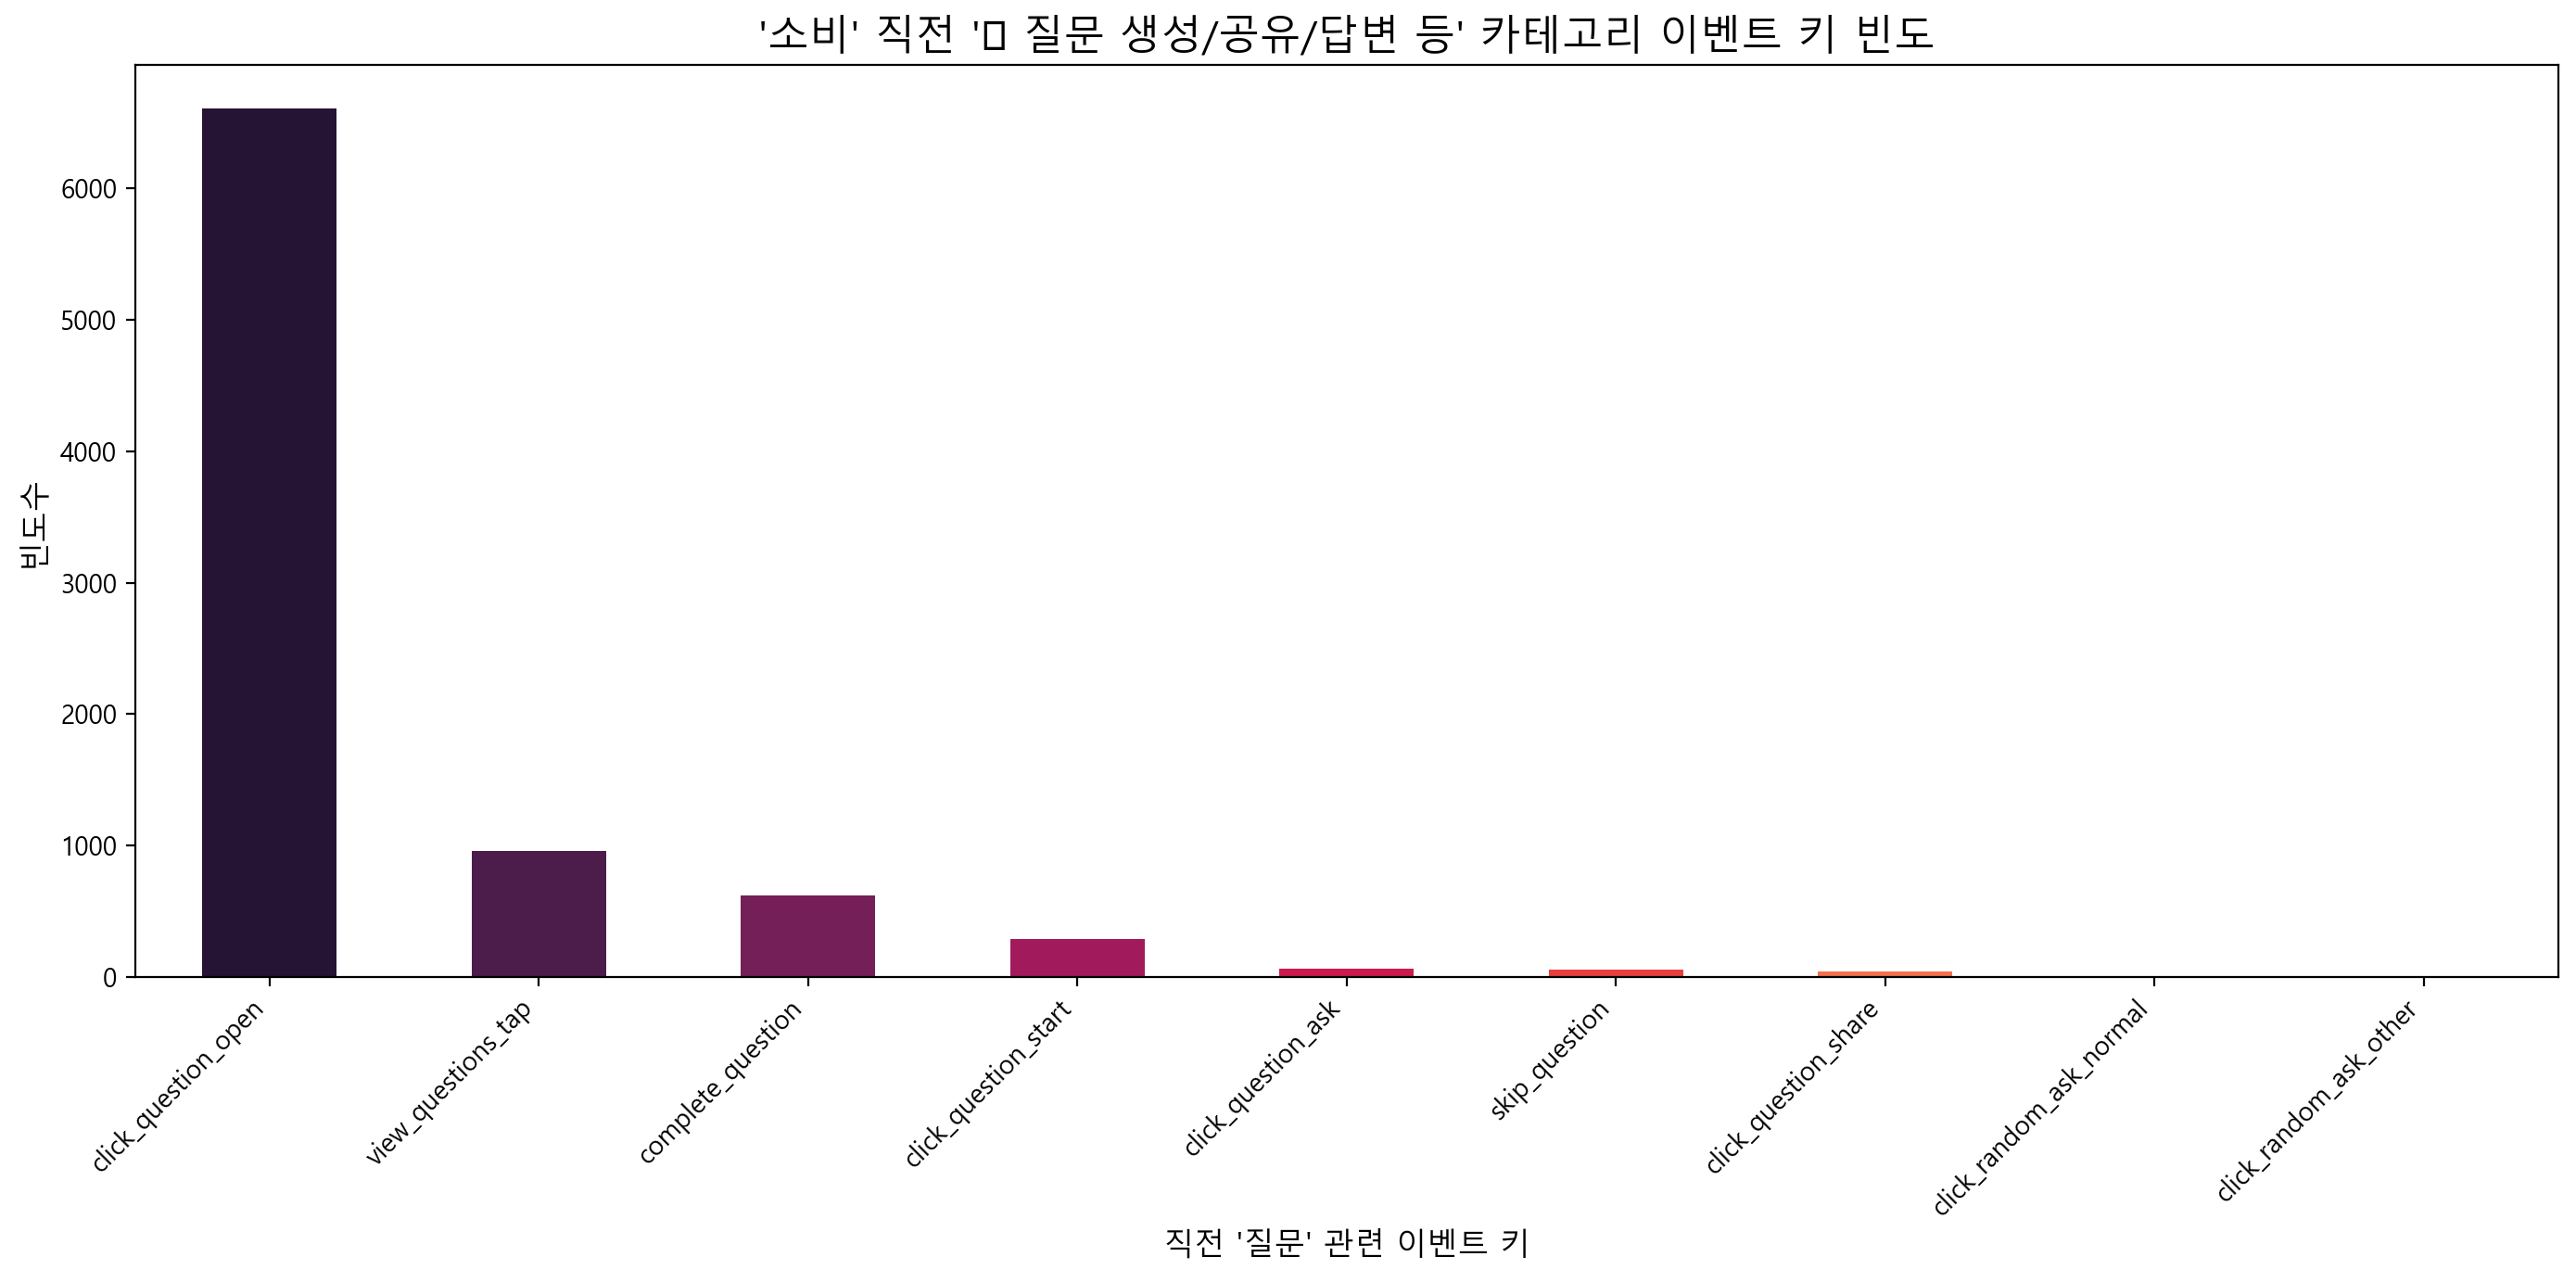

--- 분석 결과 시각화 완료 ---

### 2.1. '❓ 질문 생성/공유/답변 등' 카테고리 연계 분석 완료 ###


In [ ]:
### 2.1. '❓ 질문 생성/공유/답변 등' 카테고리 연계 분석

print("\n### 2.1. '❓ 질문 생성/공유/답변 등' 카테고리 연계 분석 시작 ###")
print("   - '소비(하트 진입)' 직전에 '❓ 질문 생성/공유/답변 등' 카테고리가 온 경우, 그 구체적인 이벤트 키 빈도를 분석합니다.")



# 2.1.2. '소비' 이벤트 직전 카테고리가 '❓ 질문 생성/공유/답변 등' 인 경우만 필터링합니다.
events_preceded_by_question_category = events_leading_to_consumption_expanded[
    events_leading_to_consumption_expanded['previous_event_category_in_session'] == '❓ 질문 생성/공유/답변 등'
].copy()

# 2.1.3. 해당 케이스에서의 직전 이벤트 키 빈도수를 계산합니다.
frequency_of_specific_question_events = \
    events_preceded_by_question_category['previous_event_key_in_session'].value_counts()

print("\n--- '소비' 이벤트 직전 '❓ 질문 생성/공유/답변 등' 카테고리 내 이벤트 키 빈도 ---")
if not frequency_of_specific_question_events.empty:
    print(frequency_of_specific_question_events)
    print(f"\n총 발생 횟수: {frequency_of_specific_question_events.sum()}회")

    # 시각화
    plt.figure(figsize=(14, 7))
    frequency_of_specific_question_events.plot(
        kind='bar',
        color=sns.color_palette('rocket', len(frequency_of_specific_question_events))
    )
    plt.title(f"'소비' 직전 '❓ 질문 생성/공유/답변 등' 카테고리 이벤트 키 빈도", fontsize=16)
    plt.xlabel("직전 '질문' 관련 이벤트 키", fontsize=12)
    plt.ylabel("빈도수", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("--- 분석 결과 시각화 완료 ---")
else:
    print("해당하는 패턴이 없습니다.")

print("\n### 2.1. '❓ 질문 생성/공유/답변 등' 카테고리 연계 분석 완료 ###")

- 총 8,628건의 '질문' 관련 활동이 '소비'(하트/구매 관련 활동)로 직접 이어졌습니다. 이 중 대다수는 특정 몇몇 이벤트 키에 집중되어 있습니다.

    - 압도적 1위: click_question_open (6,610회)

        - 이것은 '질문 생성/공유/답변' 카테고리 내에서 사용자가 하트/구매 행동으로 전환하는 가장 결정적인 순간이 '질문을 열어 확인하는 것'임을 명확히 보여줍니다.
    - 주요 2, 3위: view_questions_tap (956회), complete_question (619회)

        - '질문 화면을 둘러보는 행위'나 '질문 생성을 완료하는 행위'도 하트/구매 활동으로 이어지는 중요한 지점입니다.
    - 그 외: click_question_start (286회), click_question_ask (59회) 등

        - 이벤트 발생 수는 상대적으로 적지만, 질문을 시작하거나 직접 질문을 시도하는 과정에서도 하트/구매 필요성이 발생합니다.
    - 매우 낮은 연관성: skip_question (55회), click_question_share (40회) 등

        - 질문을 건너뛰거나 공유하는 행동은 하트/구매로의 연결 빈도가 매우 낮습니다.

- 결론적으로, '질문' 기능은 하트 구매와 강하게 연결되어 있으며, 특히 사용자가 질문의 내용을 적극적으로 탐색하거나 상호작용하려는 시점에 하트가 필요하다는 점을 인지하게 됩니다. 이는 하트 구매를 유도하기 위한 UX/UI 개선 및 마케팅 전략 수립에 핵심적인 단서가 됩니다.

## 주요 사용자 추출

- 전체 사용자 중 이벤트 수가 상위 10% 이상인 사용자를 "주요 사용자"로 분류.

### 일반 사용자 vs. 주요 사용자 행동 차이 비교 분석 시작 ###

--- 1. 사용자 그룹 정의 ---
전체 사용자 수: 169115명
주요 사용자 수: 17140명 (총 이벤트 수: 2771603개)
일반 사용자 수: 151975명 (총 이벤트 수: 3558264개)

--- 1. 사용자 그룹 정의 완료 ---

--- 2. 이벤트 카테고리 분포 비교 ---

2.1. 각 사용자 그룹의 이벤트 카테고리별 활동 비율 (%):
                   주요 사용자  일반 사용자
event_category                  
🔽 하단 네비게이션 클릭      22.22   24.78
📱 App 실행 및 세션 시작   16.62   20.69
❓ 질문 생성/공유/답변 등    15.30   11.74
🏠 메인/홈 진입          12.58   12.31
📰 타임라인/피드 보기       12.27   11.66
🔚 세션 종료             7.69    5.13
👤 프로필/계정 관리         4.41    4.22
🔼 상단 앱바 클릭          4.02    5.08
🛠 기타 기능/설정/유틸리티     2.31    0.90
🔔 알림 기능             1.21    2.01
💰 하트/구매 관련          0.49    0.34
💬 채팅 기능             0.45    0.46
🧾 회원가입/로그인 관련       0.36    0.64
👥 친구/소셜 기능          0.07    0.02


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 128317 (\N{DOWN-POINTING SMALL RED TRIANGLE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 128240 (\N{NEWSPAPER}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\756545558.py:91: UserWarning:

Glyph 128282 (\N{END WITH LEFTWARDS ARROW ABOVE}) missing from 

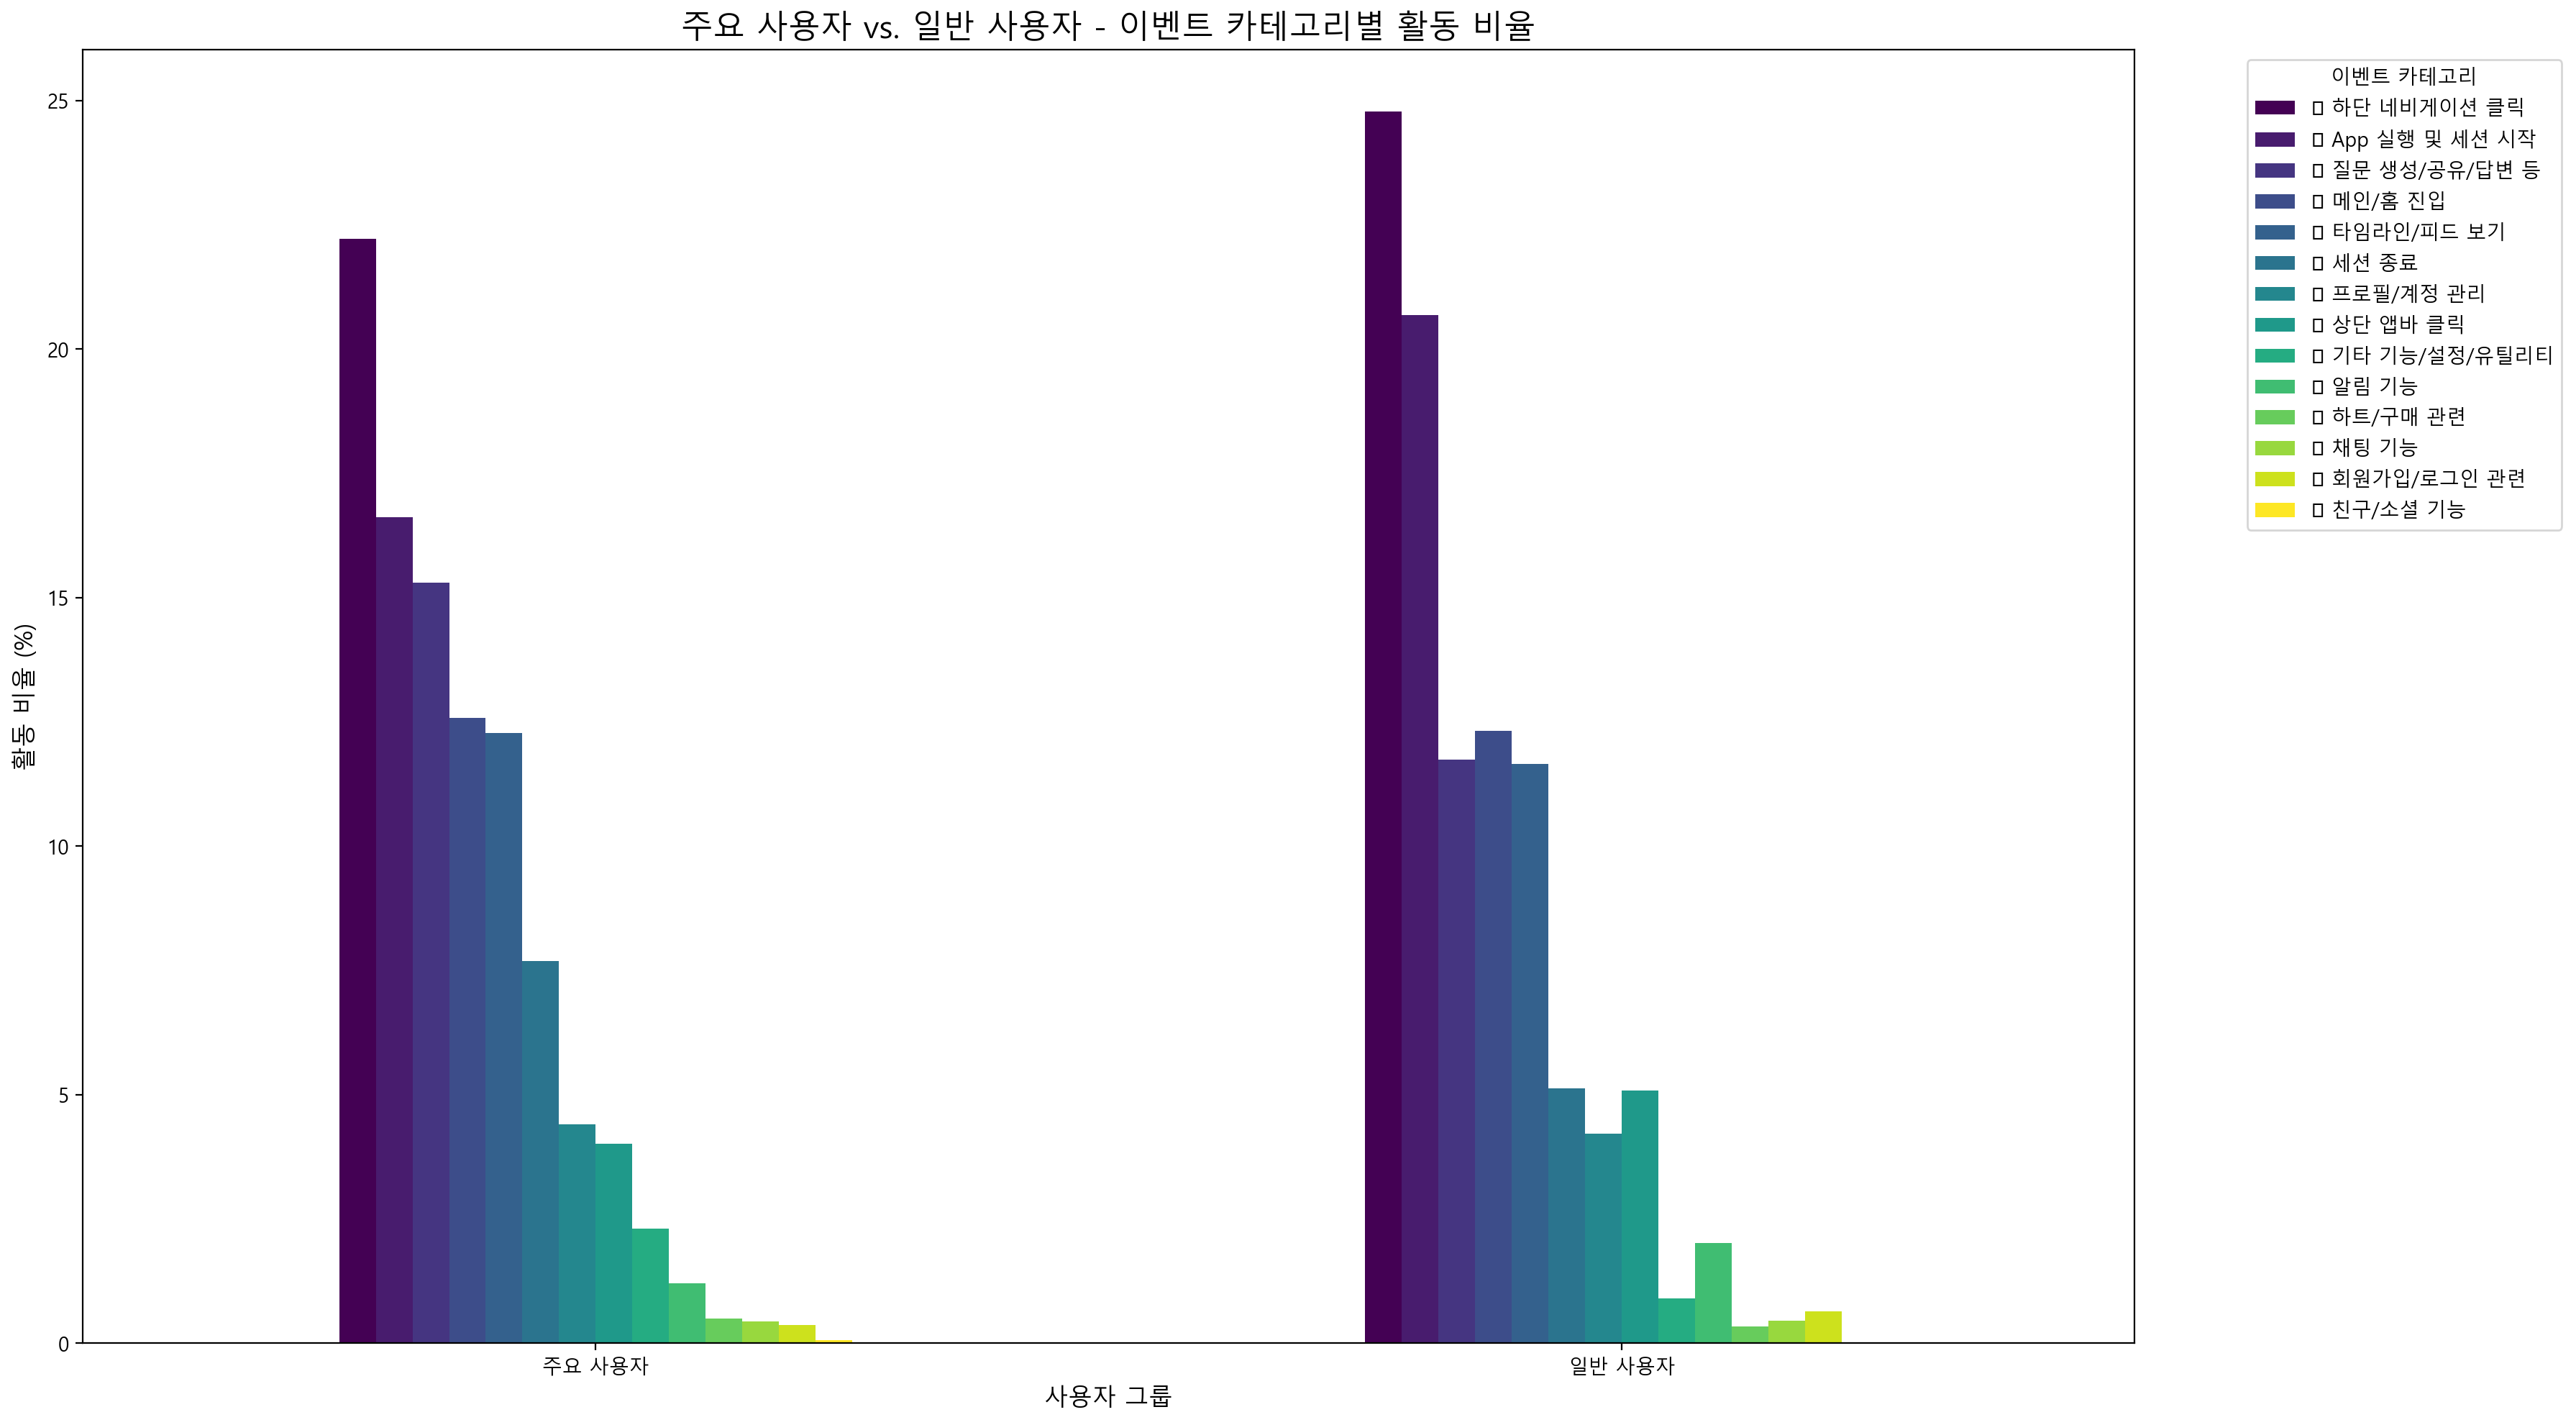


2.4. '💰 하트/구매 관련' 카테고리 활동 비율 비교:
   - 주요 사용자: 0.49%
   - 일반 사용자: 0.34%
   => 주요 사용자들이 '하트/구매' 활동에 더 많은 비율을 할애합니다.

--- 2. 이벤트 카테고리 분포 비교 완료 ---

--- 3. 핵심 카테고리 전환 패턴 비교 ---

3.1. 주요 사용자의 상위 15개 카테고리 전환 패턴:
                           transition_str   count
99   📱 App 실행 및 세션 시작 -> 📱 App 실행 및 세션 시작  251937
0      ❓ 질문 생성/공유/답변 등 -> ❓ 질문 생성/공유/답변 등  164763
25             🏠 메인/홈 진입 -> 🔽 하단 네비게이션 클릭  164632
147            🔽 하단 네비게이션 클릭 -> 🏠 메인/홈 진입  164307
90          📰 타임라인/피드 보기 -> 🔽 하단 네비게이션 클릭  145750
152         🔽 하단 네비게이션 클릭 -> 📰 타임라인/피드 보기  142882
157        🔽 하단 네비게이션 클릭 -> 🔽 하단 네비게이션 클릭  107801
80              📰 타임라인/피드 보기 -> 🏠 메인/홈 진입   88665
20              🏠 메인/홈 진입 -> 📰 타임라인/피드 보기   83982
146      🔽 하단 네비게이션 클릭 -> ❓ 질문 생성/공유/답변 등   80611
11       ❓ 질문 생성/공유/답변 등 -> 🔽 하단 네비게이션 클릭   80284
92    📱 App 실행 및 세션 시작 -> ❓ 질문 생성/공유/답변 등   58216
6         ❓ 질문 생성/공유/답변 등 -> 📰 타임라인/피드 보기   51175
79        📰 타임라인/피드 보기 -> ❓ 질문 생성/공유/답변 등   51080
148          🔽 하단 네비게이션 클릭 -> 👤 프로필/계정 관리  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 필수 설정 (이전에 진행된 단계의 연속성을 위해) ---
# df는 이전 코드에서 event_category 컬럼이 성공적으로 추가되고 모든 매핑이 완료된 데이터프레임입니다.
# (df가 정의되지 않았다면, df = df_final_sessions.copy() 등으로 초기화 필요)

# event_category_mapping_final은 이전에 정의된 가장 최신 event_category 매핑 딕셔너리여야 합니다.
# 이 스크립트만 실행하신다면, 이전 통합 코드의 event_category_mapping_final 딕셔너리를 여기에 복사 붙여넣기 하십시오.
event_category_mapping_final = {
    'launch_app': '📱 App 실행 및 세션 시작', '$session_start': '📱 App 실행 및 세션 시작', '$session_end': '🔚 세션 종료',
    'view_home_tap': '🏠 메인/홈 진입', 'view_lab_tap': '🏠 메인/홈 진입',
    'click_bottom_navigation_lab': '🔽 하단 네비게이션 클릭', 'click_bottom_navigation_profile': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_questions': '🔽 하단 네비게이션 클릭', 'click_bottom_navigation_timeline': '🔽 하단 네비게이션 클릭',
    'click_appbar_alarm_center': '🔼 상단 앱바 클릭', 'click_appbar_chat_rooms': '🔼 상단 앱바 클릭',
    'click_appbar_friend_plus': '🔼 상단 앱바 클릭', 'click_appbar_setting': '🔼 상단 앱바 클릭',
    'complete_signup': '🧾 회원가입/로그인 관련', 'view_login': '🧾 회원가입/로그인 관련', 'view_signup': '🧾 회원가입/로그인 관련',
    'click_purchase': '💰 하트/구매 관련', 'complete_purchase': '💰 하트/구매 관련', 'view_shop': '💰 하트/구매 관련',
    'click_copy_profile_link_ask': '❓ 질문 생성/공유/답변 등', 'click_profile_ask': '❓ 질문 생성/공유/답변 등',
    'click_question_ask': '❓ 질문 생성/공유/답변 등', 'click_question_open': '❓ 질문 생성/공유/답변 등',
    'click_question_share': '❓ 질문 생성/공유/답변 등', 'click_question_start': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_normal': '❓ 질문 생성/공유/답변 등', 'click_random_ask_other': '❓ 질문 생성/공유/답변 등',
    'click_random_ask_shuffle': '❓ 질문 생성/공유/답변 등', 'complete_question': '❓ 질문 생성/공유/답변 등',
    'skip_question': '❓ 질문 생성/공유/답변 등', 'view_questions_tap': '❓ 질문 생성/공유/답미변 등',
    'click_autoadd_contact': '👥 친구/소셜 기능', 'click_friend_invite': '👥 친구/소셜 기능',
    'click_invite_friend': '👥 친구/소셜 기능', 'view_friendplus_tap': '👥 친구/소셜 기능',
    'click_community_chat': '💬 채팅 기능', 'click_timeline_chat_start': '💬 채팅 기능',
    'click_notice': '🔔 알림 기능', 'click_notice_detail': '🔔 알림 기능',
    'view_profile_tap': '👤 프로필/계정 관리', 'view_timeline_tap': '📰 타임라인/피드 보기',
    'button': '🛠 기타 기능/설정/유틸리티', 'click_attendance': '🛠 기타 기능/설정/유틸리티',
    'click_copy_profile_link_profile': '🛠 기타 기능/설정/유틸리티',
}


# 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("### 일반 사용자 vs. 주요 사용자 행동 차이 비교 분석 시작 ###")

# --- 1. 사용자 그룹 정의 ---
print("\n--- 1. 사용자 그룹 정의 ---")

# 1.1. 주요 사용자 ID 추출 (이전 분석과 동일한 기준)
user_event_counts = df['user_id'].value_counts()
top_percentage = 0.90 # 상위 10%의 사용자
event_count_threshold = user_event_counts.quantile(top_percentage)
main_users_id = user_event_counts[user_event_counts >= event_count_threshold].index.tolist()

# 1.2. 일반 사용자 ID 추출 (주요 사용자가 아닌 모든 사용자)
all_users_id = df['user_id'].unique().tolist()
general_users_id = [uid for uid in all_users_id if uid not in main_users_id]

# 1.3. 각 그룹의 데이터프레임 생성
df_main_users = df[df['user_id'].isin(main_users_id)].copy()
df_general_users = df[df['user_id'].isin(general_users_id)].copy()

print(f"전체 사용자 수: {len(all_users_id)}명")
print(f"주요 사용자 수: {len(main_users_id)}명 (총 이벤트 수: {len(df_main_users)}개)")
print(f"일반 사용자 수: {len(general_users_id)}명 (총 이벤트 수: {len(df_general_users)}개)")

print("\n--- 1. 사용자 그룹 정의 완료 ---")


# --- 2. 이벤트 카테고리 분포 비교 ---
print("\n--- 2. 이벤트 카테고리 분포 비교 ---")

# 2.1. 각 그룹의 이벤트 카테고리 빈도 계산
main_user_category_counts = df_main_users['event_category'].value_counts()
general_user_category_counts = df_general_users['event_category'].value_counts()

# 2.2. 비교를 위한 데이터프레임 병합 및 비율 계산
category_comparison = pd.concat([main_user_category_counts, general_user_category_counts], axis=1)
category_comparison.columns = ['주요 사용자', '일반 사용자']
category_comparison = category_comparison.fillna(0) # NaN을 0으로 채움

# 총합 대비 비율 계산
category_comparison_percent = category_comparison.apply(lambda x: x / x.sum() * 100, axis=0)

print("\n2.1. 각 사용자 그룹의 이벤트 카테고리별 활동 비율 (%):\n", category_comparison_percent.round(2))

# 2.3. 시각화 (스택드 바 차트)
category_comparison_percent.T.plot(kind='bar', stacked=False, figsize=(18, 10), cmap='viridis') # stacked=False for side-by-side
plt.title("주요 사용자 vs. 일반 사용자 - 이벤트 카테고리별 활동 비율", fontsize=16)
plt.xlabel("사용자 그룹", fontsize=12)
plt.ylabel("활동 비율 (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="이벤트 카테고리", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2.4. (심층) 하트/구매 관련 활동 비율만 비교
heart_purchase_main_percent = category_comparison_percent.loc['💰 하트/구매 관련', '주요 사용자']
heart_purchase_general_percent = category_comparison_percent.loc['💰 하트/구매 관련', '일반 사용자']

print(f"\n2.4. '💰 하트/구매 관련' 카테고리 활동 비율 비교:")
print(f"   - 주요 사용자: {heart_purchase_main_percent:.2f}%")
print(f"   - 일반 사용자: {heart_purchase_general_percent:.2f}%")
if heart_purchase_main_percent > heart_purchase_general_percent:
    print("   => 주요 사용자들이 '하트/구매' 활동에 더 많은 비율을 할애합니다.")
else:
    print("   => 일반 사용자들이 '하트/구매' 활동에 더 많은 비율을 할애하거나 비슷합니다.")

print("\n--- 2. 이벤트 카테고리 분포 비교 완료 ---")


# --- 3. 핵심 카테고리 전환 패턴 비교 ---
print("\n--- 3. 핵심 카테고리 전환 패턴 비교 ---")

def get_top_transitions(df_user_group, top_n=10):
    df_sorted = df_user_group.sort_values(by=['session_id', 'event_datetime']).copy()
    df_sorted['previous_event_category'] = df_sorted.groupby('session_id')['event_category'].shift(1)
    transitions = df_sorted[df_sorted['previous_event_category'].notna()]
    transition_counts = transitions.groupby(['previous_event_category', 'event_category']).size().reset_index(name='count')
    transition_counts_sorted = transition_counts.sort_values(by='count', ascending=False)
    transition_counts_sorted['transition_str'] = transition_counts_sorted['previous_event_category'] + " -> " + transition_counts_sorted['event_category']
    return transition_counts_sorted.head(top_n)

# 3.1. 각 그룹의 상위 전환 패턴 추출
main_user_top_transitions = get_top_transitions(df_main_users, 15) # Top 15 추출
general_user_top_transitions = get_top_transitions(df_general_users, 15)

print("\n3.1. 주요 사용자의 상위 15개 카테고리 전환 패턴:")
print(main_user_top_transitions[['transition_str', 'count']].to_string())

print("\n3.2. 일반 사용자의 상위 15개 카테고리 전환 패턴:")
print(general_user_top_transitions[['transition_str', 'count']].to_string())

# 3.3. 두 그룹의 전환 패턴 비교 (시각화)
# 주요 패턴이 겹치는지, 다른 점이 있는지 직접 확인하며 해석합니다.
# 예를 들어, 핵심 기능으로의 진입, 이탈, 반복 활동 등에서 차이가 나타날 수 있습니다.
# 더 복잡한 비교는 Sankey diagram 등으로 가능하지만, 여기서는 기본 비교에 초점.

print("\n--- 3. 핵심 카테고리 전환 패턴 비교 완료 ---")

print("\n### 일반 사용자 vs. 주요 사용자 행동 차이 비교 분석 완료 ###")

- 🔍 일반 사용자 vs. 주요 사용자 활동 패턴 차이 분석
- 1. 참여도 및 기능 활용의 깊이 차이
    - 주요 사용자는 질문 생성/공유/답변 관련 이벤트 비율이 **15.3%**로 일반 사용자(11.74%)보다 약 30% 더 활발하게 참여합니다.

    - → 단순 소비자가 아닌 콘텐츠 생산자/기여자의 성격이 강합니다.

- 세션 종료 이벤트도 주요 사용자에서 더 높은 비중(7.69%)을 차지합니다.

    - → 더 긴 세션 혹은 여러 기능을 이용 후 종료하는 경향을 보이며, 의도적 이용 패턴을 시사합니다.

- 기타 기능/설정/유틸리티, 프로필 관리, 하트/구매 관련 기능 등 부가 기능 활용 비율도 주요 사용자가 전반적으로 높습니다.

    - → 서비스의 심화 기능까지 탐색하고 활용하는 사용자군임을 보여줍니다.

---

- ✅ 왜 주요 사용자를 중심으로 분석해야 하나?
- 1. 서비스 가치 창출의 핵심 사용자군

    - 전체의 10%밖에 안 되는 주요 사용자가 전체 이벤트의 44% 이상을 차지하며, 실제 서비스의 활동량과 기여도 측면에서 핵심을 차지하고 있음.

- 2. 전환 전략의 타겟 모델

    - 일반 사용자를 주요 사용자로 전환시키는 것이 리텐션, 충성도, 매출 증가에 있어 가장 효율적인 전략이 될 수 있음.

- 3. UX/UI 개선 및 핵심 기능 강화 기준

    - 주요 사용자가 주로 사용하는 기능을 중심으로 UI를 최적화하거나, 이들의 사용 흐름을 기반으로 퍼널 분석 시 정확하고 전략적인 개선안 도출 가능.

---

- 추후 분석에서 질문/생성/공유/답변을 세분화 할 필요성

- ✍️ 보고서용 예시 문단
- "주요 사용자는 전체 사용자 중 단 10%에 불과하지만, 전체 이벤트의 44% 이상을 생성하며 서비스에 깊이 관여하고 있다. 이들은 질문 생성 및 세션 종료 비중이 높고 다양한 기능을 적극 활용하는 경향을 보여, 단순 탐색에 그치는 일반 사용자와 뚜렷이 구별된다. 따라서 서비스 개선 및 전략 수립 시에는 이들 주요 사용자의 행동 패턴을 중심으로 분석하는 것이, 실질적인 서비스 성과를 높이는 데 있어 더욱 효과적이다."

## 주요 사용자 평균 흐름 분석

### '주요 사용자' 추출 및 '평균 흐름' 분석 시작 ###

--- 1. '주요 사용자' 정의 및 추출 시작 ---
총 유니크 사용자 수: 169115명
상위 10% 사용자의 최소 이벤트 수 (기준): 77개
추출된 '주요 사용자' 수: 17140명
'주요 사용자' 데이터프레임의 총 이벤트 수: 2771603개
--- 1. '주요 사용자' 추출 완료 ---

--- 2. '주요 사용자'의 평균 흐름 분석 시작 ---

2.1. '주요 사용자'의 이벤트 카테고리 빈도:
event_category
🔽 하단 네비게이션 클릭       615786
📱 App 실행 및 세션 시작    460657
❓ 질문 생성/공유/답변 등     424094
🏠 메인/홈 진입           348643
📰 타임라인/피드 보기        340171
🔚 세션 종료             213131
👤 프로필/계정 관리         122222
🔼 상단 앱바 클릭          111357
🛠 기타 기능/설정/유틸리티      64097
🔔 알림 기능              33426
💰 하트/구매 관련           13709
💬 채팅 기능              12339
🧾 회원가입/로그인 관련        10098
👥 친구/소셜 기능            1873
Name: count, dtype: int64


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 128317 (\N{DOWN-POINTING SMALL RED TRIANGLE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 128240 (\N{NEWSPAPER}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:56: UserWarning:

Glyph 128282 (\N{END WITH LEFTWARDS ARROW ABOVE}) missing

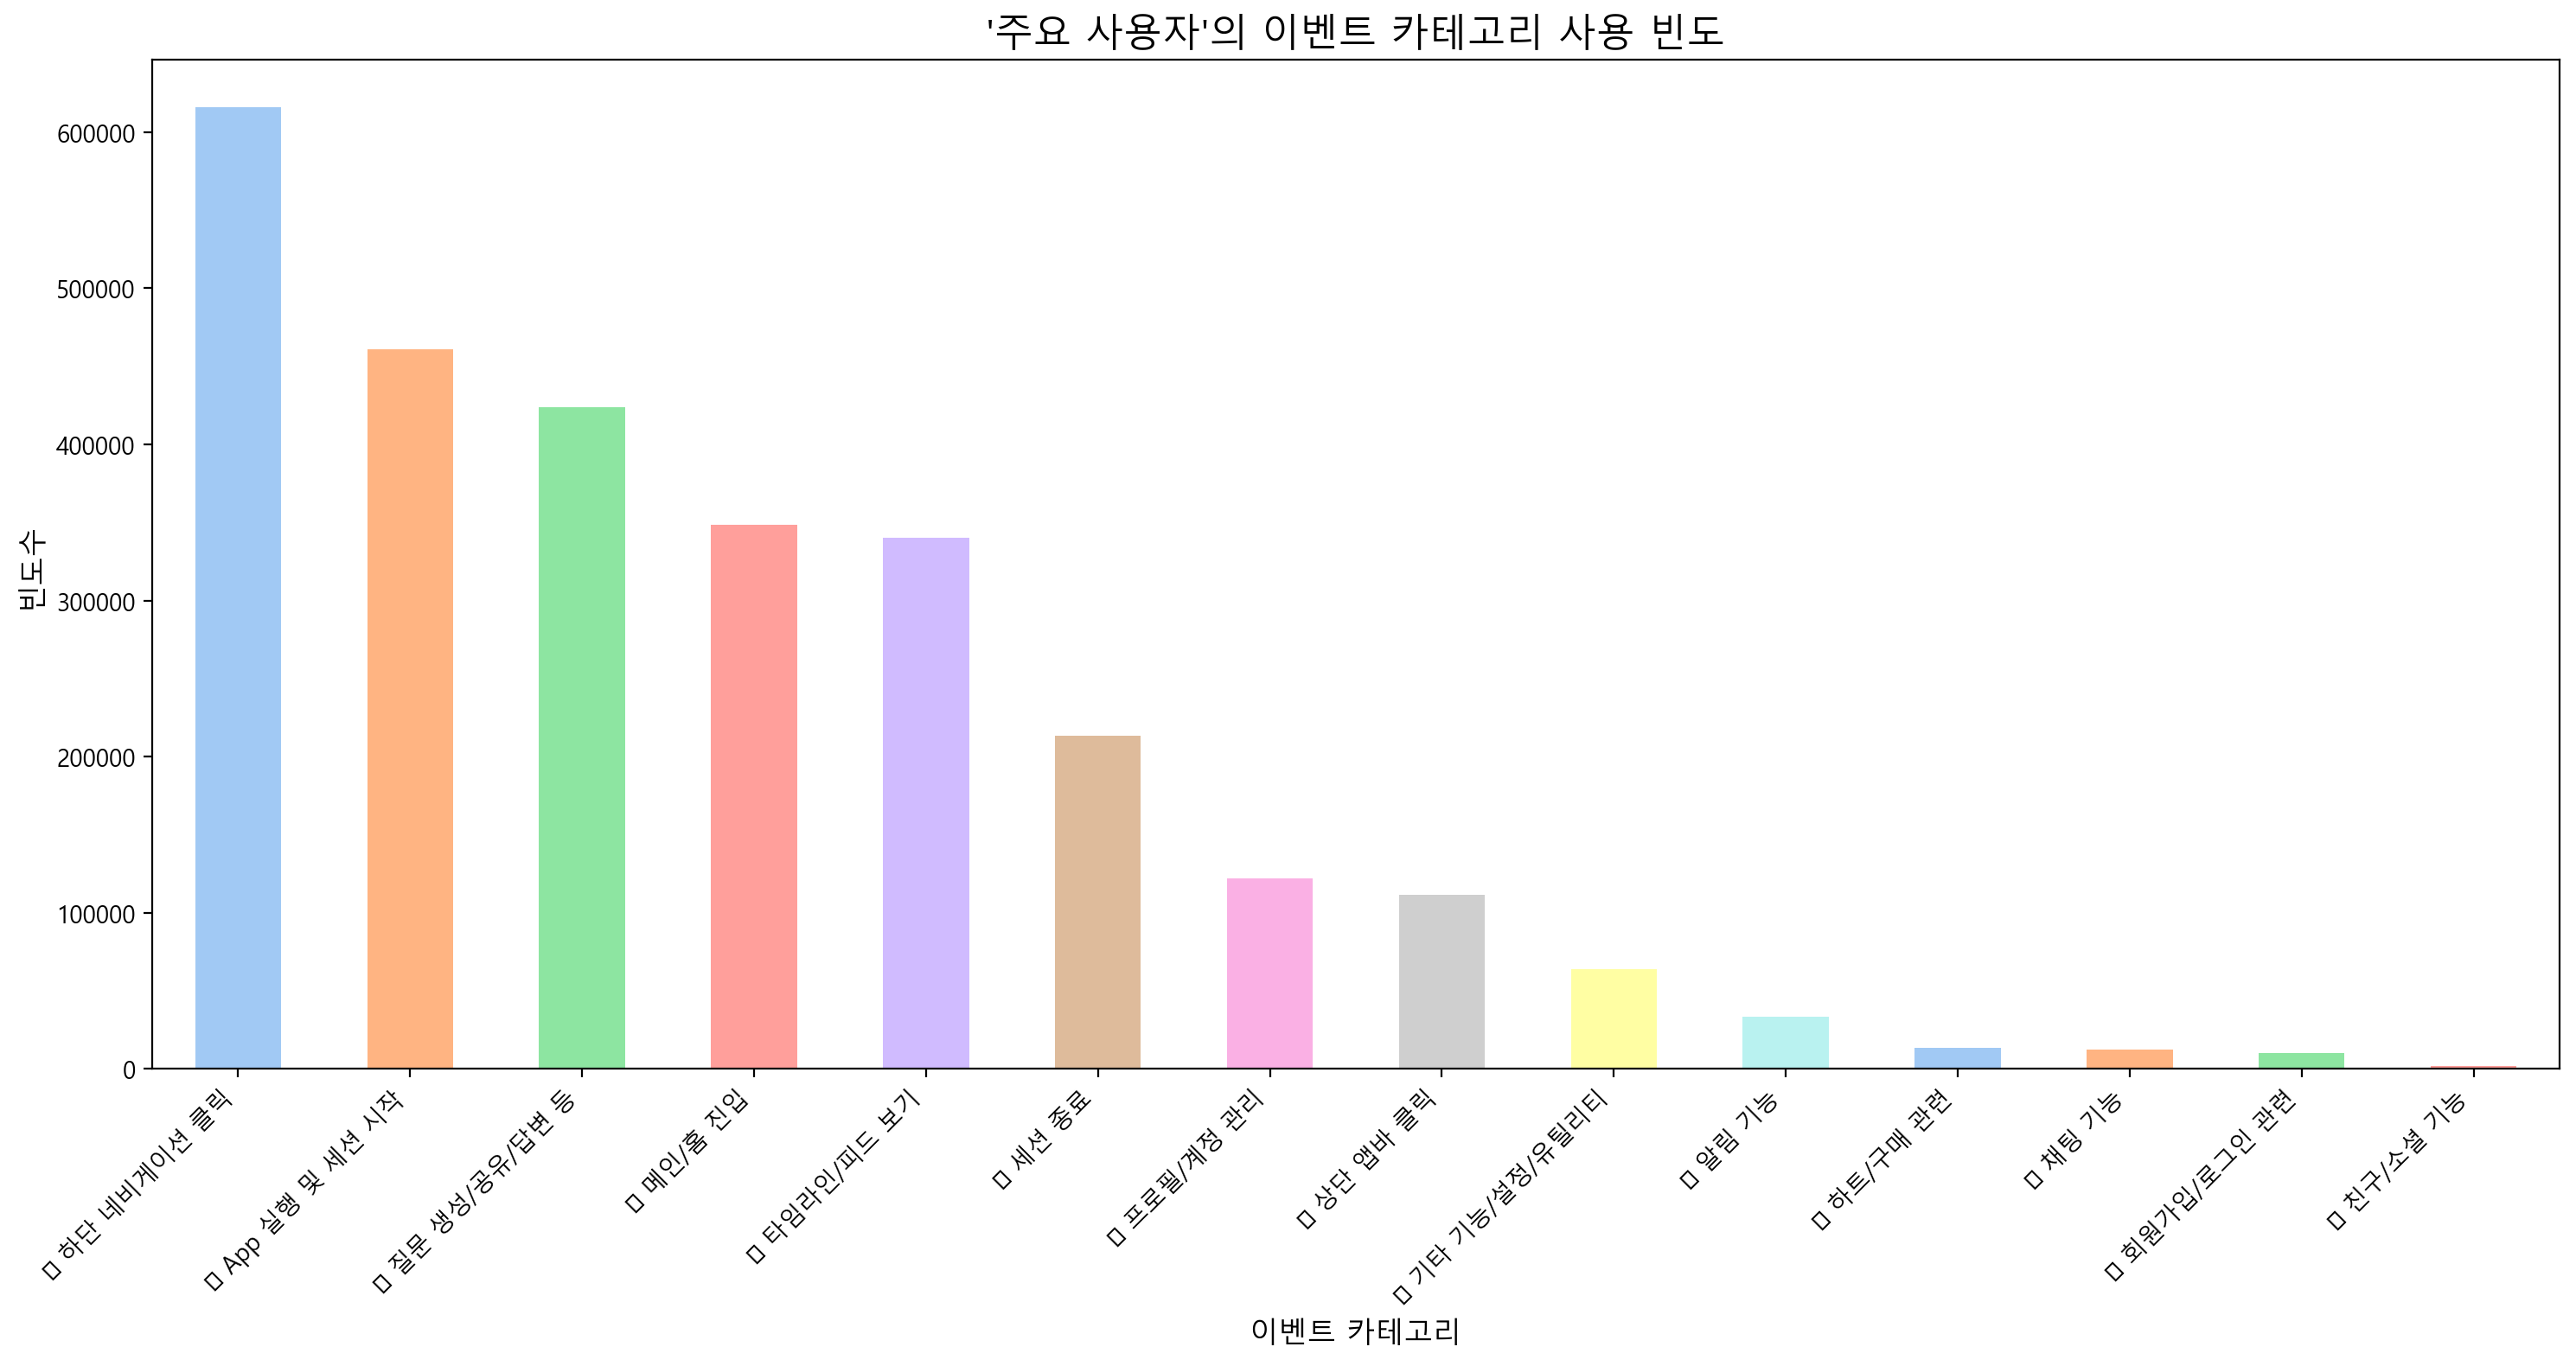


2.2. '주요 사용자'의 가장 빈번한 '이벤트 카테고리' 간 전환 (Top 20):
    previous_event_category    event_category   count
99         📱 App 실행 및 세션 시작  📱 App 실행 및 세션 시작  251937
0           ❓ 질문 생성/공유/답변 등   ❓ 질문 생성/공유/답변 등  164763
25                🏠 메인/홈 진입     🔽 하단 네비게이션 클릭  164632
147           🔽 하단 네비게이션 클릭         🏠 메인/홈 진입  164307
90             📰 타임라인/피드 보기     🔽 하단 네비게이션 클릭  145750
152           🔽 하단 네비게이션 클릭      📰 타임라인/피드 보기  142882
157           🔽 하단 네비게이션 클릭     🔽 하단 네비게이션 클릭  107801
80             📰 타임라인/피드 보기         🏠 메인/홈 진입   88665
20                🏠 메인/홈 진입      📰 타임라인/피드 보기   83982
146           🔽 하단 네비게이션 클릭   ❓ 질문 생성/공유/답변 등   80611
11          ❓ 질문 생성/공유/답변 등     🔽 하단 네비게이션 클릭   80284
92         📱 App 실행 및 세션 시작   ❓ 질문 생성/공유/답변 등   58216
6           ❓ 질문 생성/공유/답변 등      📰 타임라인/피드 보기   51175
79             📰 타임라인/피드 보기   ❓ 질문 생성/공유/답변 등   51080
148           🔽 하단 네비게이션 클릭       👤 프로필/계정 관리   50057
7           ❓ 질문 생성/공유/답변 등  📱 App 실행 및 세션 시작   49267
38              👤 프로필/계정 관리     🔽

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:92: UserWarning:

Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:92: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:92: UserWarning:

Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\4239044399.py:92: UserWarning:

Glyph 128317 (\N{DOWN-POINTING SMALL RED TRIANGLE}) missing from font(s) Malgun Gothic.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\

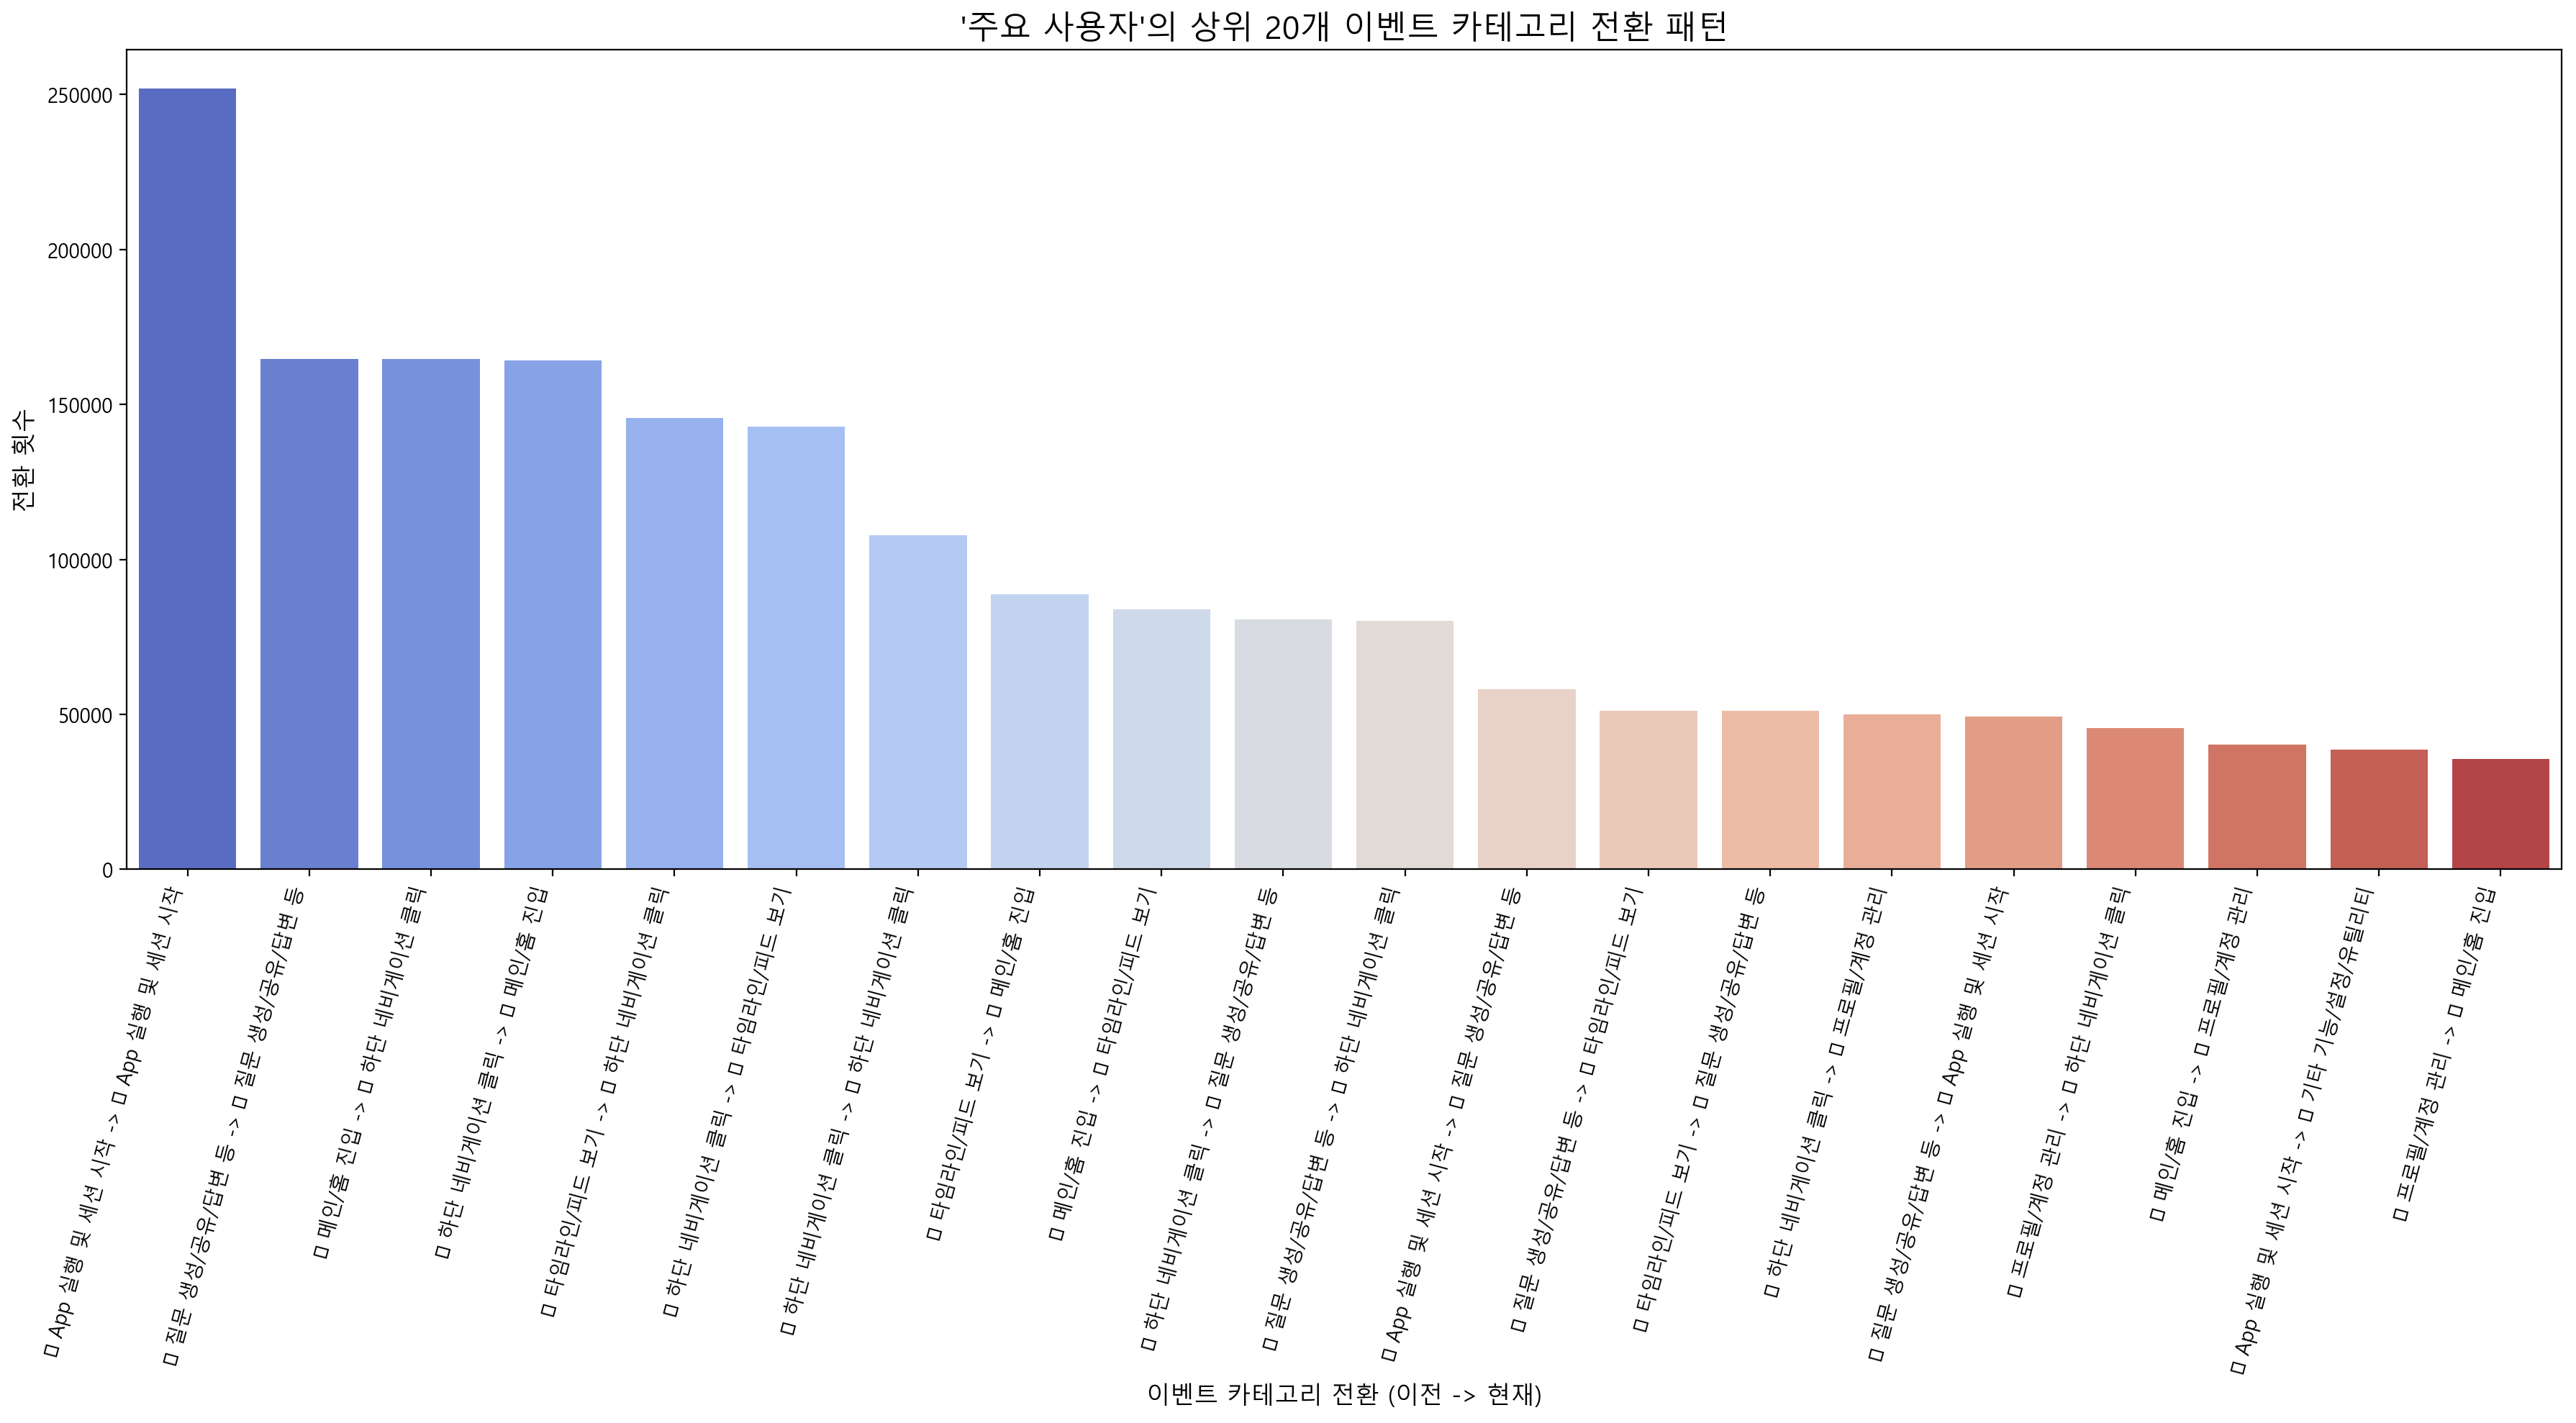

--- 2. '주요 사용자'의 평균 흐름 분석 완료 ---

### '주요 사용자' 추출 및 '평균 흐름' 분석 완료 ###


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 필수 설정 (이전에 진행된 단계의 연속성을 위해) ---
# df는 이전 코드에서 event_category 컬럼이 성공적으로 추가되고 모든 매핑이 완료된 데이터프레임입니다.
# (df가 정의되지 않았다면, df = df_final_sessions.copy() 등으로 초기화 필요)

# 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("### '주요 사용자' 추출 및 '평균 흐름' 분석 시작 ###")

# --- 1. '주요 사용자' 정의 및 추출 ---
print("\n--- 1. '주요 사용자' 정의 및 추출 시작 ---")

# 1.1. 사용자별 총 이벤트 수 계산
user_event_counts = df['user_id'].value_counts()
print(f"총 유니크 사용자 수: {len(user_event_counts)}명")

# 1.2. '주요 사용자' 기준 정의 (예: 총 이벤트 수 기준 상위 10%)
# 이 백분위수를 조절하여 '주요 사용자'의 기준을 변경할 수 있습니다 (예: 0.95는 상위 5%).
top_percentage = 0.90 # 상위 10%의 사용자 (이벤트 횟수 기준)
event_count_threshold = user_event_counts.quantile(top_percentage)

main_users_id = user_event_counts[user_event_counts >= event_count_threshold].index.tolist()
print(f"상위 {round((1-top_percentage)*100)}% 사용자의 최소 이벤트 수 (기준): {int(event_count_threshold)}개")
print(f"추출된 '주요 사용자' 수: {len(main_users_id)}명")

# 1.3. '주요 사용자'의 데이터만 필터링
df_main_users = df[df['user_id'].isin(main_users_id)].copy()
print(f"'주요 사용자' 데이터프레임의 총 이벤트 수: {len(df_main_users)}개")
print("--- 1. '주요 사용자' 추출 완료 ---")


# --- 2. '주요 사용자'의 평균 흐름 분석 ---
print("\n--- 2. '주요 사용자'의 평균 흐름 분석 시작 ---")

# 2.1. '주요 사용자'들이 가장 많이 사용하는 이벤트 '카테고리' 분석
print("\n2.1. '주요 사용자'의 이벤트 카테고리 빈도:")
main_user_category_counts = df_main_users['event_category'].value_counts()
print(main_user_category_counts)

# 시각화
plt.figure(figsize=(15, 8))
main_user_category_counts.plot(
    kind='bar',
    color=sns.color_palette('pastel', len(main_user_category_counts))
)
plt.title("'주요 사용자'의 이벤트 카테고리 사용 빈도", fontsize=16)
plt.xlabel("이벤트 카테고리", fontsize=12)
plt.ylabel("빈도수", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


# 2.2. '주요 사용자'의 카테고리 간 전환 패턴 분석 (상위 N개)
print("\n2.2. '주요 사용자'의 가장 빈번한 '이벤트 카테고리' 간 전환 (Top 20):")

# 세션 내 이벤트 순서 정렬
df_main_users_sorted = df_main_users.sort_values(by=['session_id', 'event_datetime']).copy()

# 이전 이벤트 카테고리 컬럼 생성
df_main_users_sorted['previous_event_category'] = \
    df_main_users_sorted.groupby('session_id')['event_category'].shift(1)

# 유효한 전환만 필터링 (이전 카테고리가 있는 경우)
category_transitions = df_main_users_sorted[df_main_users_sorted['previous_event_category'].notna()]

# (이전 카테고리, 현재 카테고리) 쌍으로 전환 패턴 집계
transition_counts = category_transitions.groupby(['previous_event_category', 'event_category']).size().reset_index(name='count')
transition_counts_sorted = transition_counts.sort_values(by='count', ascending=False)

# Top 20 전환 패턴 출력
print(transition_counts_sorted.head(20).to_string())

# 시각화 (선택사항: 상위 N개 전환 패턴 막대 그래프)
# 전환 패턴 문자열로 변환
transition_counts_sorted['transition'] = transition_counts_sorted['previous_event_category'] + " -> " + transition_counts_sorted['event_category']
top_transitions_for_plot = transition_counts_sorted.head(20) # 상위 20개 전환

if not top_transitions_for_plot.empty:
    plt.figure(figsize=(18, 10))
    sns.barplot(x='transition', y='count', data=top_transitions_for_plot, palette='coolwarm')
    plt.title("'주요 사용자'의 상위 20개 이벤트 카테고리 전환 패턴", fontsize=16)
    plt.xlabel("이벤트 카테고리 전환 (이전 -> 현재)", fontsize=12)
    plt.ylabel("전환 횟수", fontsize=12)
    plt.xticks(rotation=75, ha='right', fontsize=10) # 라벨이 길 수 있으므로 더 회전
    plt.tight_layout()
    plt.show()
else:
    print("분석할 전환 패턴이 없습니다.")

print("--- 2. '주요 사용자'의 평균 흐름 분석 완료 ---")

print("\n### '주요 사용자' 추출 및 '평균 흐름' 분석 완료 ###")

- 주요 사용자 행동 흐름 특징 요약

| 순위 | 이벤트 카테고리          | 이벤트 수   |
| -- | ----------------- | ------- |
| 1  | 🔽 하단 네비게이션 클릭    | 615,786 |
| 2  | 📱 App 실행 및 세션 시작 | 460,657 |
| 3  | ❓ 질문 생성/공유/답변 등   | 424,094 |
| 4  | 🏠 메인/홈 진입        | 348,643 |
| 5  | 📰 타임라인/피드 보기     | 340,171 |
| 8  | 🔼 상단 앱바 클릭       | 111,357 |

- 주요 사용자는 주로 하단 네비게이션(1위) 과 질문 기능, 홈, 피드를 반복적으로 사용하며 높은 재방문/재활동성을 보임.

- 그러나 상단 앱바 클릭 수는 비교적 낮은 편(111,357회) 으로, 하단 네비게이션 대비 사용 비중이 월등히 낮습니다.


- 상단 앱바 vs 하단 네비게이션 전환 비교
    - 하단 네비게이션은 홈, 피드, 질문 등으로 활발히 이동하고 있음 (예: 하단 네비 → 홈: 164,307회).

    - 반면, 상단 앱바를 통한 다른 기능 전환은 Top 20 전환 흐름에서 거의 보이지 않음.

    - 이는 상단 앱바가 실제 유저의 주된 이동 경로로 활용되지 않고 있음을 의미합니다.

- UI/UX 관점 인사이트
- 상단 앱바에 중요한 기능이 위치해 있음에도 불구하고 사용자 전환율이 낮은 이유는 다음과 같이 해석할 수 있습니다:

    - 노출 문제: 시각적으로 눈에 잘 띄지 않거나, 위치상 우선순위가 밀려 실제 클릭 유도에 실패하고 있을 가능성.

    - 인지도 문제: 해당 기능이 어떤 기능인지, 왜 필요한지에 대한 사용자 인식이 부족할 수 있음.

    - 대체 경로 존재: 같은 기능을 하단 네비게이션이나 메인 화면 등 다른 경로로 더 쉽게 접근할 수 있는 경우.

- 향후 개선 방향 제안
    - 1. 상단 앱바 재배치 및 강조

        - 실제 사용자 전환이 필요한 핵심 기능이 상단 앱바에 있다면, UI를 더 직관적이고 눈에 띄게 개선할 필요가 있음.

        - 예: 더 큰 아이콘, 컬러 강조, 앱바 하단으로 재배치 등

    - 2. A/B 테스트 진행 필요

        - 상단 앱바의 기능을 하단 네비게이션이나 메인 진입에 배치한 실험 그룹과 기존 그룹을 비교하여 전환율 변화를 분석

    - 3. 핵심 기능의 유입 경로 개선

        - 진입이 낮은 기능일수록, 추천 섹션, 피드, 알림 등과 연결시켜 자연스럽게 유도하는 방법 고려

    - 4. 사용자 교육/온보딩 강화

        - 신규 및 기존 사용자에게 앱 내 핵심 기능 안내 툴팁 또는 튜토리얼 팝업 제공

- 결론 :
- 주요 사용자 분석을 통해, 상단 앱바의 활용도가 낮은 문제를 발견하였으며, 이는 중요한 기능임에도 사용자 흐름에 자연스럽게 녹아들지 못하고 있다는 시사점을 제공합니다. 이에 따라 UI/UX 전반의 구조 재검토와 전환 경로 최적화가 필요합니다.

---

## 질문 카테고리 세분화

### '❓ 질문' 카테고리 세분화 및 재매핑 시작 ###
데이터프레임 'df'의 'event_category' 컬럼이 업데이트되었습니다 (질문 카테고리 세분화 적용).
=> 모든 'event_key'가 카테고리에 성공적으로 매핑되었습니다. NaN 값이 없습니다.

--- '❓ 질문' 카테고리 세분화 및 재매핑 완료 ---

### 2.1. '❓ 질문' 세분화 카테고리 연계 분석 시작 ###
   - '소비(하트 진입)' 직전에 '❓ 질문' 세분화 카테고리가 온 경우, 그 구체적인 카테고리 빈도를 분석합니다.

--- '소비' 이벤트 직전 '❓ 질문' 세분화 카테고리 내 이벤트 카테고리 빈도 ---
previous_event_category
❓ 질문 조회/관리    7566
❓ 질문 시작/생성     967
❓ 질문 건너뛰기       55
❓ 질문 공유/링크      40
Name: count, dtype: int64

총 발생 횟수: 8628회


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\3939582466.py:158: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

c:\Users\PC\anaconda3\envs\codeit_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.



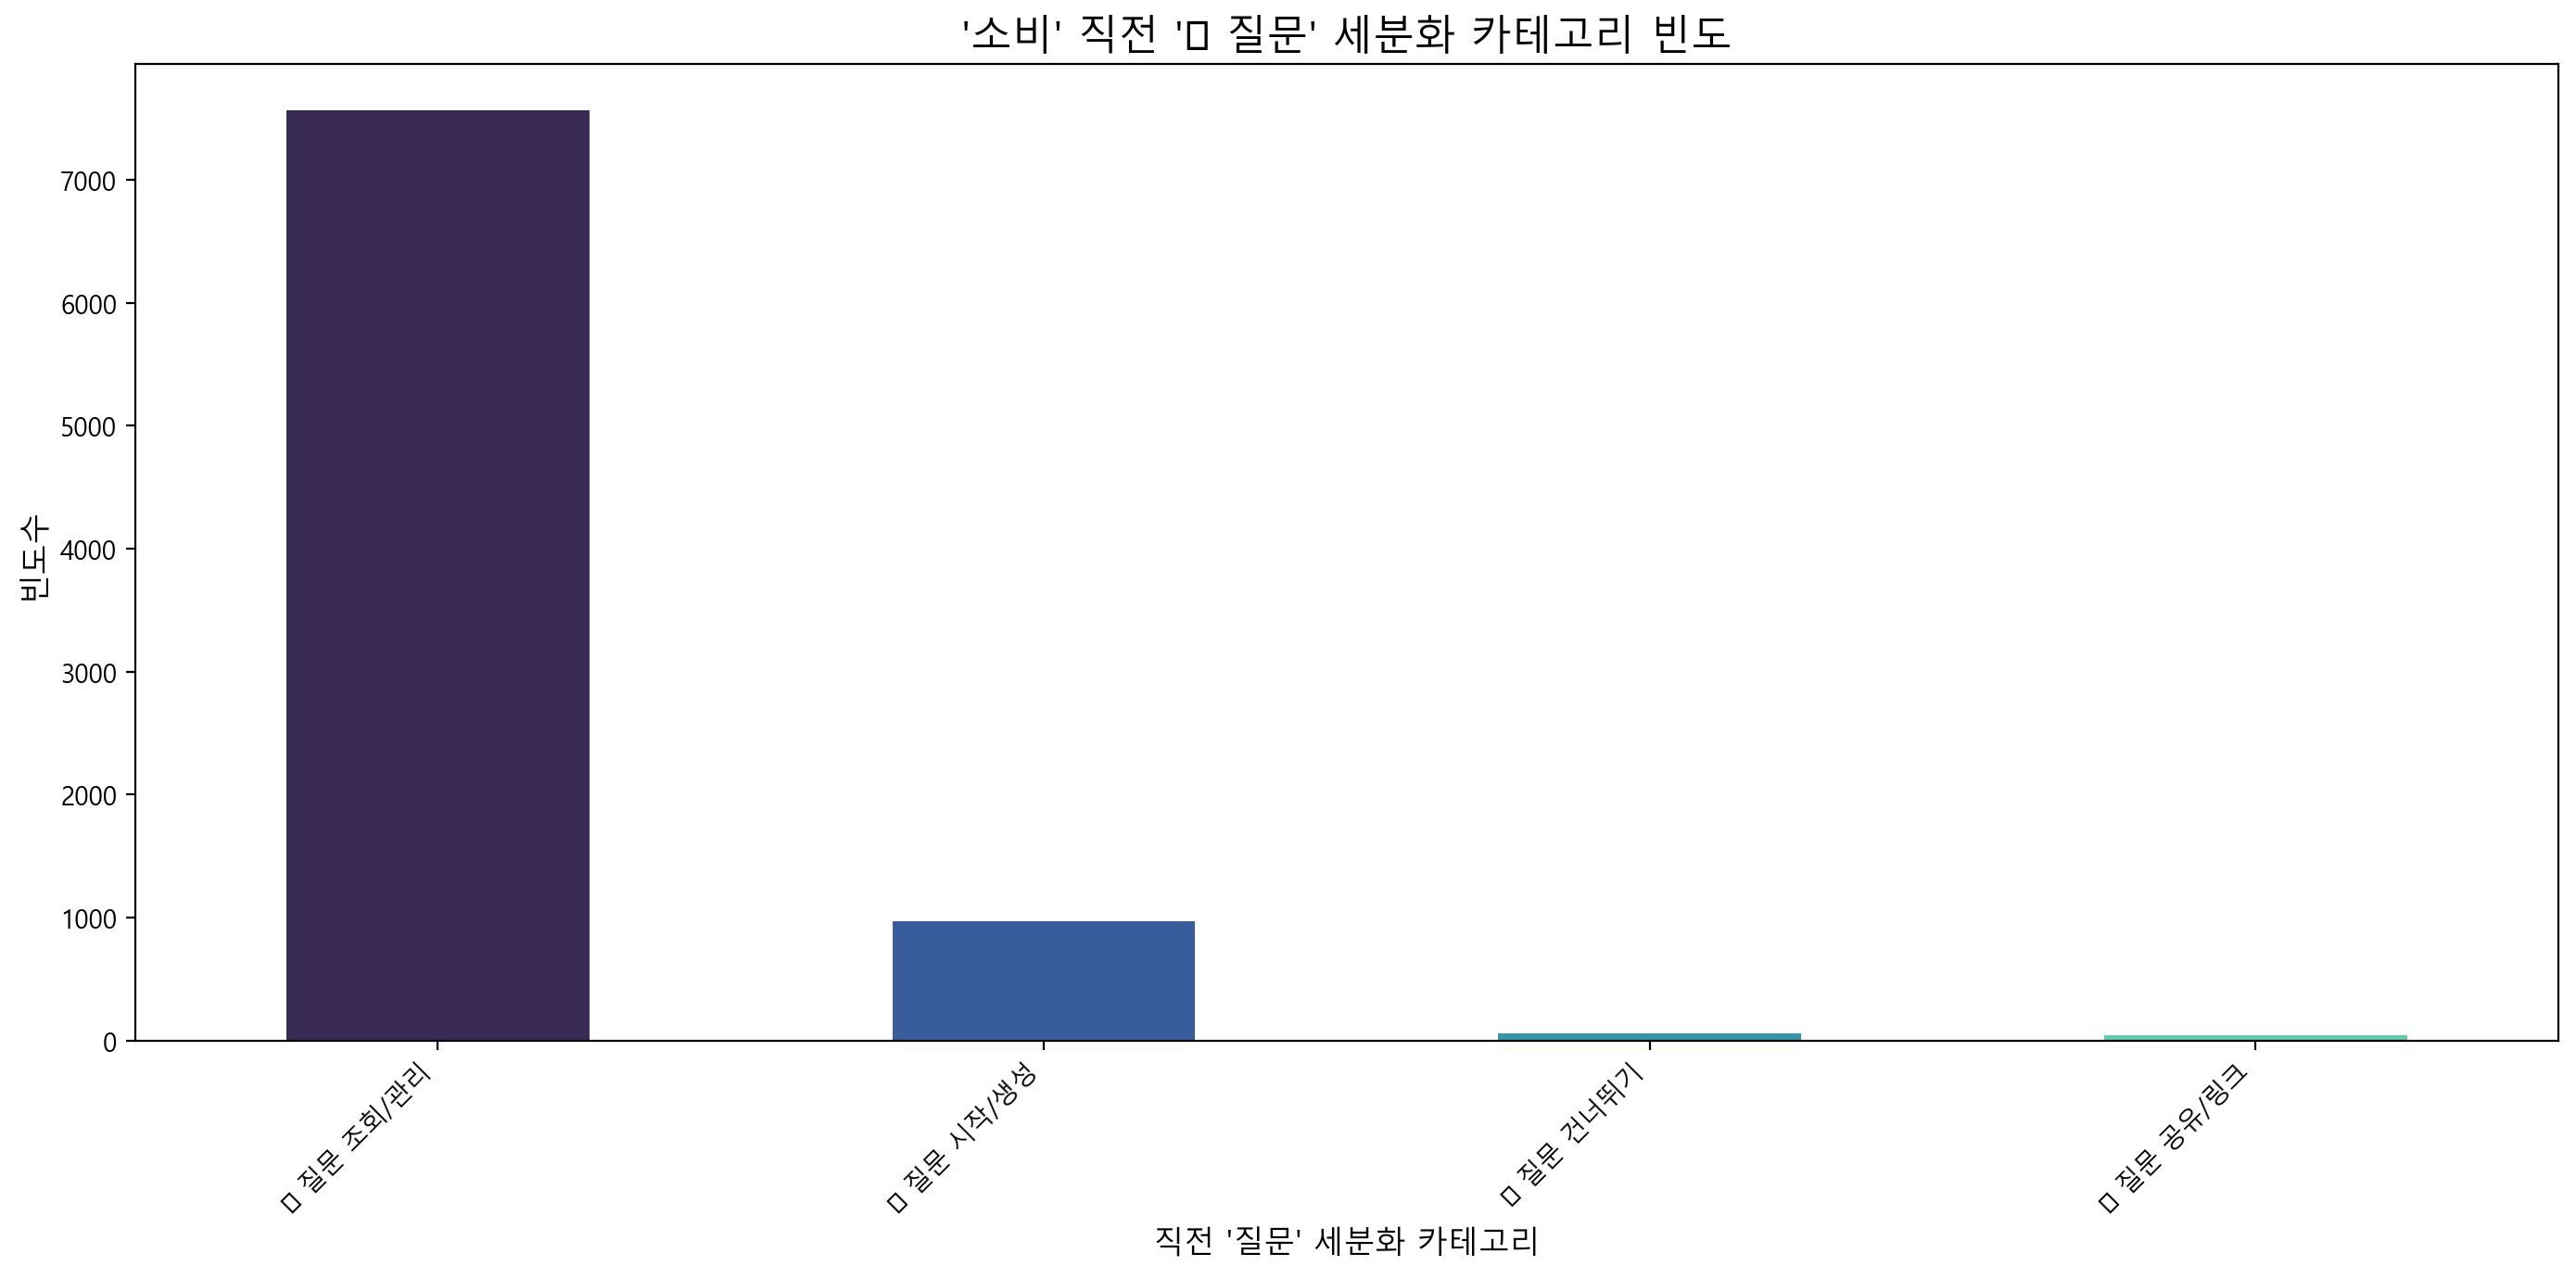

--- 분석 결과 시각화 완료 ---

### 2.1. '❓ 질문' 세분화 카테고리 연계 분석 완료 ###


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 필수 설정 (이전에 진행된 단계의 연속성을 위해) ---
# df는 이전 코드에서 event_category 컬럼이 성공적으로 추가되고 모든 매핑이 완료된 데이터프레임입니다.
# (df가 정의되지 않았다면, df = df_final_sessions.copy() 등으로 초기화 필요)

# 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("### '❓ 질문' 카테고리 세분화 및 재매핑 시작 ###")

# 1.1. 이벤트 키와 카테고리 매핑 정의 (최종 재분류 적용 + 질문 카테고리 세분화)
event_category_mapping_final = {
    # 📱 App 실행 및 세션 시작
    'launch_app': '📱 App 실행 및 세션 시작',
    '$session_start': '📱 App 실행 및 세션 시작',

    # 🔚 세션 종료
    '$session_end': '🔚 세션 종료',

    # 🏠 메인/홈 진입
    'view_home_tap': '🏠 메인/홈 진입',
    'view_lab_tap': '🏠 메인/홈 진입',

    # 🔽 하단 네비게이션 클릭
    'click_bottom_navigation_lab': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_profile': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_questions': '🔽 하단 네비게이션 클릭',
    'click_bottom_navigation_timeline': '🔽 하단 네비게이션 클릭',

    # 🔼 상단 앱바 클릭
    'click_appbar_alarm_center': '🔼 상단 앱바 클릭',
    'click_appbar_chat_rooms': '🔼 상단 앱바 클릭',
    'click_appbar_friend_plus': '🔼 상단 앱바 클릭',
    'click_appbar_setting': '🔼 상단 앱바 클릭',

    # 🧾 회원가입/로그인 관련
    'complete_signup': '🧾 회원가입/로그인 관련',
    'view_login': '🧾 회원가입/로그인 관련',
    'view_signup': '🧾 회원가입/로그인 관련',

    # 💰 하트/구매 관련
    'click_purchase': '💰 하트/구매 관련',
    'complete_purchase': '💰 하트/구매 관련',
    'view_shop': '💰 하트/구매 관련',

    # ❓ 질문 카테고리 세분화 ----------------------------------------------------
    'click_question_start': '❓ 질문 시작/생성',
    'click_question_ask': '❓ 질문 시작/생성',
    'click_random_ask_normal': '❓ 질문 시작/생성',
    'click_random_ask_other': '❓ 질문 시작/생성',
    'click_random_ask_shuffle': '❓ 질문 시작/생성',
    'click_profile_ask': '❓ 질문 시작/생성',
    'complete_question': '❓ 질문 시작/생성', # 질문 생성 완료로 해석

    'click_question_open': '❓ 질문 조회/관리',
    'view_questions_tap': '❓ 질문 조회/관리',

    'skip_question': '❓ 질문 건너뛰기',

    'click_question_share': '❓ 질문 공유/링크',
    'click_copy_profile_link_ask': '❓ 질문 공유/링크',
    # -------------------------------------------------------------------------

    # 👥 친구/소셜 기능
    'click_autoadd_contact': '👥 친구/소셜 기능',
    'click_friend_invite': '👥 친구/소셜 기능',
    'click_invite_friend': '👥 친구/소셜 기능',
    'view_friendplus_tap': '👥 친구/소셜 기능',

    # 💬 채팅 기능
    'click_community_chat': '💬 채팅 기능',
    'click_timeline_chat_start': '💬 채팅 기능',

    # 🔔 알림 기능
    'click_notice': '🔔 알림 기능',
    'click_notice_detail': '🔔 알림 기능',

    # 👤 프로필/계정 관리
    'view_profile_tap': '👤 프로필/계정 관리',

    # 📰 타임라인/피드 보기
    'view_timeline_tap': '📰 타임라인/피드 보기',

    # 🛠 기타 기능/설정/유틸리티
    'button': '🛠 기타 기능/설정/유틸리티',
    'click_attendance': '🛠 기타 기능/설정/유틸리티',
    'click_copy_profile_link_profile': '🛠 기타 기능/설정/유틸리티',
}


# 1.2. 데이터프레임에 'event_category' 컬럼 재매핑
df['event_category'] = df['event_key'].map(event_category_mapping_final)
print("데이터프레임 'df'의 'event_category' 컬럼이 업데이트되었습니다 (질문 카테고리 세분화 적용).")

# 1.3. NaN 값 여부 재확인
nan_event_category_count = df['event_category'].isna().sum()
if nan_event_category_count == 0:
    print("=> 모든 'event_key'가 카테고리에 성공적으로 매핑되었습니다. NaN 값이 없습니다.")
else:
    print(f"=> 아직 매핑되지 않은 'event_key' (NaN 값)가 {nan_event_category_count}개 존재합니다.")
    print("\n매핑되지 않은 유니크 이벤트 키 및 개수:")
    print(df[df['event_category'].isna()]['event_key'].value_counts())

print("\n--- '❓ 질문' 카테고리 세분화 및 재매핑 완료 ---")


### 2.1. '❓ 질문' 세분화 카테고리 연계 분석 (재실행)

print("\n### 2.1. '❓ 질문' 세분화 카테고리 연계 분석 시작 ###")
print("   - '소비(하트 진입)' 직전에 '❓ 질문' 세분화 카테고리가 온 경우, 그 구체적인 카테고리 빈도를 분석합니다.")

# 2.1.1. '소비' 관련 이벤트를 정의 (확장된 정의 재사용)
consumption_event_keys_expanded = ['complete_purchase', 'click_purchase', 'view_shop']

# 2.1.2. 데이터 정렬 및 이전 이벤트 카테고리 추출
df_analysis_questions_revisit = df.sort_values(by=['session_id', 'event_datetime']).copy()
df_analysis_questions_revisit['previous_event_category'] = \
    df_analysis_questions_revisit.groupby('session_id')['event_category'].shift(1)

# 2.1.3. '소비' 이벤트에 해당하고, 이전 카테고리가 '질문' 관련 세분화 카테고리인 경우 필터링
# 질문 관련 세분화된 카테고리들을 리스트로 정의
question_sub_categories = [
    '❓ 질문 시작/생성',
    '❓ 질문 조회/관리',
    '❓ 질문 건너뛰기',
    '❓ 질문 공유/링크'
]

events_preceded_by_specific_question_categories = df_analysis_questions_revisit[
    (df_analysis_questions_revisit['event_key'].isin(consumption_event_keys_expanded)) &
    (df_analysis_questions_revisit['previous_event_category'].isin(question_sub_categories))
].copy()

# 2.1.4. 해당 케이스에서의 직전 '세분화된 질문 카테고리' 빈도수를 계산합니다.
frequency_of_specific_question_sub_categories = \
    events_preceded_by_specific_question_categories['previous_event_category'].value_counts()

print("\n--- '소비' 이벤트 직전 '❓ 질문' 세분화 카테고리 내 이벤트 카테고리 빈도 ---")
if not frequency_of_specific_question_sub_categories.empty:
    print(frequency_of_specific_question_sub_categories)
    print(f"\n총 발생 횟수: {frequency_of_specific_question_sub_categories.sum()}회")

    # 시각화
    plt.figure(figsize=(14, 7))
    frequency_of_specific_question_sub_categories.plot(
        kind='bar',
        color=sns.color_palette('mako', len(frequency_of_specific_question_sub_categories))
    )
    plt.title(f"'소비' 직전 '❓ 질문' 세분화 카테고리 빈도", fontsize=16)
    plt.xlabel("직전 '질문' 세분화 카테고리", fontsize=12)
    plt.ylabel("빈도수", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("--- 분석 결과 시각화 완료 ---")
else:
    print("해당하는 패턴이 없습니다.")

print("\n### 2.1. '❓ 질문' 세분화 카테고리 연계 분석 완료 ###")

- ❓ 질문 조회/관리 (7,566회): '소비' 직전 질문 활동의 **대부분(약 87.7%)**을 차지합니다.
- ❓ 질문 시작/생성 (967회): 두 번째로 높은 빈도를 보입니다 (약 11.2%).
- ❓ 질문 건너뛰기 (55회) 및 ❓ 질문 공유/링크 (40회): 매우 낮은 빈도를 보이며, 합쳐서 전체의 약 1.1%만을 차지합니다.

- 인사이트:

    - '질문 조회/관리'가 하트 필요의 핵심 트리거: 사용자들이 기존 질문을 열어보거나, 질문 목록을 확인하는 과정에서 하트 구매의 필요성을 가장 크게 느낍니다. 이는 사용자가 질문의 내용에 몰입하거나 특정 질문에 접근하려고 할 때 하트가 필요해지는 시나리오가 가장 흔함을 명확히 시사합니다.
    - '질문 시작/생성' 단계에서도 구매 기회 발생: 새로운 질문을 만들거나 질문 기능을 시작하려는 순간에도 상당수의 사용자들이 하트를 구매합니다. 이는 질문 생성 자체에 하트가 필요하거나, 질문을 보다 효과적으로 전달하기 위해 하트가 필요한 경우 등을 의미합니다.
    - 낮은 빈도는 낮은 연관성을 의미: '질문 건너뛰기'와 '질문 공유/링크' 활동은 하트 구매로의 연계 빈도가 매우 낮습니다. 이는 이들 활동 자체가 앱 내에서 전반적으로 자주 발생하지 않기도 하지만, 본질적으로 하트 구매에 대한 동기를 거의 유발하지 않는다고 판단할 수 있습니다.

- 결론적으로, '질문' 기능은 사용자의 하트 구매에 매우 중요한 영향을 미치며, 특히 '질문을 열람하거나 관리하는 순간'과 '새로운 질문을 시작하거나 생성하는 순간'이 하트 구매 유도를 위한 핵심 지점임을 명확히 알 수 있습니다. 이 두 지점에서 사용자에게 적절한 하트 구매 유도를 하는 것이 효과적인 전환으로 이어질 것입니다.


--- 1. 전체 데이터 내 '❓ 질문' 세분화 카테고리 활동 비율 (%) ---
event_category
❓ 질문 조회/관리    50.13
❓ 질문 시작/생성    38.05
❓ 질문 건너뛰기      7.97
❓ 질문 공유/링크     3.85
Name: count, dtype: float64

--- 2. '소비' 직전 '❓ 질문' 세분화 카테고리 활동 비율 (%) (이전 분석 결과) ---
❓ 질문 조회/관리    87.69
❓ 질문 시작/생성    11.21
❓ 질문 건너뛰기      0.64
❓ 질문 공유/링크     0.46
dtype: float64

--- 3. 두 비율의 직접 비교 ---
            전체 활동 비율 (%)  소비 직전 활동 비율 (%)
❓ 질문 조회/관리         50.13            87.69
❓ 질문 시작/생성         38.05            11.21
❓ 질문 건너뛰기           7.97             0.64
❓ 질문 공유/링크          3.85             0.46


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2527149878.py:41: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.

c:\Users\PC\anaconda3\envs\codeit_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Malgun Gothic.



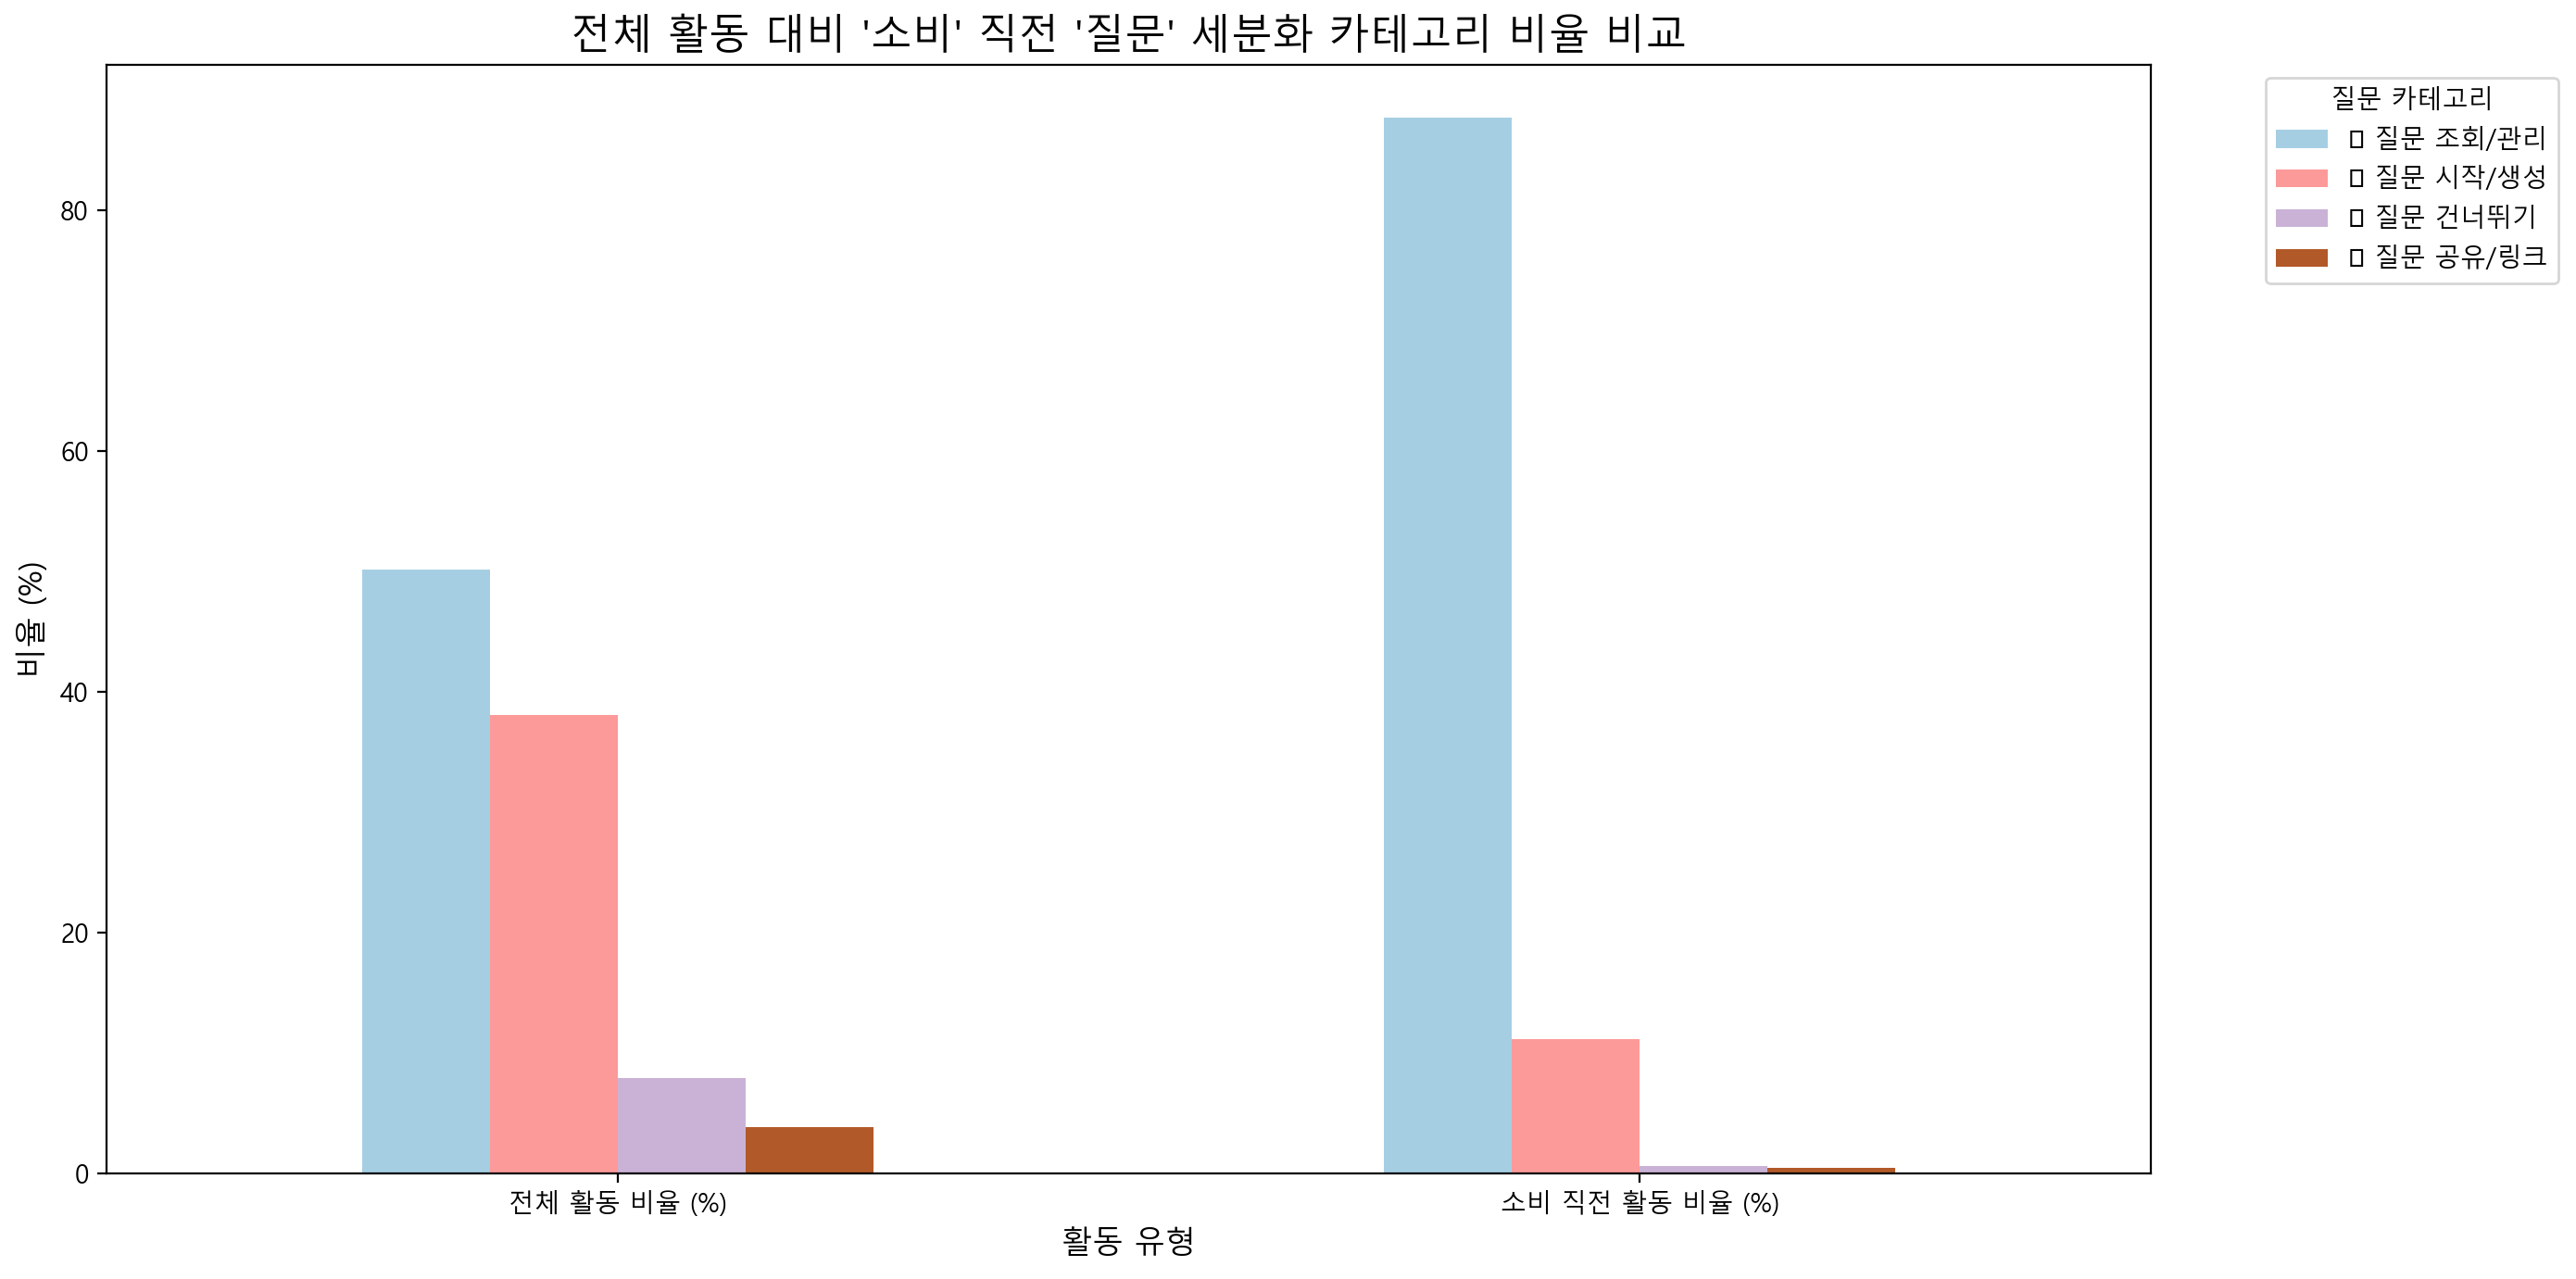


### 비교 검증 완료 ###


In [ ]:
# 1. 전체 데이터 내 '❓ 질문' 세분화 카테고리의 빈도와 비율 계산
overall_question_sub_category_counts = df[df['event_category'].isin(question_sub_categories)]['event_category'].value_counts()
total_overall_question_events = overall_question_sub_category_counts.sum()
overall_question_sub_category_proportions = (overall_question_sub_category_counts / total_overall_question_events) * 100

print("\n--- 1. 전체 데이터 내 '❓ 질문' 세분화 카테고리 활동 비율 (%) ---")
print(overall_question_sub_category_proportions.round(2))

# 2. '소비' 직전 '❓ 질문' 세분화 카테고리의 빈도와 비율 (이전 분석 결과 활용)
# (이 값은 이전 실행 결과에서 나온 것을 직접 입력합니다.)
frequency_of_specific_question_sub_categories_from_prev = pd.Series({
    '❓ 질문 조회/관리': 7566,
    '❓ 질문 시작/생성': 967,
    '❓ 질문 건너뛰기': 55,
    '❓ 질문 공유/링크': 40
})
total_leading_to_consumption_from_prev = frequency_of_specific_question_sub_categories_from_prev.sum() # 8628
leading_to_consumption_proportions = (frequency_of_specific_question_sub_categories_from_prev / total_leading_to_consumption_from_prev) * 100

print("\n--- 2. '소비' 직전 '❓ 질문' 세분화 카테고리 활동 비율 (%) (이전 분석 결과) ---")
print(leading_to_consumption_proportions.round(2))

# 3. 두 비율의 직접 비교 및 해석
comparison_df = pd.DataFrame({
    '전체 활동 비율 (%)': overall_question_sub_category_proportions,
    '소비 직전 활동 비율 (%)': leading_to_consumption_proportions
}).fillna(0).sort_values(by='전체 활동 비율 (%)', ascending=False) # 전체 활동 비율 기준으로 정렬

print("\n--- 3. 두 비율의 직접 비교 ---")
print(comparison_df.round(2))

# 시각화
comparison_df_T = comparison_df.T # 행과 열 전환
plt.figure(figsize=(14, 7))
comparison_df_T.plot(kind='bar', stacked=False, ax=plt.gca(), cmap='Paired')
plt.title("전체 활동 대비 '소비' 직전 '질문' 세분화 카테고리 비율 비교", fontsize=16)
plt.xlabel("활동 유형", fontsize=12)
plt.ylabel("비율 (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="질문 카테고리", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 비교 검증 완료 ###")


- 질문 세분화 카테고리의 '소비' 연계 영향력 검증
- 핵심 내용:

- 각 '질문' 세분화 카테고리가 전체 '질문' 활동 내에서 차지하는 비중과 '소비(하트 진입)' 직전에 발생한 '질문' 활동 내에서 차지하는 비중을 비교했습니다.


|카테고리|전체 활동 비율 (%)|소비 직전 활동 비율 (%)|
|-------|----------------|--------------------|
|❓ 질문 조회/관리|	50.13|	87.69|
|❓ 질문 시작/생성|	38.05|	11.21|
|❓ 질문 건너뛰기|	7.97|	0.64|
|❓ 질문 공유/링크|	3.85|	0.46|

- 인사이트:

    - 1. ❓ 질문 조회/관리는 '하트 니즈'의 핵심 유발자:

        - '질문 조회/관리'는 전체 '질문' 활동의 절반을 차지할 정도로 자주 일어나는 행동입니다.
        - 더 중요한 것은, '소비' 직전의 '질문' 활동 중에서는 거의 90%에 육박하는 비중을 차지한다는 점입니다.
        - 해석: 이는 '질문 조회/관리' 활동이 단순히 빈도가 높아서가 아니라, 실제로 사용자가 '하트/구매' 필요를 느끼는 매우 강력하고 핵심적인 순간임을 명확히 보여줍니다. 사용자들이 질문을 보거나 관리하는 과정에서 하트의 가치를 인식하거나 부족함을 느끼는 경우가 압도적으로 많습니다.
    - 2. ❓ 질문 시작/생성은 높은 빈도에 비해 '소비' 유발력은 낮음:

        - '질문 시작/생성'은 전체 '질문' 활동에서 두 번째로 큰 비중(38.05%)을 차지할 만큼 자주 일어납니다.
        - 하지만, '소비' 직전의 '질문' 활동에서는 비중이 11.21%로 전체 비중에 비해 현저히 낮습니다.
        - 해석: 사용자들이 질문을 시작하거나 생성하는 활동을 많이 하기는 하지만, 이 활동 자체가 '하트/구매'로 이어지는 직접적인 동기로 작용하는 경우는 상대적으로 적다는 것을 의미합니다. (즉, 빈도가 높더라도 '하트'와의 연관성이 높지는 않다).
    - 3. ❓ 질문 건너뛰기 및 ❓ 질문 공유/링크는 '소비'와 무관:

        - 이 두 카테고리는 전체 '질문' 활동 내 비중 자체가 낮습니다.
        - '소비' 직전 활동에서의 비중은 **거의 무시할 수 없는 수준(각각 1% 미만)**으로 급락합니다.
        - 해석: '질문 건너뛰기'나 '질문 공유/링크' 활동이 '소비'로 연결되는 빈도가 낮은 것은 단순히 그 활동 자체의 발생 빈도가 낮기 때문입니다. 더 나아가, 이 활동들은 사용자에게 '하트/구매' 필요성을 거의 유발하지 않는다고 판단할 수 있습니다. 즉, '소비'와는 거의 관련이 없는 활동입니다.

- 최종 결론: 이 검증을 통해 우리는 '질문 조회/관리' 활동이 사용자에게 '하트' 필요성을 가장 강력하게 인지시키고 구매로 이끄는 핵심 지점임을 확실히 알 수 있습니다. 단순한 활동 빈도를 넘어, 특정 활동이 비즈니스 목표에 얼마나 큰 영향력을 가지는지 명확하게 밝혀냈습니다.

 ## 가설 : 활동량이 높을 수록 결제를 할 확률이 높아진다!

### "활동량 : 총 이벤트 수" 로 정의 한 검증

- 결제 여부 정의: complete_purchase 이벤트를 발생시킨 사용자를 '결제 유저'로, 그렇지 않은 사용자를 '비결제 유저'로 정의합니다.
- 활동량 정의: 각 사용자의 총 이벤트 수를 활동량으로 정의합니다.
- 데이터 준비: 각 사용자의 활동량과 결제 여부를 통합한 요약 테이블을 생성합니다.
- 분포 시각화: '결제 유저'와 '비결제 유저'의 활동량 분포를 시각적으로 비교합니다. (클래스 불균형을 고려하여 y축을 로그 스케일로 시각화합니다.)
- 통계적 검정: 두 그룹의 활동량 분포가 통계적으로 유의미한 차이가 있는지 검정합니다.

### 가설 검증: 활동량과 결제 확률 ###

--- 1. 사용자별 결제 여부 정의 ---
총 사용자 수: 169115명
결제 유저 수: 1230명
비결제 유저 수: 167885명
--- 1. 사용자별 결제 여부 정의 완료 ---

--- 2. 활동량 정의 (사용자별 총 이벤트 수) ---
활동량 정의 기준: '사용자별 총 이벤트 수'
--- 2. 활동량 정의 완료 ---

--- 3. 사용자 요약 테이블 생성 ---
사용자 요약 테이블 샘플:
   user_id  activity_level  payment_status payment_status_str
0  1509275            4934           False             비결제 유저
1  1239557            4456           False             비결제 유저
2  1310826            4212           False             비결제 유저
3   981626            4159           False             비결제 유저
4  1154672            3745           False             비결제 유저
--- 3. 사용자 요약 테이블 생성 완료 ---

--- 4. 활동량 분포 시각화 ---


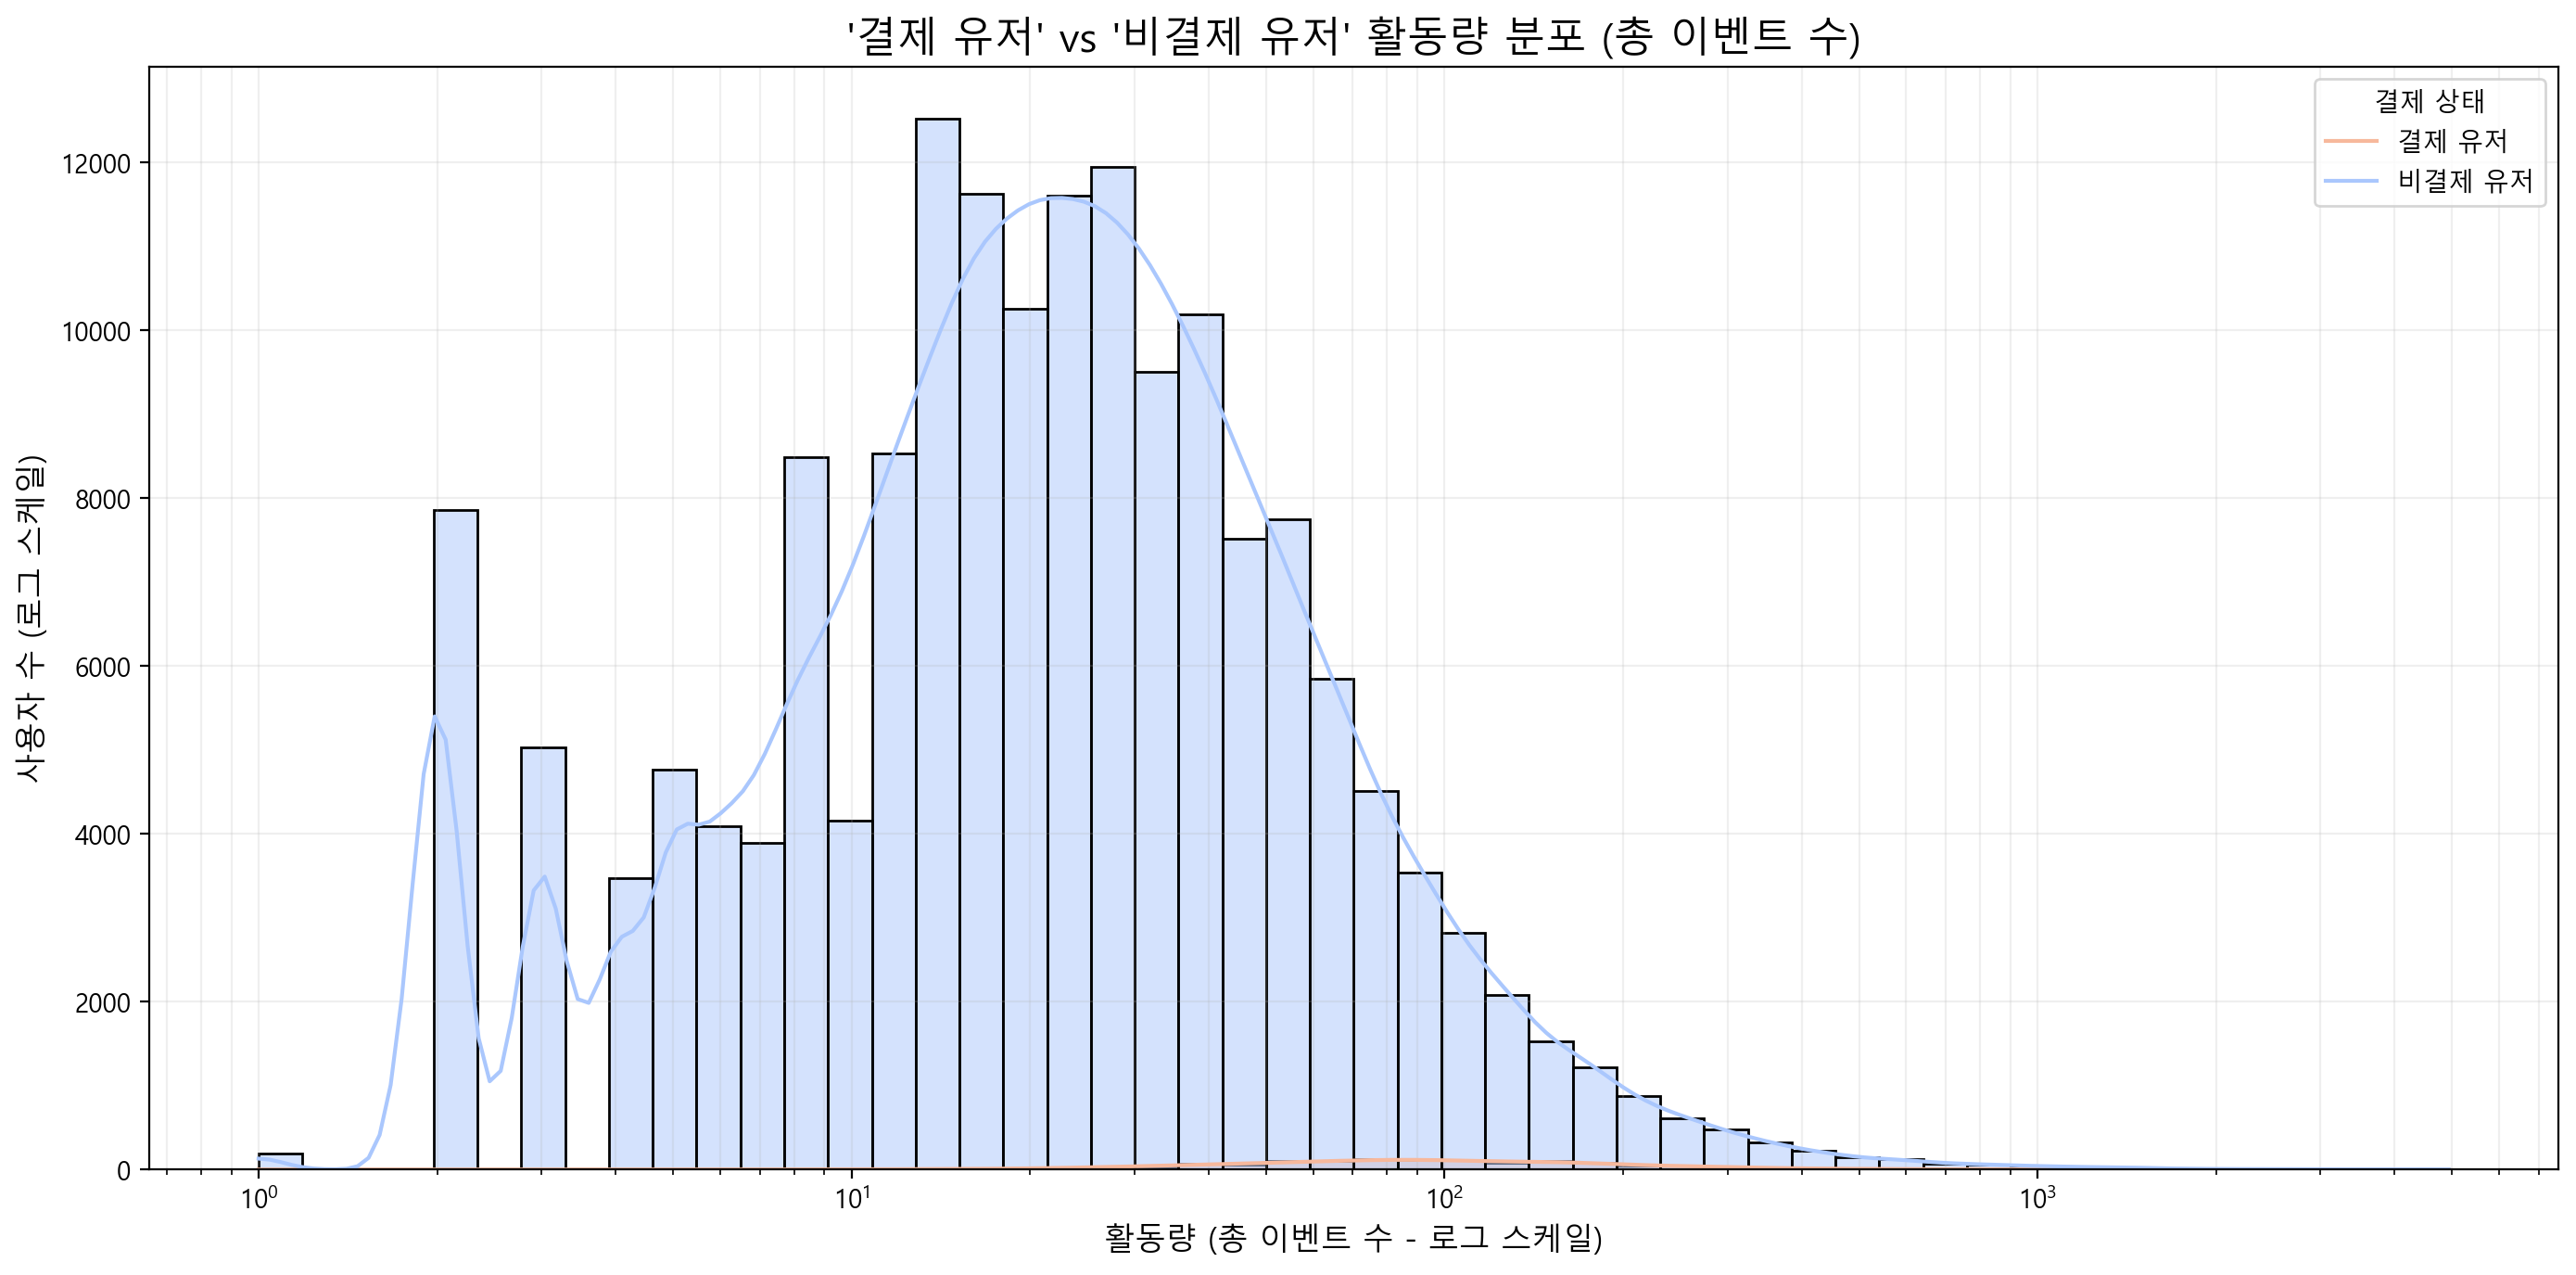

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\960002029.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




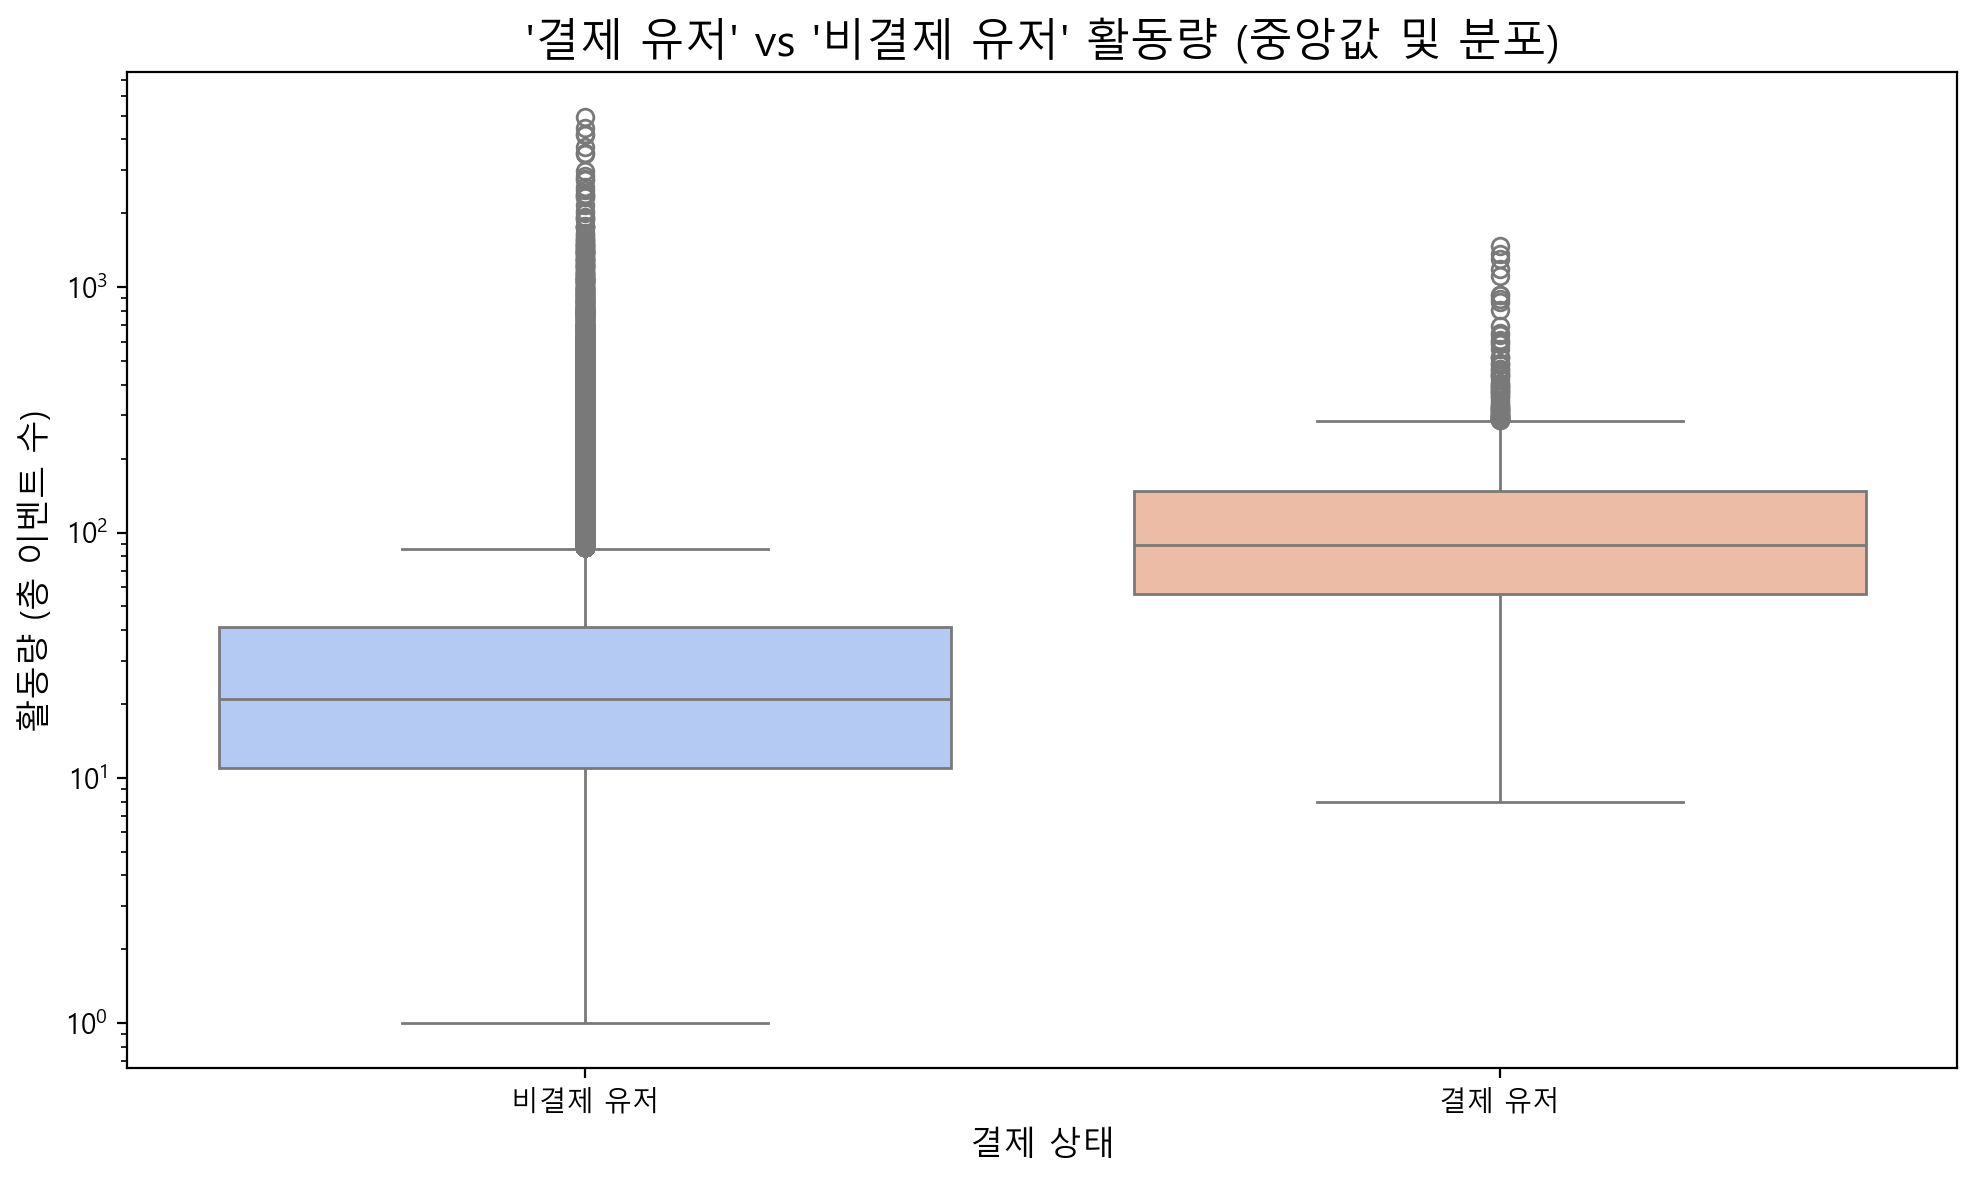

--- 4. 활동량 분포 시각화 완료 ---

--- 5. 통계적 검정 (Mann-Whitney U 검정) ---
가설: '활동량이 높을수록 결제를 할 확률이 높아진다.'
  - 귀무가설(H0): 결제 유저와 비결제 유저의 활동량 중앙값에는 차이가 없다.
  - 대립가설(H1): 결제 유저의 활동량 중앙값이 비결제 유저보다 유의미하게 높다.

Mann-Whitney U 통계량: 181273374.50
P-value: 0.0000
P-value (0.0000)는 유의수준 (0.05)보다 작으므로 귀무가설을 기각합니다.
=> 결제 유저의 활동량 중앙값이 비결제 유저보다 통계적으로 유의미하게 높다고 볼 수 있습니다.
=> '활동량이 높을수록 결제를 할 확률이 높아진다'는 가설에 대한 강력한 증거입니다.
--- 5. 통계적 검정 완료 ---

### 가설 검증 완료 ###


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 예시 ('AppleGothic' for Mac)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("### 가설 검증: 활동량과 결제 확률 ###")

# --- 1. 사용자별 결제 여부 정의 ---
print("\n--- 1. 사용자별 결제 여부 정의 ---")

# 'complete_purchase' 이벤트를 발생시킨 user_id 추출
paying_users_id = df[df['event_key'] == 'complete_purchase']['user_id'].unique()

# 전체 user_id 목록
all_users_id = df['user_id'].unique()

# 결제 상태를 True/False로 매핑한 딕셔너리 생성
user_payment_status = {user_id: user_id in paying_users_id for user_id in all_users_id}

print(f"총 사용자 수: {len(all_users_id)}명")
print(f"결제 유저 수: {len(paying_users_id)}명")
print(f"비결제 유저 수: {len(all_users_id) - len(paying_users_id)}명")
print("--- 1. 사용자별 결제 여부 정의 완료 ---")


# --- 2. 활동량 정의 (사용자별 총 이벤트 수) ---
print("\n--- 2. 활동량 정의 (사용자별 총 이벤트 수) ---")

# user_id 별 총 이벤트 수 계산
user_activity_counts = df['user_id'].value_counts().reset_index()
user_activity_counts.columns = ['user_id', 'activity_level']

print(f"활동량 정의 기준: '사용자별 총 이벤트 수'")
print("--- 2. 활동량 정의 완료 ---")


# --- 3. 사용자 요약 테이블 생성 ---
print("\n--- 3. 사용자 요약 테이블 생성 ---")

# 활동량 데이터에 결제 상태 정보 추가
user_summary_df = user_activity_counts.copy()
user_summary_df['payment_status'] = user_summary_df['user_id'].map(user_payment_status)
user_summary_df['payment_status_str'] = user_summary_df['payment_status'].apply(lambda x: '결제 유저' if x else '비결제 유저')

# 데이터 확인
print("사용자 요약 테이블 샘플:")
print(user_summary_df.head())
print("--- 3. 사용자 요약 테이블 생성 완료 ---")


# --- 4. 활동량 분포 시각화 (결제 유저 vs 비결제 유저) ---
print("\n--- 4. 활동량 분포 시각화 ---")

plt.figure(figsize=(14, 7))
sns.histplot(data=user_summary_df, x='activity_level', hue='payment_status_str',
             bins=50, kde=True, log_scale=True, palette='coolwarm') # y축 로그 스케일로 불균형 고려

plt.title("'결제 유저' vs '비결제 유저' 활동량 분포 (총 이벤트 수)", fontsize=16)
plt.xlabel("활동량 (총 이벤트 수 - 로그 스케일)", fontsize=12)
plt.ylabel("사용자 수 (로그 스케일)", fontsize=12)
plt.xscale('log') # x축도 로그 스케일로 전환하여 분포 확인 용이
plt.legend(title='결제 상태', labels=['결제 유저', '비결제 유저']) # 순서 변경될 수 있어 명시
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

# 추가: 박스플롯 또는 바이올린 플롯으로 중앙값/분포 비교
plt.figure(figsize=(10, 6))
sns.boxplot(data=user_summary_df, x='payment_status_str', y='activity_level', palette='coolwarm')
plt.title("'결제 유저' vs '비결제 유저' 활동량 (중앙값 및 분포)", fontsize=16)
plt.xlabel("결제 상태", fontsize=12)
plt.ylabel("활동량 (총 이벤트 수)", fontsize=12)
plt.yscale('log') # 활동량 편향 심할 경우 로그 스케일
plt.tight_layout()
plt.show()

print("--- 4. 활동량 분포 시각화 완료 ---")


# --- 5. 통계적 검정 (Mann-Whitney U 검정) ---
print("\n--- 5. 통계적 검정 (Mann-Whitney U 검정) ---")
print("가설: '활동량이 높을수록 결제를 할 확률이 높아진다.'")
print("  - 귀무가설(H0): 결제 유저와 비결제 유저의 활동량 중앙값에는 차이가 없다.")
print("  - 대립가설(H1): 결제 유저의 활동량 중앙값이 비결제 유저보다 유의미하게 높다.")


# 각 그룹의 활동량 데이터 추출
activity_paying = user_summary_df[user_summary_df['payment_status'] == True]['activity_level']
activity_non_paying = user_summary_df[user_summary_df['payment_status'] == False]['activity_level']

# Mann-Whitney U 검정 수행 (데이터가 정규분포를 따르지 않을 가능성이 높으므로)
# alternative='greater'는 대립가설이 "paying > non_paying" 일방향 검정
U_statistic, p_value = stats.mannwhitneyu(activity_paying, activity_non_paying, alternative='greater')

print(f"\nMann-Whitney U 통계량: {U_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05 # 유의수준

if p_value < alpha:
    print(f"P-value ({p_value:.4f})는 유의수준 ({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("=> 결제 유저의 활동량 중앙값이 비결제 유저보다 통계적으로 유의미하게 높다고 볼 수 있습니다.")
    print("=> '활동량이 높을수록 결제를 할 확률이 높아진다'는 가설에 대한 강력한 증거입니다.")
else:
    print(f"P-value ({p_value:.4f})는 유의수준 ({alpha})보다 크거나 같으므로 귀무가설을 기각할 수 없습니다.")
    print("=> 결제 유저와 비결제 유저의 활동량 중앙값에 통계적으로 유의미한 차이가 있다고 보기 어렵습니다.")

print("--- 5. 통계적 검정 완료 ---")

print("\n### 가설 검증 완료 ###")


- 1. 사용자별 결제 여부 및 활동량 정의
    - 전체 사용자 수는 169,115명이며, 이 중 결제 유저는 1,230명, 비결제 유저는 167,885명으로 결제하지 않은 사용자가 훨씬 많습니다.
    - 활동량은 각 사용자가 발생시킨 총 이벤트 수로 정의하였습니다.
- 2. 활동량 분포 및 통계 검정 결과
    - 결제 유저와 비결제 유저의 활동량 분포를 시각화하여 비교하였고, 결제 유저가 전반적으로 더 높은 활동량을 보임을 확인했습니다.
    - Mann-Whitney U 검정을 통해 두 그룹의 활동량 중앙값 차이가 통계적으로 유의미함을 검증하였습니다.
    - P-value가 0.0000으로 유의수준 0.05보다 훨씬 작아, 결제 유저의 활동량이 비결제 유저보다 유의미하게 높다고 결론지었습니다.
- 3. 결론
    - "활동량이 높을수록 결제를 할 확률이 높아진다"는 가설에 대한 강력한 증거가 확보되었습니다.
    - 이는 사용자 활동을 높이는 것이 결제 전환율 향상에 중요한 영향을 미친다는 점을 시사합니다.

---

- "활동량이 높은 유저는 당연히 결제할 확률이 늘어나겠지만 그 반대의 상황! 예를 들면 들어왔다가 별 활동을 안 하고 그냥 나간 사람(활동량 3회 미만 같은 경우)이 포함될 경우 당연하게 활동량이 높은 유저는 결제할 확률이 높다! 라고 나타나는 거 아니야?"

### 총 이벤트 수 외의 추가 보조지표를 통한 통계적 검증

- 1. '총 이벤트 수' 외의 보조 지표 추가:

    - 총 세션 수 (total_sessions): 앱을 얼마나 자주 방문했는지
    - 활성 일수 (active_days): 앱을 얼마나 꾸준히 사용했는지
    - 핵심 기능 이벤트 수 (core_events): 앱의 주요 기능(질문 관련)을 얼마나 깊이 사용했는지 와 같이 활동량의 '질적' 측면을 고려할 수 있는 지표들을 추가했습니다.
- 2. 클래스 불균형에 대한 추가 검증: 이전에 histplot에서 log_scale을 사용했지만, boxplot을 통해 각 그룹의 중앙값과 분포의 세부적인 차이를 직관적으로 비교하고, 각 보조 지표에 대해서도 통계 검정을 반복함으로써 가설의 견고함을 다지려 했습니다.

- 3. 데이터 클러스터링 기반 분석 제안의 배경: 활동량이 극히 낮은 그룹의 영향을 배제하고, '의미 있는' 활동량을 보이는 사용자들 내에서 결제 전환을 이끄는 활동량의 특성을 파악하기 위해 **'활동량 기준으로 유저를 군집화해서 각 군집별 결제율 차이를 분석'**하는 방법을 제안한 것입니다. 이는 활동량이 낮은 사용자 그룹을 '아예 제거할까?' 하는 채소리1님의 질문에 대한 대안적인, 더 통찰력 있는 접근법이 될 수 있기 때문입니다.

In [ ]:
print(df['event_datetime'].dtype)  # 데이터 타입 확인

# datetime 형식이 아니라면 변환
if not pd.api.types.is_datetime64_any_dtype(df['event_datetime']):
    df['event_datetime'] = pd.to_datetime(df['event_datetime'], errors='coerce')
    print("event_datetime 컬럼을 datetime 형식으로 변환했습니다.")

object
event_datetime 컬럼을 datetime 형식으로 변환했습니다.


총 사용자 수: 169115명
결제 유저 수: 1230명
비결제 유저 수: 167885명


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2138381707.py:65: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




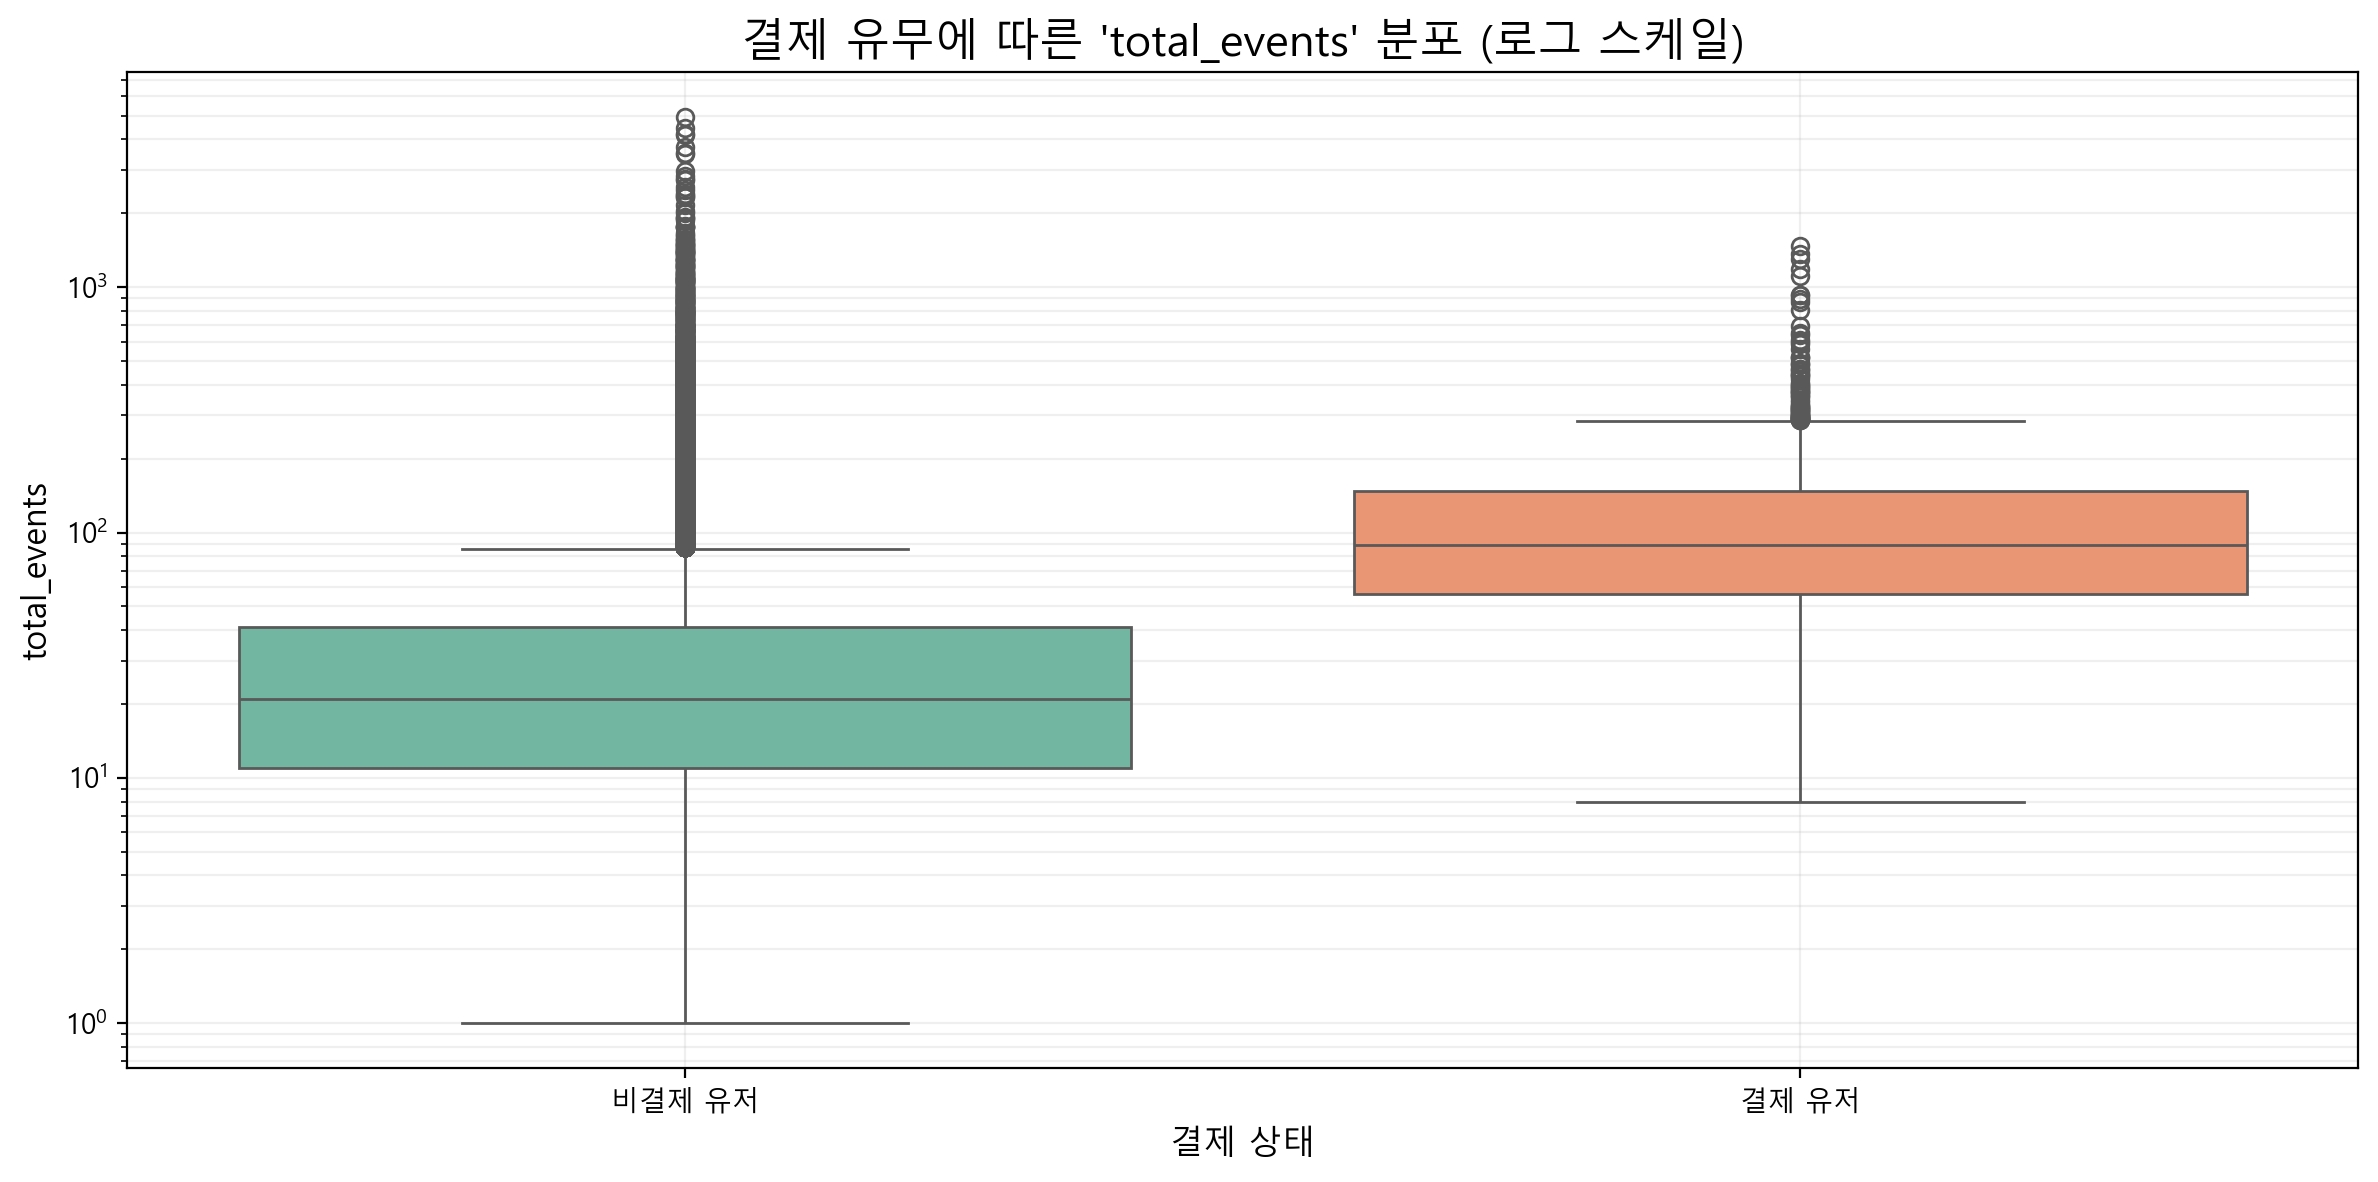

통계 검정 결과 - total_events:
  Mann-Whitney U 통계량 = 181273374.50, P-value = 0.0000e+00
  => 결제 유저의 'total_events'가 비결제 유저보다 유의미하게 높음



C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2138381707.py:65: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




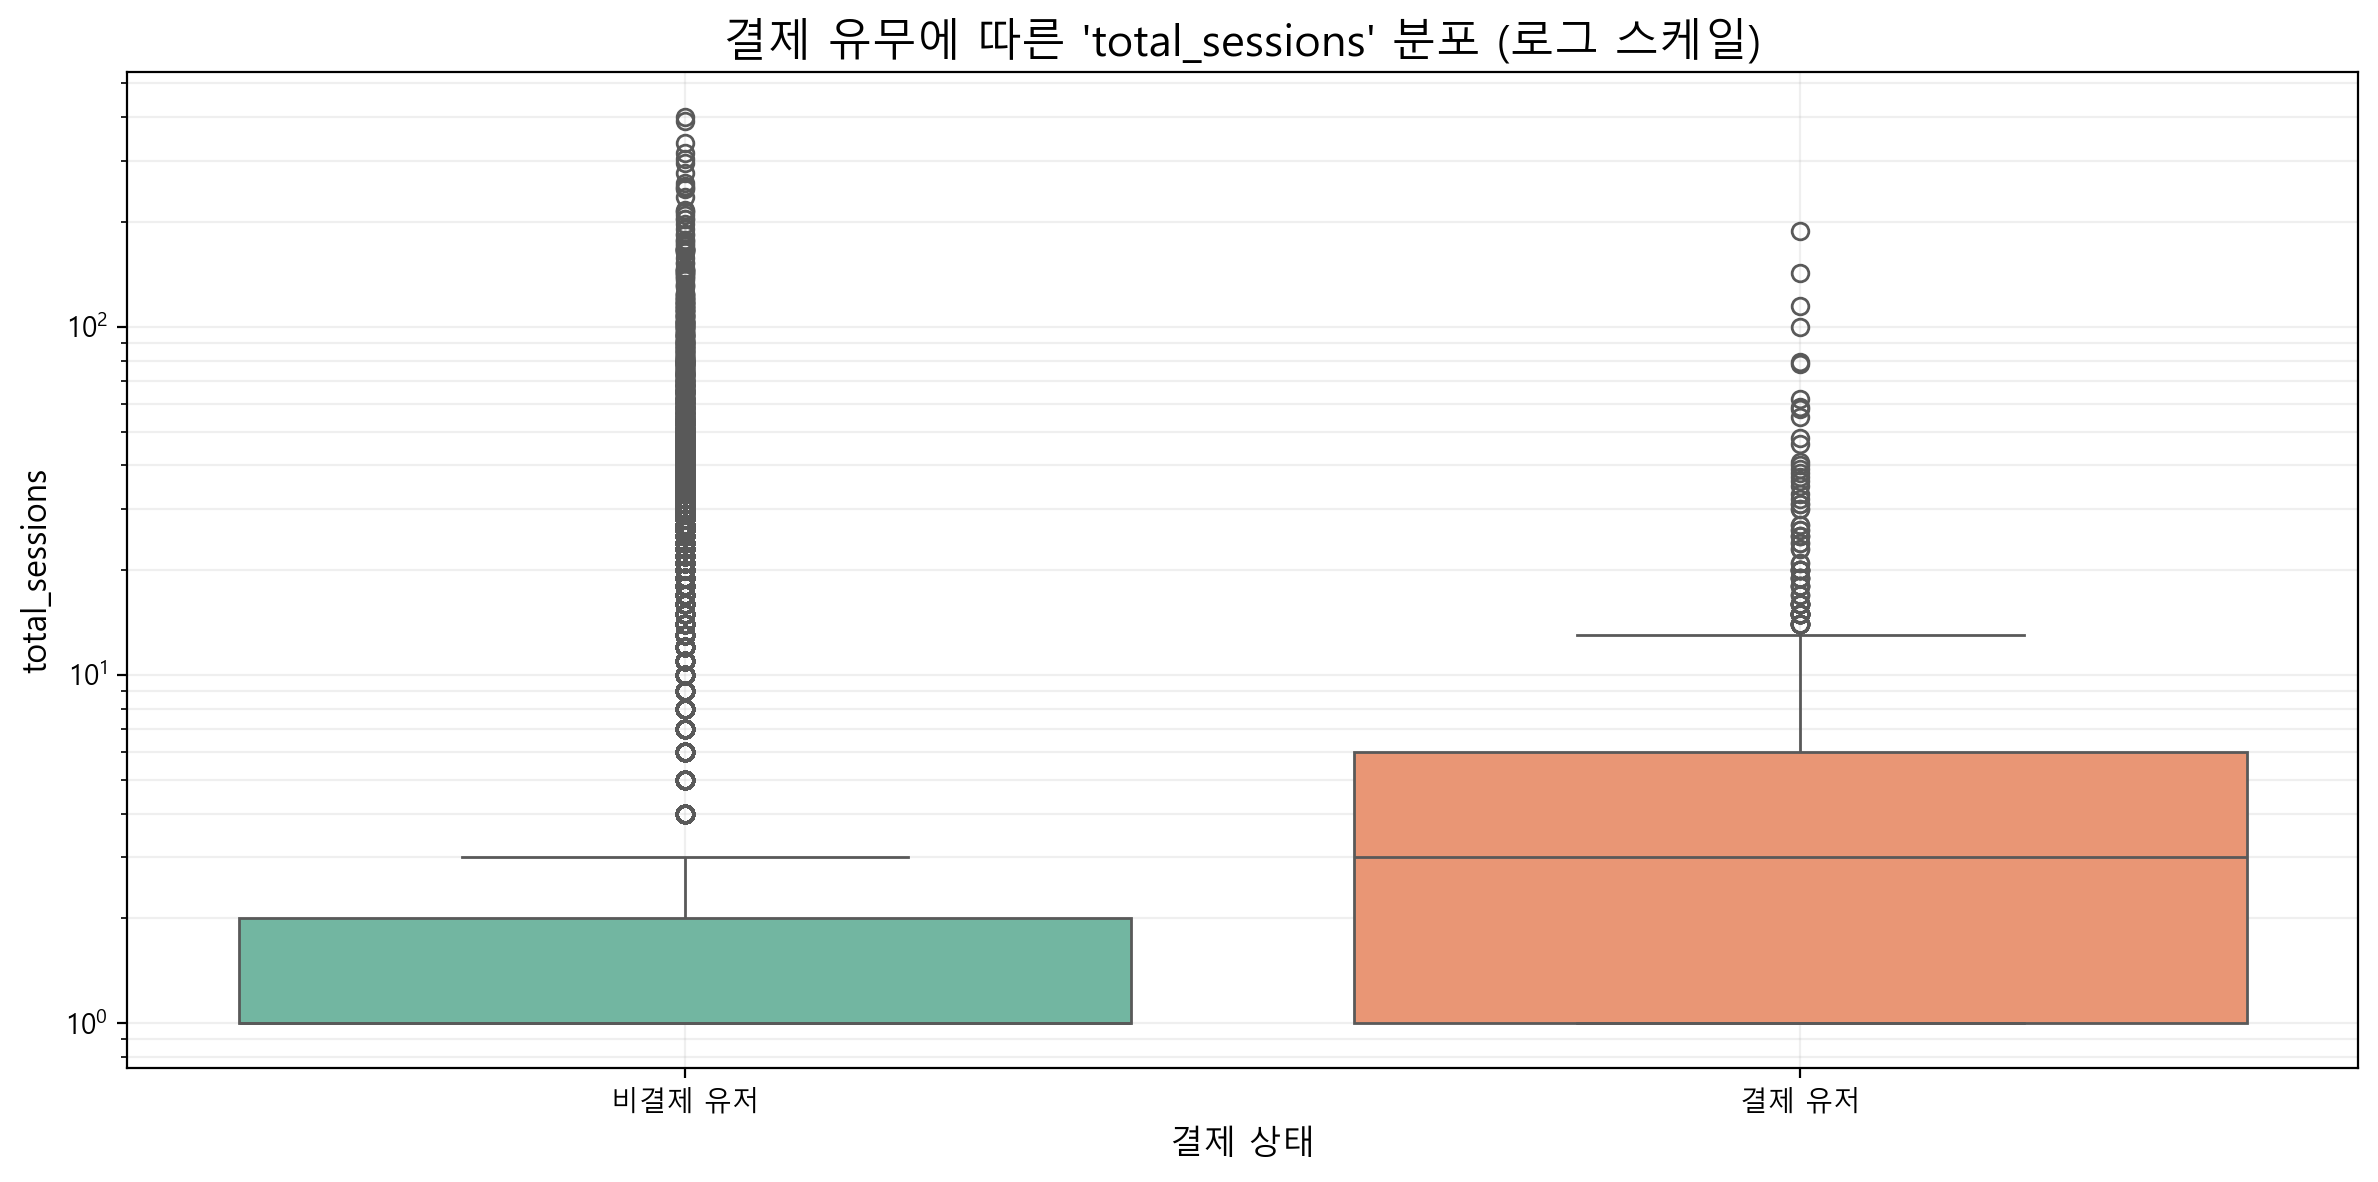

통계 검정 결과 - total_sessions:
  Mann-Whitney U 통계량 = 145786016.50, P-value = 1.4767e-189
  => 결제 유저의 'total_sessions'가 비결제 유저보다 유의미하게 높음



C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2138381707.py:65: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




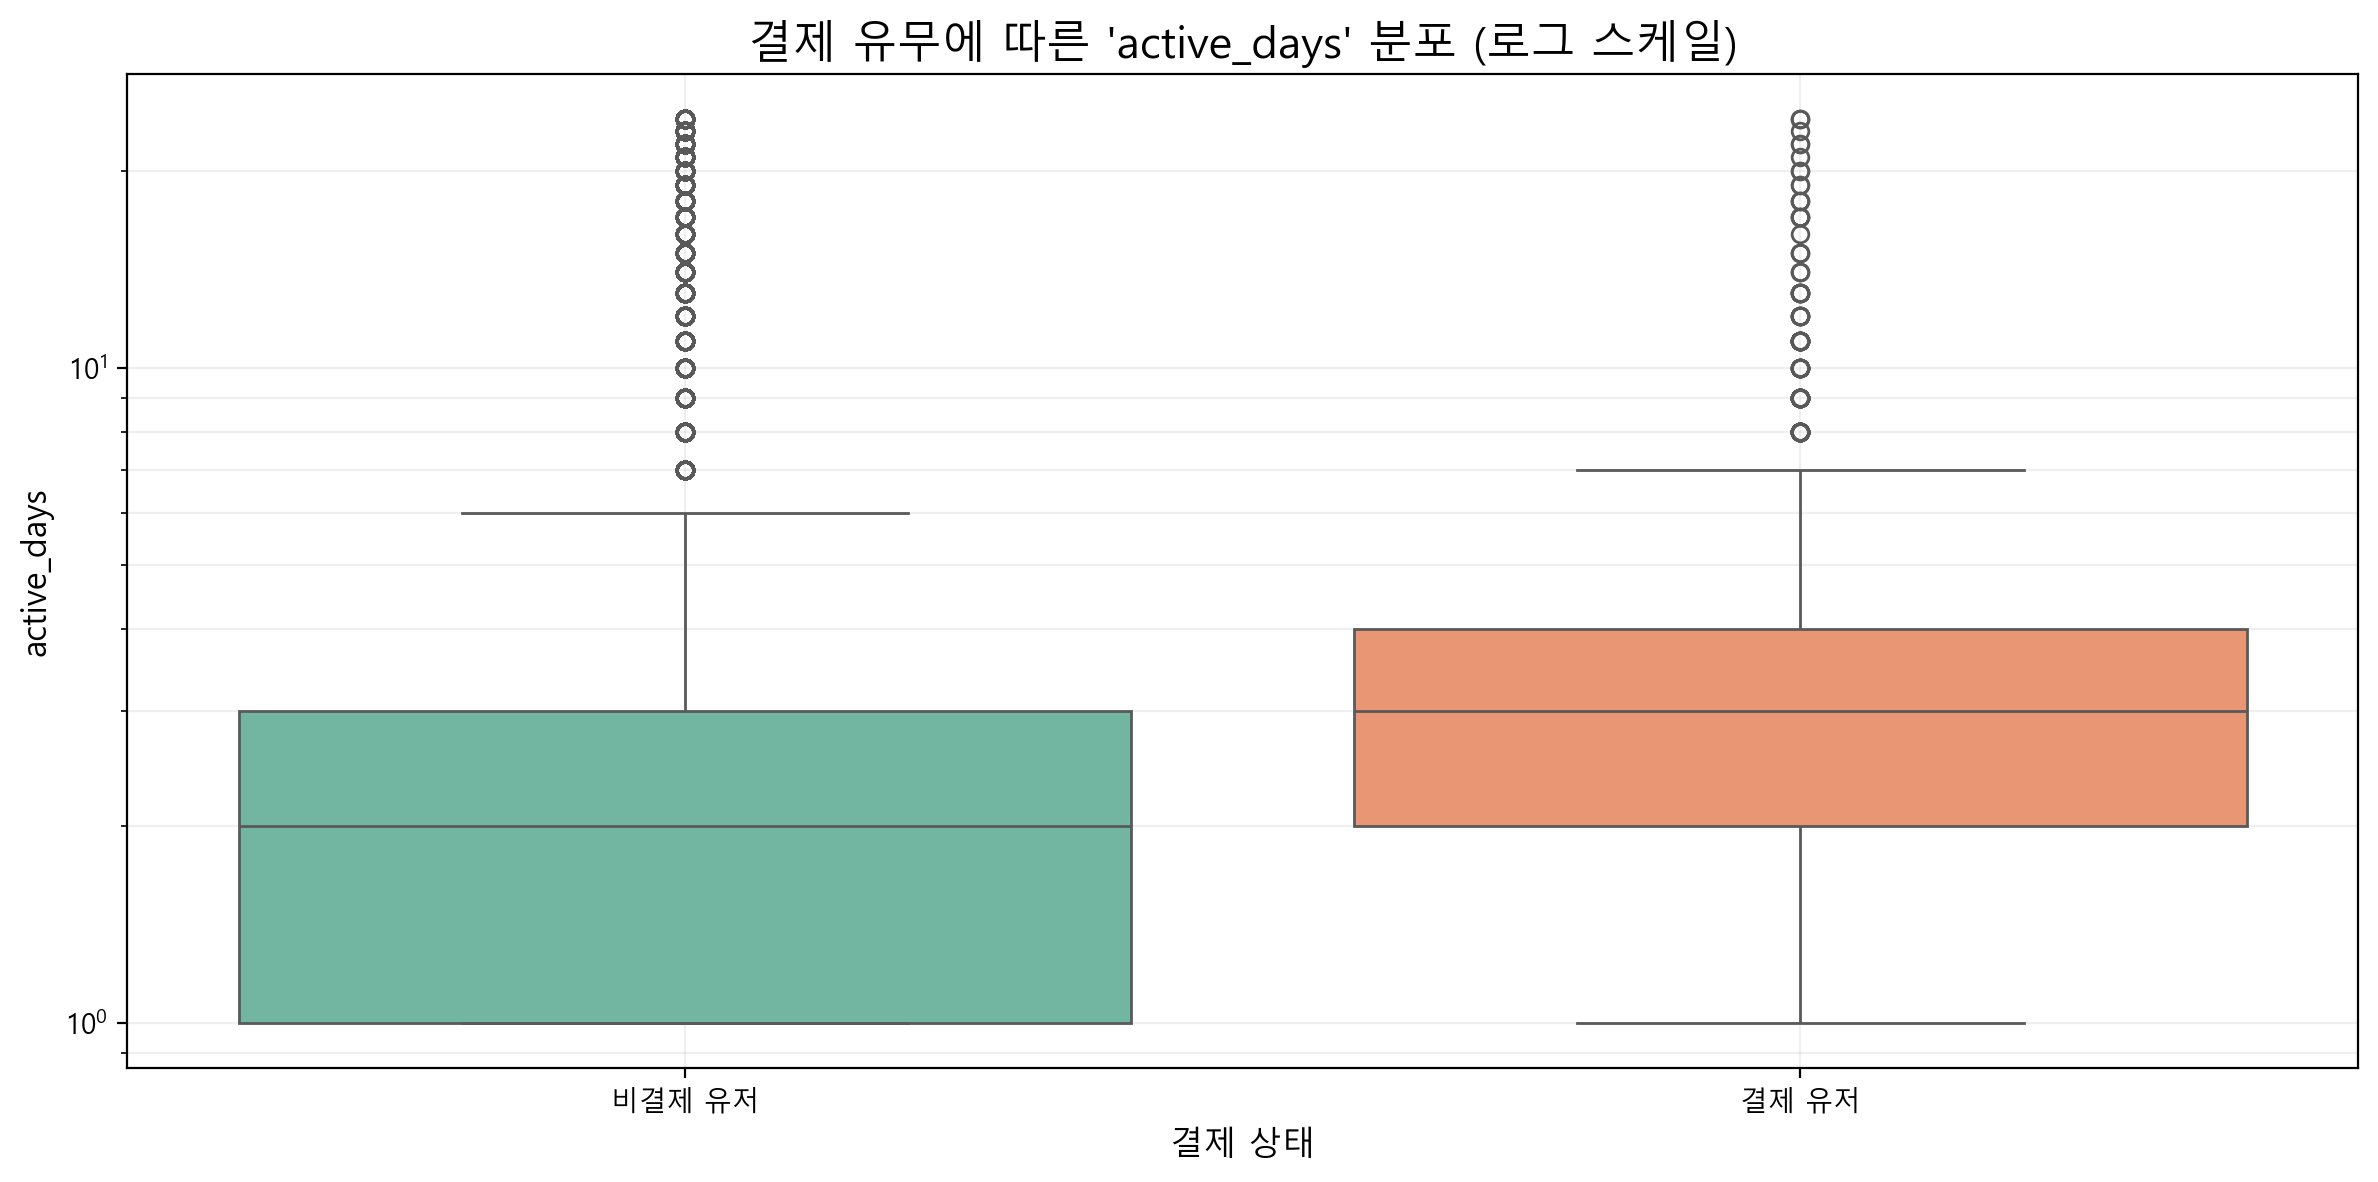

통계 검정 결과 - active_days:
  Mann-Whitney U 통계량 = 139771311.50, P-value = 5.5406e-115
  => 결제 유저의 'active_days'가 비결제 유저보다 유의미하게 높음



C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2138381707.py:65: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




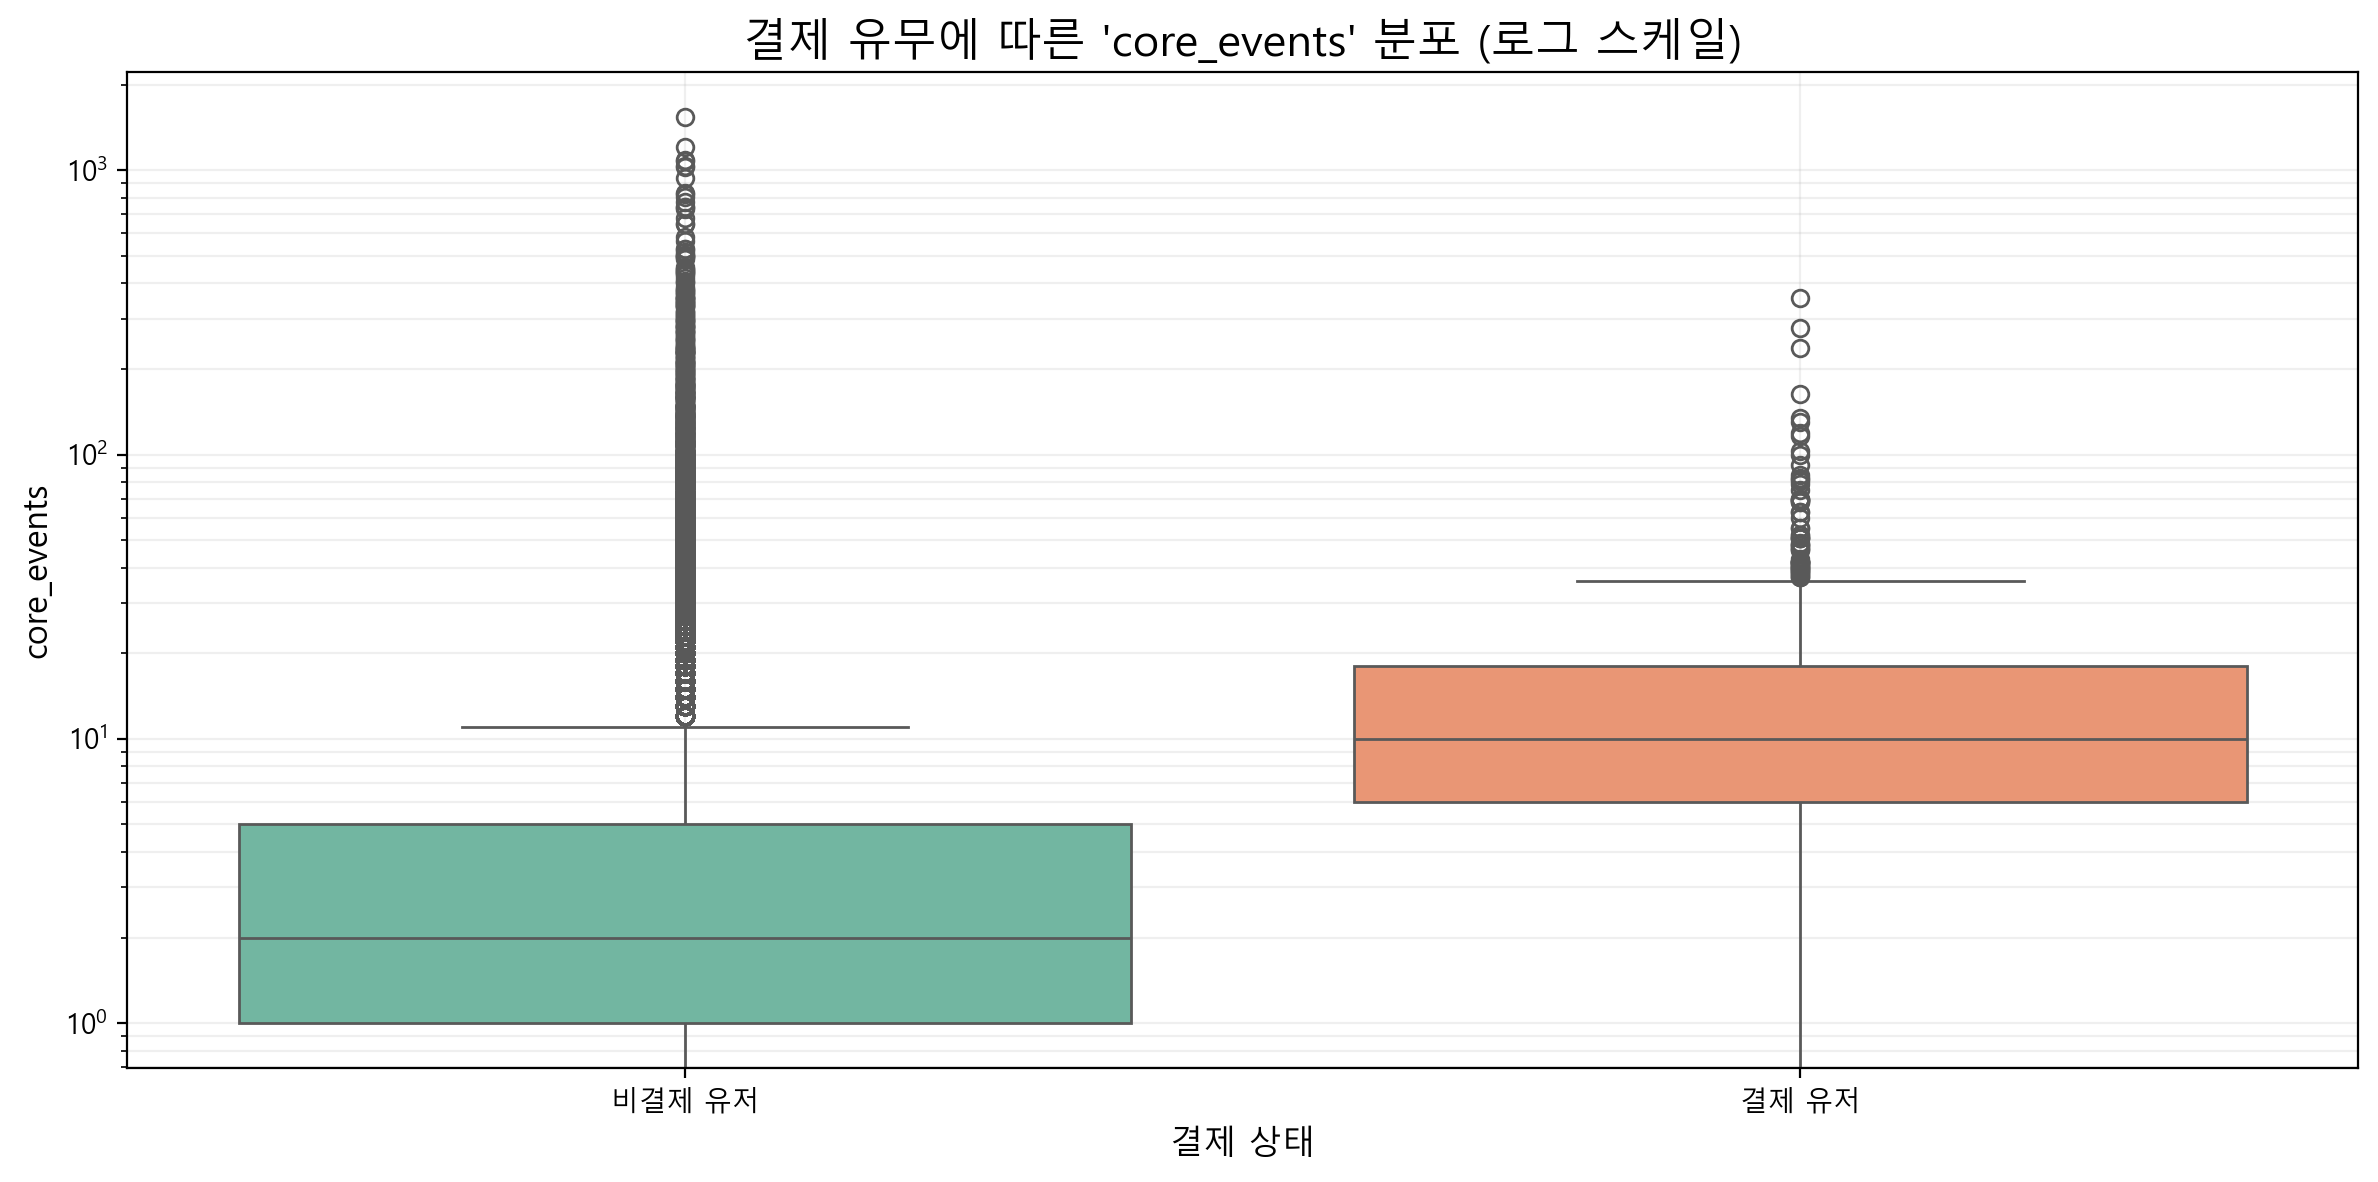

통계 검정 결과 - core_events:
  Mann-Whitney U 통계량 = 172164056.00, P-value = 0.0000e+00
  => 결제 유저의 'core_events'가 비결제 유저보다 유의미하게 높음



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# --- 데이터 준비 ---
# df는 event_category 컬럼이 포함된 전체 이벤트 데이터프레임입니다.
# (이전에 'event_datetime' 변환과 'NaN' 문제 해결까지 완료된 df를 사용해야 합니다.)

# 1. 사용자별 결제 여부 정의
paying_users = df[df['event_key'] == 'complete_purchase']['user_id'].unique()
all_users = df['user_id'].unique()
user_payment = {uid: (uid in paying_users) for uid in all_users}

# 2. 사용자별 기본 활동량: 총 이벤트 수
user_event_counts = df['user_id'].value_counts().reset_index()
user_event_counts.columns = ['user_id', 'total_events']

# 3. 사용자별 보조 활동량 지표 계산
# 3.1 총 세션 수
user_session_counts = df.groupby('user_id')['session_id'].nunique().reset_index()
user_session_counts.columns = ['user_id', 'total_sessions']

# 3.2 활성 일수 (고유 날짜 수)
# df['event_datetime']이 datetime 타입인지 다시 확인하고 변환 (이전 에러 해결용 코드 재사용)
if not pd.api.types.is_datetime64_any_dtype(df['event_datetime']):
    df['event_datetime'] = pd.to_datetime(df['event_datetime'], errors='coerce')
    print("event_datetime 컬럼을 datetime 형식으로 변환했습니다.")
df['event_date'] = df['event_datetime'].dt.date # datetime 타입으로 변환된 후 .dt 사용
user_active_days = df.groupby('user_id')['event_date'].nunique().reset_index()
user_active_days.columns = ['user_id', 'active_days']

# 3.3 핵심 기능 이벤트 수 (세분화된 '질문' 카테고리 모두 포함)
# '❓ 질문 생성/공유/답변 등' 이라는 카테고리는 이제 존재하지 않습니다.
# 대신 아래 세분화된 카테고리들을 합산해야 합니다.
question_sub_categories_for_core_events = [
    '❓ 질문 시작/생성',
    '❓ 질문 조회/관리',
    '❓ 질문 건너뛰기',
    '❓ 질문 공유/링크'
]

# 이제 세분화된 질문 카테고리에 속하는 모든 이벤트의 개수를 센다.
user_core_events = df[df['event_category'].isin(question_sub_categories_for_core_events)].groupby('user_id').size().reset_index(name='core_events')


# 4. 사용자 요약 테이블 통합
user_summary = user_event_counts.merge(user_session_counts, on='user_id', how='left') \
                                .merge(user_active_days, on='user_id', how='left') \
                                .merge(user_core_events, on='user_id', how='left') \
                                .fillna({'core_events':0}) # core_events는 NaN이 될 수 있으므로 0으로 채움


user_summary['payment_status'] = user_summary['user_id'].map(user_payment)
user_summary['payment_status_str'] = user_summary['payment_status'].apply(lambda x: '결제 유저' if x else '비결제 유저')

print(f"총 사용자 수: {len(user_summary)}명")
print(f"결제 유저 수: {user_summary['payment_status'].sum()}명")
print(f"비결제 유저 수: {len(user_summary) - user_summary['payment_status'].sum()}명")

# 5. 각 활동량 지표별 분포 시각화 및 통계 검정 함수 정의
def plot_and_test(feature):
    plt.figure(figsize=(12,6))
    sns.boxplot(data=user_summary, x='payment_status_str', y=feature, palette='Set2')
    plt.title(f"결제 유무에 따른 '{feature}' 분포 (로그 스케일)", fontsize=16)
    plt.yscale('log') # 활동량 편향 심할 경우 로그 스케일
    plt.xlabel("결제 상태", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()

    paying = user_summary[user_summary['payment_status'] == True][feature]
    non_paying = user_summary[user_summary['payment_status'] == False][feature]

    # 데이터가 비어있지 않은 경우에만 통계 검정 실행
    if not paying.empty and not non_paying.empty:
        U_stat, p_val = stats.mannwhitneyu(paying, non_paying, alternative='greater')
        print(f"통계 검정 결과 - {feature}:")
        print(f"  Mann-Whitney U 통계량 = {U_stat:.2f}, P-value = {p_val:.4e}")
        if p_val < 0.05:
            print(f"  => 결제 유저의 '{feature}'가 비결제 유저보다 유의미하게 높음\n")
        else:
            print(f"  => 두 그룹 간 '{feature}' 차이가 통계적으로 유의미하지 않음\n")
    else:
        print(f"'{feature}' 데이터가 부족하여 통계 검정을 실행할 수 없습니다.\n")

# 6. 주요 활동량 지표별 분석 실행
# 'event_datetime' 변환 에러 해결 및 'core_events' 계산 로직 수정 후 이 코드 실행
features_to_test = ['total_events', 'total_sessions', 'active_days', 'core_events']

for feat in features_to_test:
    plot_and_test(feat)


- 결과 : 추가 보조 지표를 넣어도 유의미한 결과로 도출 !
- 의문점 : 활동량이 많을 수록 결제를 많이 하는지 안하는지에 대한 여부는 미지수지만, 그 반대의 경우 비결제 하는 것이 당연한 현상이기에, 군집 분석을 통해 이를 확인 해 줄 필요성이 있다.

## 군집 분석

### 활동량 기준 유저 군집화 및 결제율 분석 ###
총 사용자 수: 169115명
결제 유저 수: 1230명
비결제 유저 수: 167885명

--- 최적의 K (군집 개수) 탐색 (엘보우 방법) ---


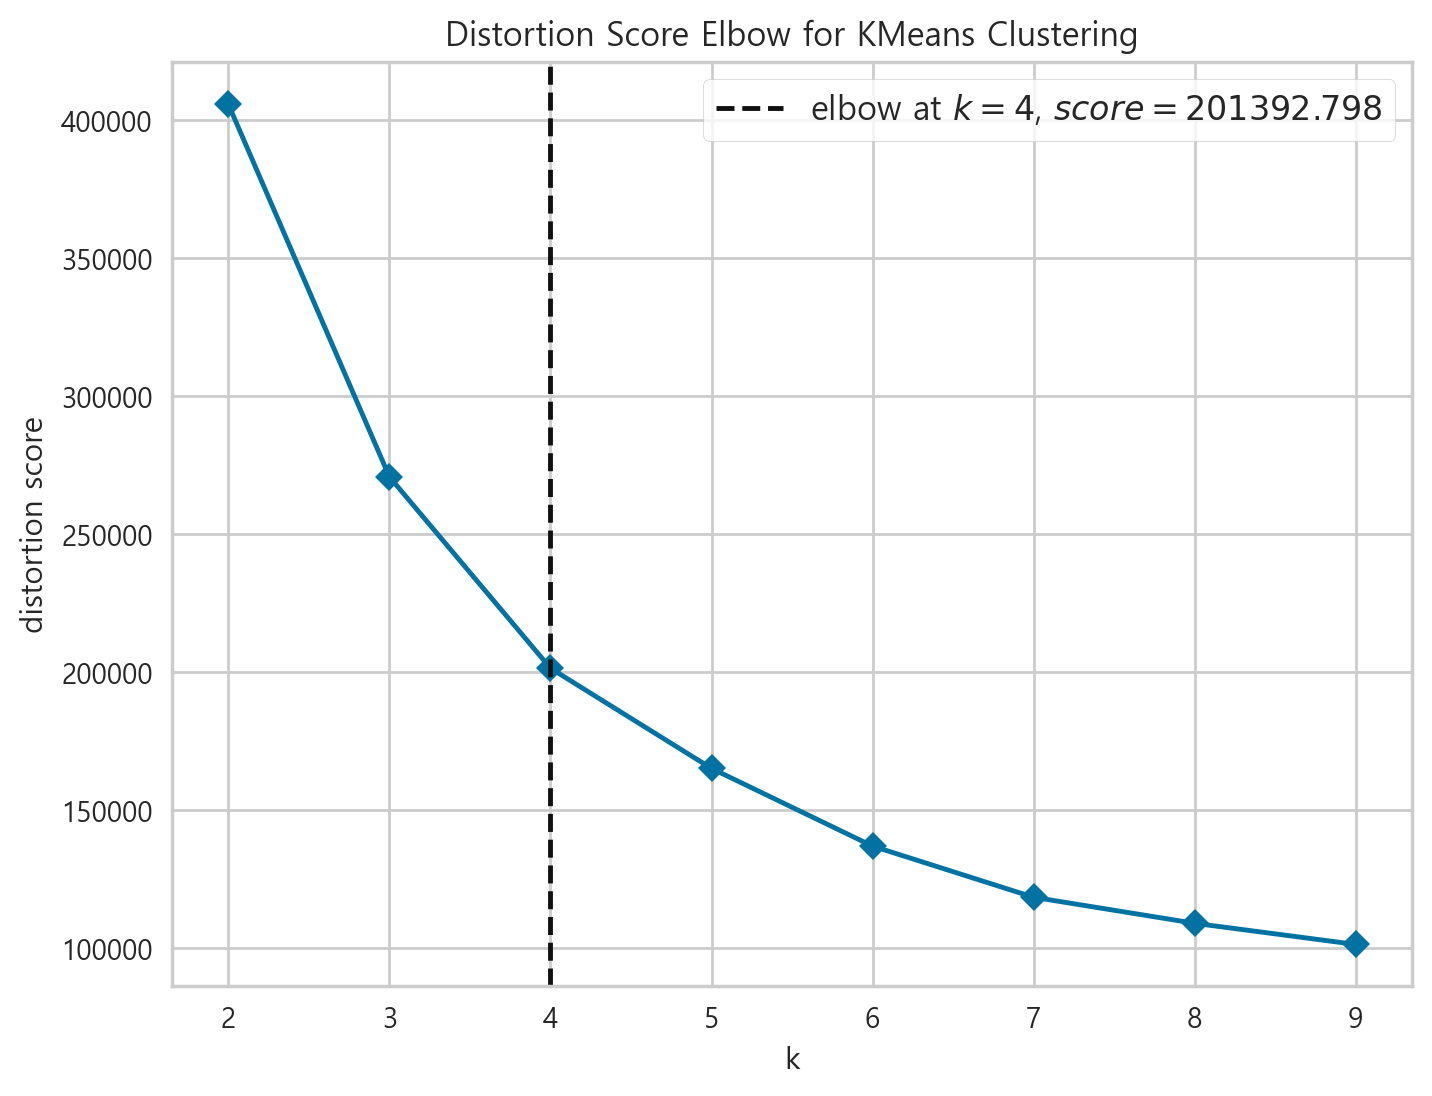

-> 엘보우 차트에서 꺾이는 지점을 찾아 최적의 K를 결정하세요. (가장 적절한 K값을 아래 `optimal_k`에 직접 입력하세요.)

결정된 최적의 K (군집 개수): 3

--- K-Means 군집화 완료 (3개 군집 생성) ---

--- 군집별 특성 분석 ---

 군집별 사용자 수:
 cluster
0    162019
1      6896
2       200
Name: count, dtype: int64

 군집별 평균 활동량 지표:
         total_events  total_sessions  active_days  core_events
cluster                                                        
0               28.69            1.85         2.07         3.47
1              207.34           20.90        12.07        31.37
2             1260.80          119.17        21.31       314.20

군집별 결제율 (%):
 cluster
0    0.64
1    2.74
2    2.50
Name: payment_status, dtype: float64

--- 통합 군집 분석 결과 (결제율 높은 순 정렬) ---
         total_events  total_sessions  active_days  core_events  user_count  payment_rate
cluster                                                                                  
1              207.34           20.90        12.07        31.37        6896          2.74
2             1260.80          1

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\3726113507.py:85: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




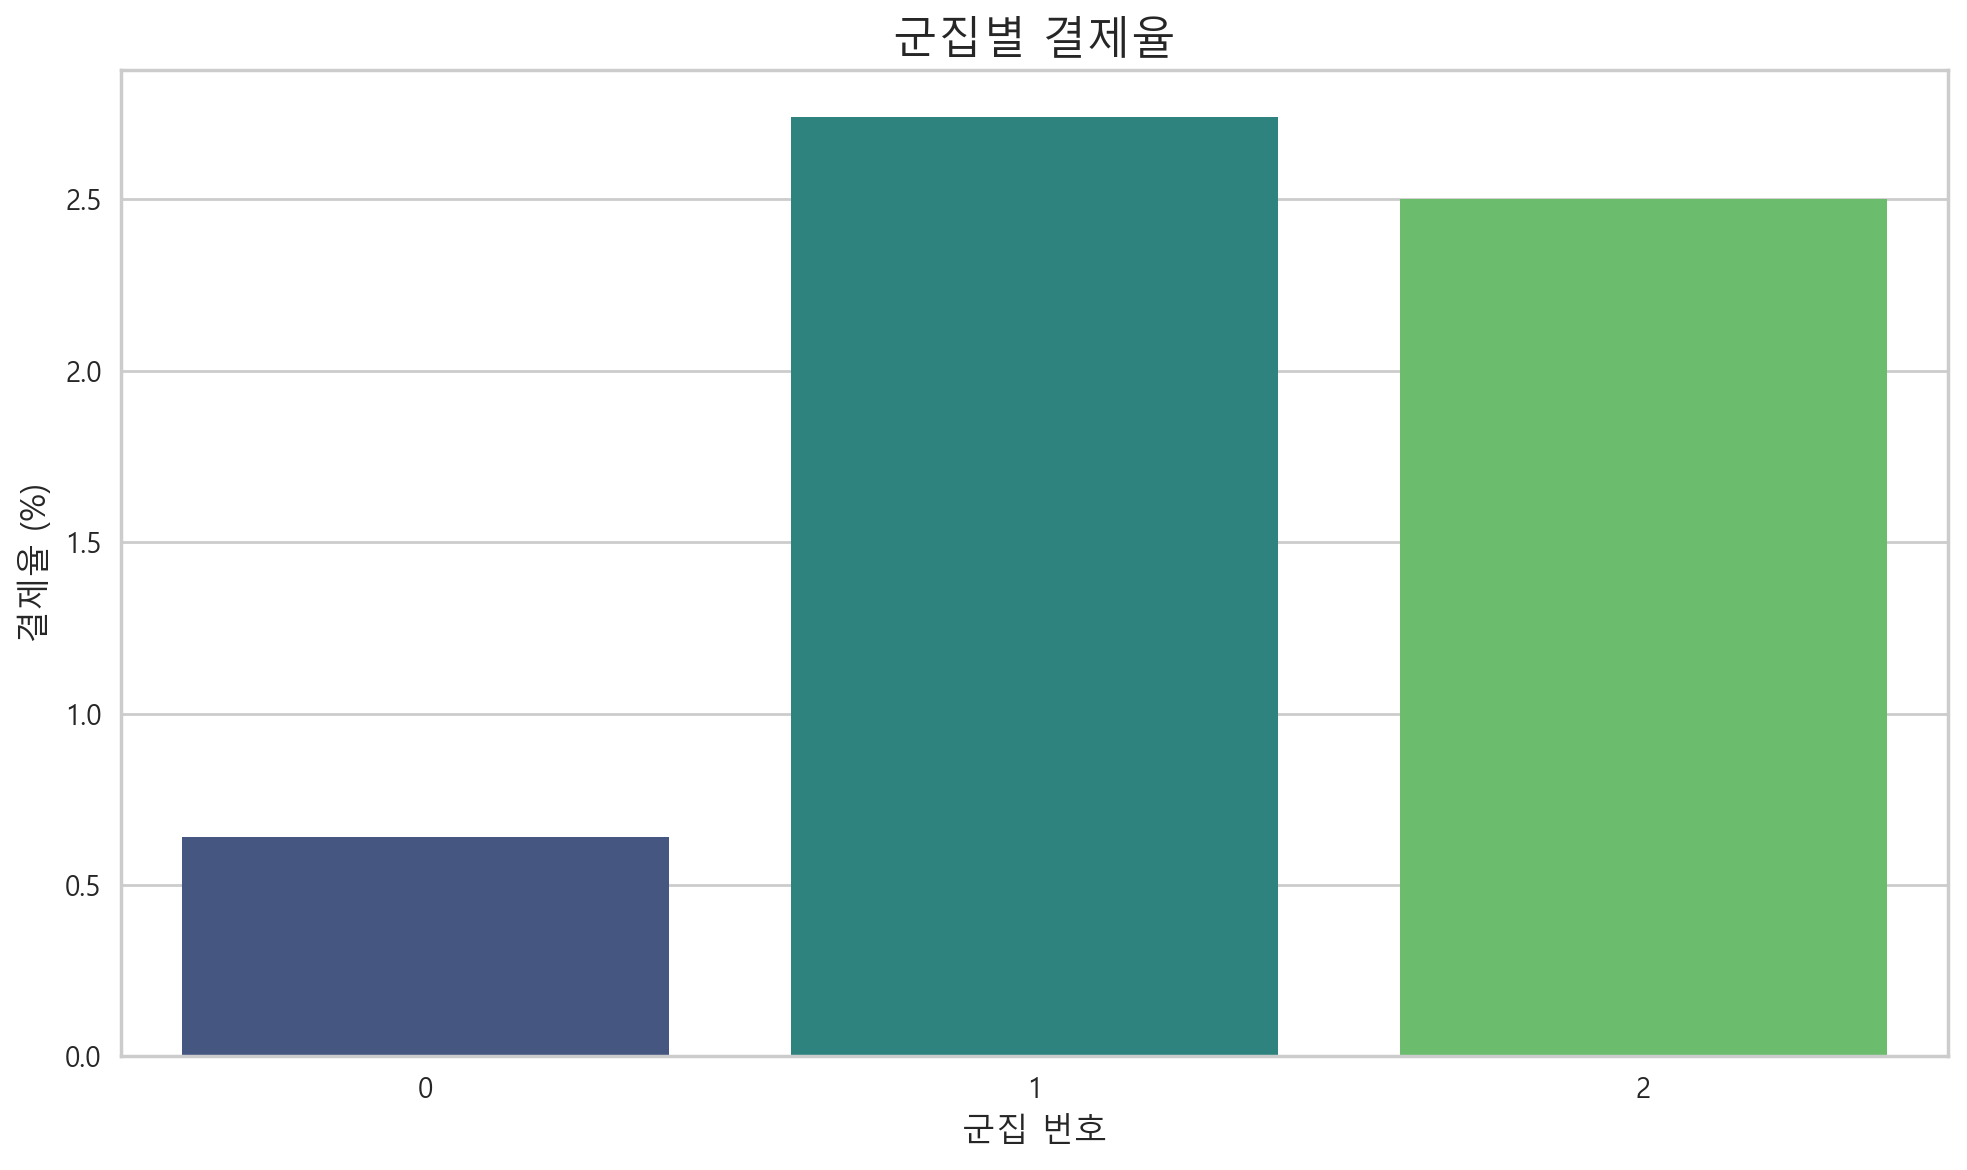

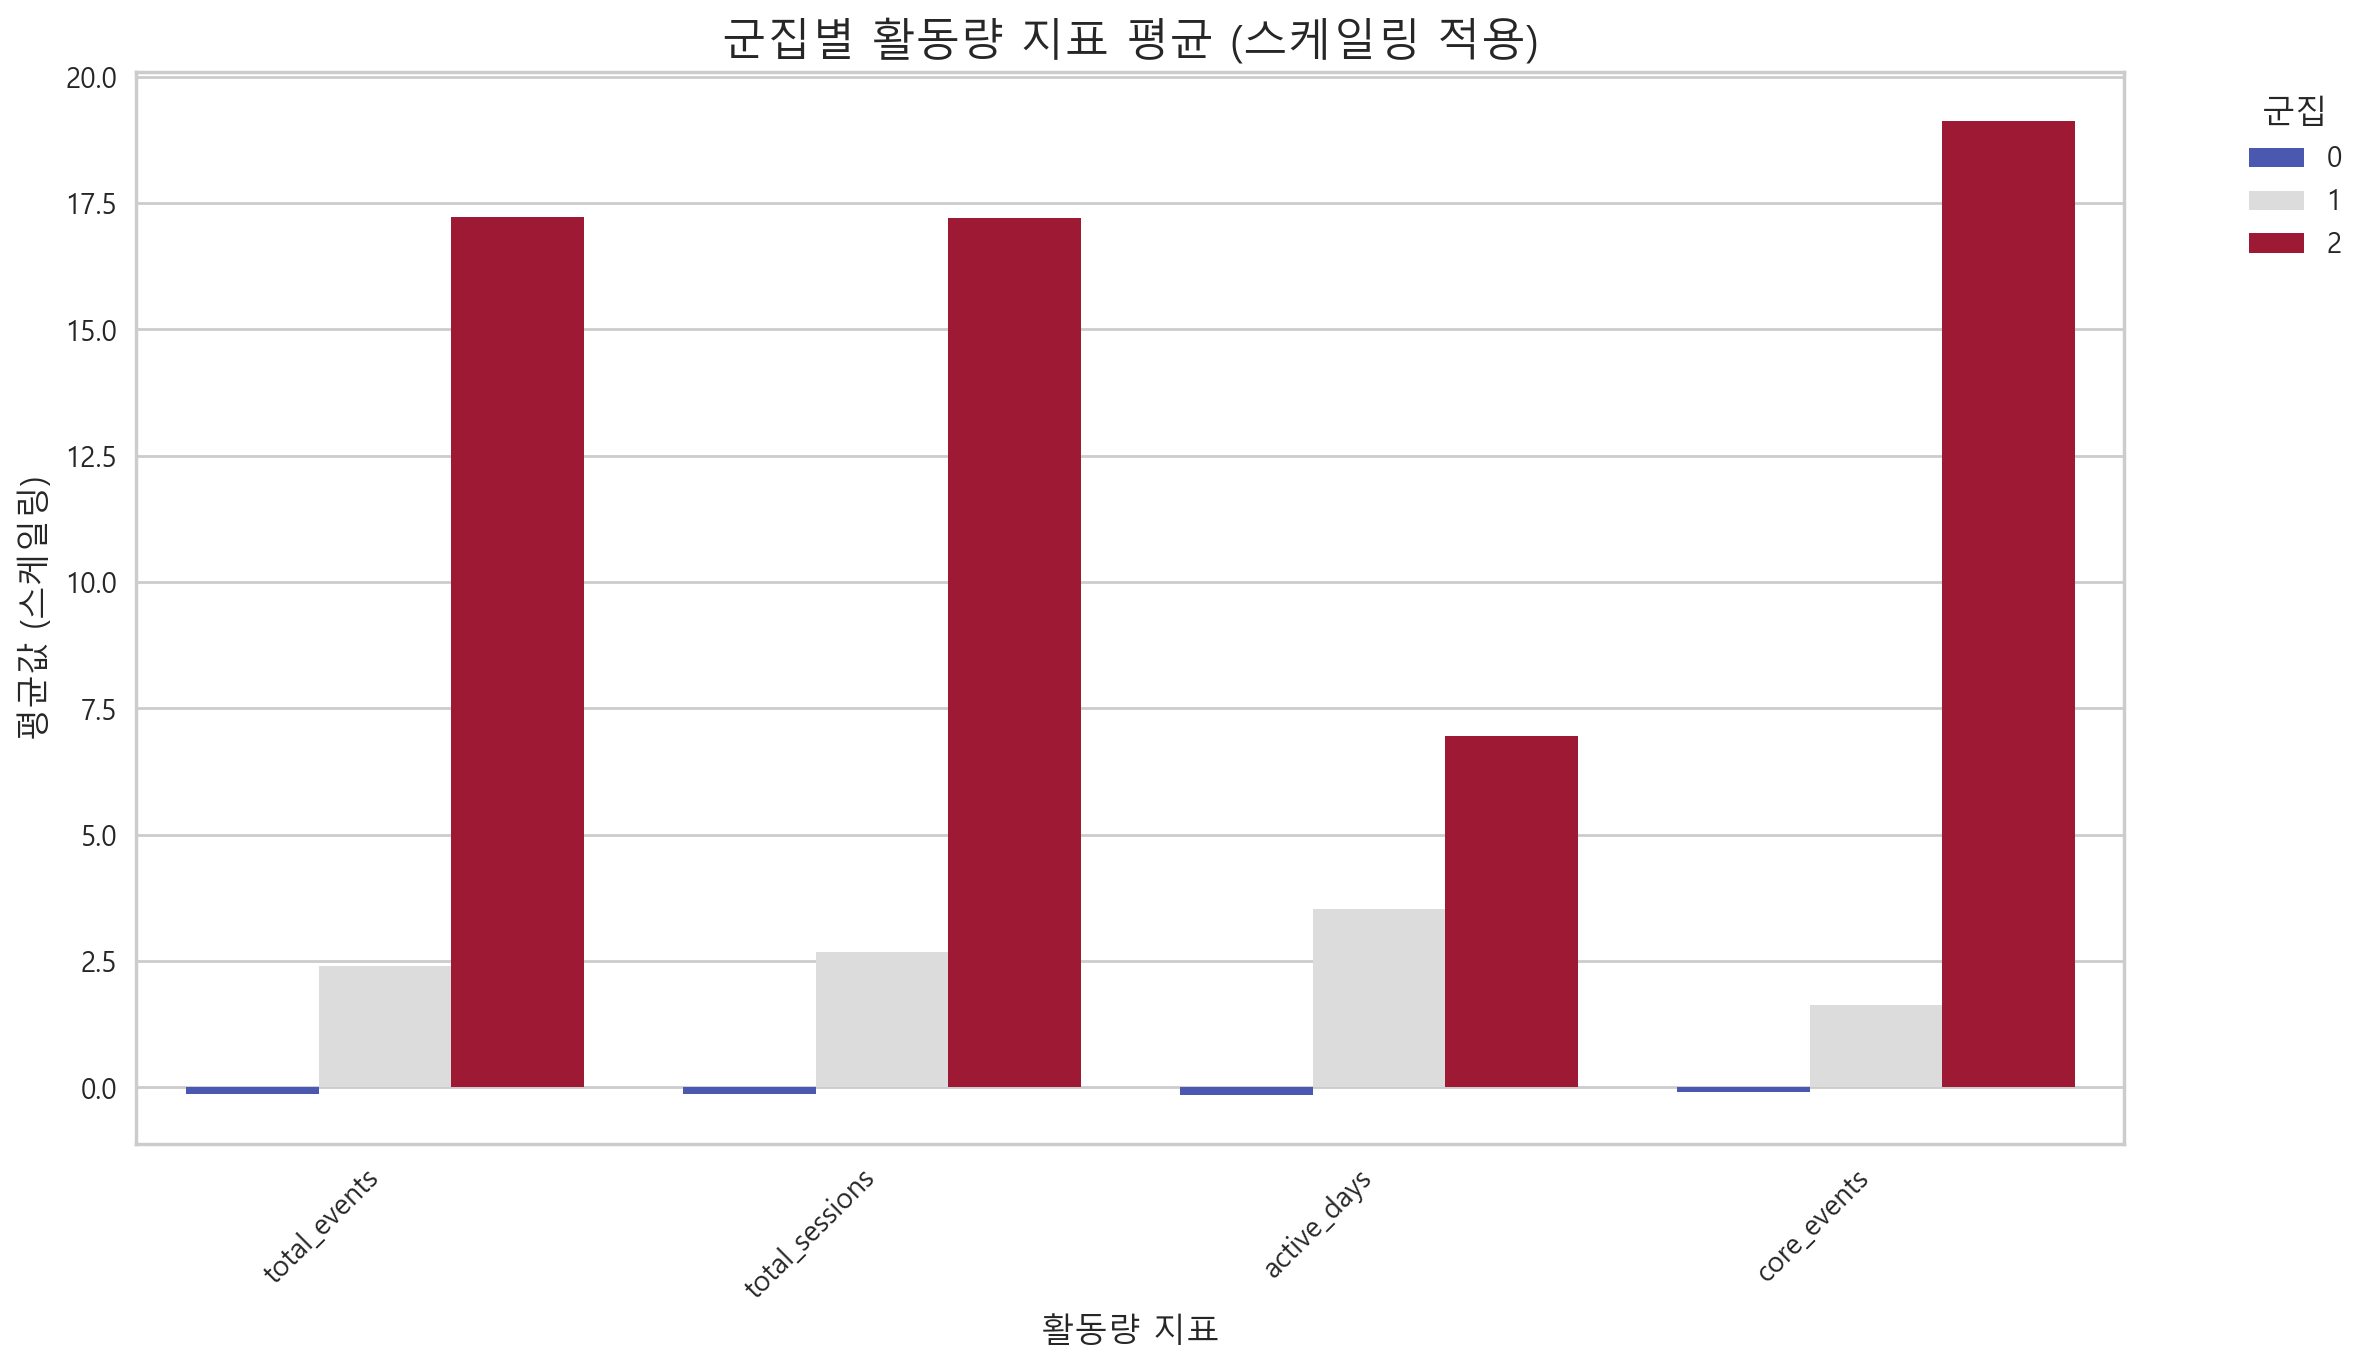


### 군집화 분석 완료 ###


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler # 스케일링을 위한 라이브러리
from sklearn.cluster import KMeans # K-Means 군집화를 위한 라이브러
from yellowbrick.cluster import KElbowVisualizer # 엘보우 방법을 시각화하기 위한 라이브러리

# 결제 상태 정보 추가
user_summary['payment_status'] = user_summary['user_id'].map(user_payment)
user_summary['payment_status_str'] = user_summary['payment_status'].apply(lambda x: '결제 유저' if x else '비결제 유저')

print("### 활동량 기준 유저 군집화 및 결제율 분석 ###")
print(f"총 사용자 수: {len(user_summary)}명")
print(f"결제 유저 수: {user_summary['payment_status'].sum()}명")
print(f"비결제 유저 수: {len(user_summary) - user_summary['payment_status'].sum()}명")


# ---  군집화 준비 ---
# 군집화에 사용할 활동량 지표 선택
features_for_clustering = ['total_events', 'total_sessions', 'active_days', 'core_events']
X = user_summary[features_for_clustering].copy()

# 데이터 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering, index=X.index)

print("\n--- 최적의 K (군집 개수) 탐색 (엘보우 방법) ---")
# 시각화를 위한 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

model = KMeans(random_state=42, n_init='auto') # n_init='auto'는 최신 버전 Kmeans 권장사항
visualizer = KElbowVisualizer(model, k=(2,10), metric='distortion', timings=False) # k 범위를 2~9로 설정 (10은 포함 안됨)

plt.figure(figsize=(8, 6))
visualizer.fit(X_scaled)
visualizer.show()
print("-> 엘보우 차트에서 꺾이는 지점을 찾아 최적의 K를 결정하세요. (가장 적절한 K값을 아래 `optimal_k`에 직접 입력하세요.)")

# 사용자가 직접 최적의 K 값을 입력 (엘보우 차트를 보고 결정)
optimal_k = 3 # 예시: 엘보우 차트를 보고 3이 적절하다고 가정 (수정 가능)
print(f"\n결정된 최적의 K (군집 개수): {optimal_k}")


# --- K-Means 군집화 실행 ---
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
user_summary['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\n--- K-Means 군집화 완료 ({optimal_k}개 군집 생성) ---")


# --- 군집별 특성 분석 ---
print("\n--- 군집별 특성 분석 ---")

# 각 군집의 사용자 수
cluster_user_counts = user_summary['cluster'].value_counts().sort_index()
print("\n 군집별 사용자 수:\n", cluster_user_counts)

# 각 군집의 평균 활동량 지표
cluster_activity_summary = user_summary.groupby('cluster')[features_for_clustering].mean()
print("\n 군집별 평균 활동량 지표:")
print(cluster_activity_summary.round(2))

# 각 군집별 결제율 계산
cluster_payment_rates = user_summary.groupby('cluster')['payment_status'].mean() * 100
print("\n군집별 결제율 (%):\n", cluster_payment_rates.round(2))

# 군집별 특성 통합 (편의성을 위해)
cluster_analysis_df = cluster_activity_summary.copy()
cluster_analysis_df['user_count'] = cluster_user_counts
cluster_analysis_df['payment_rate'] = cluster_payment_rates
cluster_analysis_df = cluster_analysis_df.sort_values(by='payment_rate', ascending=False) # 결제율 높은 순으로 정렬

print("\n--- 통합 군집 분석 결과 (결제율 높은 순 정렬) ---")
print(cluster_analysis_df.round(2).to_string())

# --- 군집별 결제율 및 활동량 특징 시각화 ---
print("\n--- 군집별 결과 시각화 ---")

# 군집별 결제율 막대 그래프
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_payment_rates.index, y=cluster_payment_rates.values, palette='viridis')
plt.title("군집별 결제율", fontsize=16)
plt.xlabel("군집 번호", fontsize=12)
plt.ylabel("결제율 (%)", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 군집별 활동량 지표 시각화 (Normalized values for comparison)
# 각 지표별로 가장 높고 낮은 군집을 시각적으로 비교하기 위함
cluster_activity_scaled_mean = pd.DataFrame(scaler.transform(cluster_activity_summary),
                                            columns=features_for_clustering,
                                            index=cluster_activity_summary.index)
cluster_activity_scaled_mean = cluster_activity_scaled_mean.reset_index().melt(id_vars='cluster', var_name='feature', value_name='scaled_value')

plt.figure(figsize=(12, 7))
sns.barplot(data=cluster_activity_scaled_mean, x='feature', y='scaled_value', hue='cluster', palette='coolwarm')
plt.title("군집별 활동량 지표 평균 (스케일링 적용)", fontsize=16)
plt.xlabel("활동량 지표", fontsize=12)
plt.ylabel("평균값 (스케일링)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='군집', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 군집화 분석 완료 ###")

# user_summary.to_csv('user_cluster.csv', index=False, encoding='cp949') # 모델링용 테이블에 결합하기 위해 user_summary 데이터 프레임을 저장

- 클러스터 0 : 활동량이 거의 없는 그룹
- 클러스터 1 : 활동량이 준수한 그룹
- 클러스터 2 : 활동량이 풍부한 그룹

- 📌 분석 인사이트 및 다음 단계 제안
- 🚨 활동량이 결제율과 선형 관계가 아닐 수 있음
    - 가설: “활동량이 높을수록 결제율이 증가한다”는 전제를 군집 1과 2가 깨고 있음.

    - 오히려 너무 높은 활동량을 보이는 일부 사용자(군집 2)는 결제와 무관하거나, 결제 니즈가 낮을 수도 있음.

    - 따라서 단순히 활동량이 많다고 해서 유료전환 가능성이 더 높다고 보기 어려움.

- ✅ 다음 분석 방향 제안
    - 1. 📊 군집 1 + 2 통합 분석 (활동 유저 전체 vs 결제 여부)
        - 활동 유저(군집 1과 2)를 묶어서, 결제 유무에 따른 행동 차이 분석:

            - 결제 유저 vs 비결제 유저 간의 이벤트 패턴, 세션당 이벤트 수, 핵심 기능 이용률 비교

            - → 전환을 유도할 수 있는 행동 특성을 도출

    - 2. 🔍 군집 1 vs 군집 2 비교 분석
        - 둘 다 활동량은 많지만, 결제율이 정비례하지 않음.

        - 아래 질문들에 답하는 방향으로 분석:

            - 군집 2는 어떤 기능에 더 많이 머무는가? (콘텐츠 소비 vs 생산?)

            - 군집 2는 이미 결제할 필요가 없는 무료 유저 대상 기능에 몰려 있을 가능성은?

            - 혹은, 군집 2는 고빈도 사용자지만, 결제 유도 경험이 부족했을 가능성은?



### 📊 군집 1+2 통합 분석: 활동 유저 전체 vs 결제 여부

- ✅ 분석 목적
- 클러스터 1 & 2는 활동량이 높은 사용자 그룹입니다.
- 이 중 결제 유저 vs 비결제 유저의 활동량 차이를 비교하여: “활동량이 결제율에 영향을 주는가?” 를 확인하고자 했습니다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17560\2578466214.py:22: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.




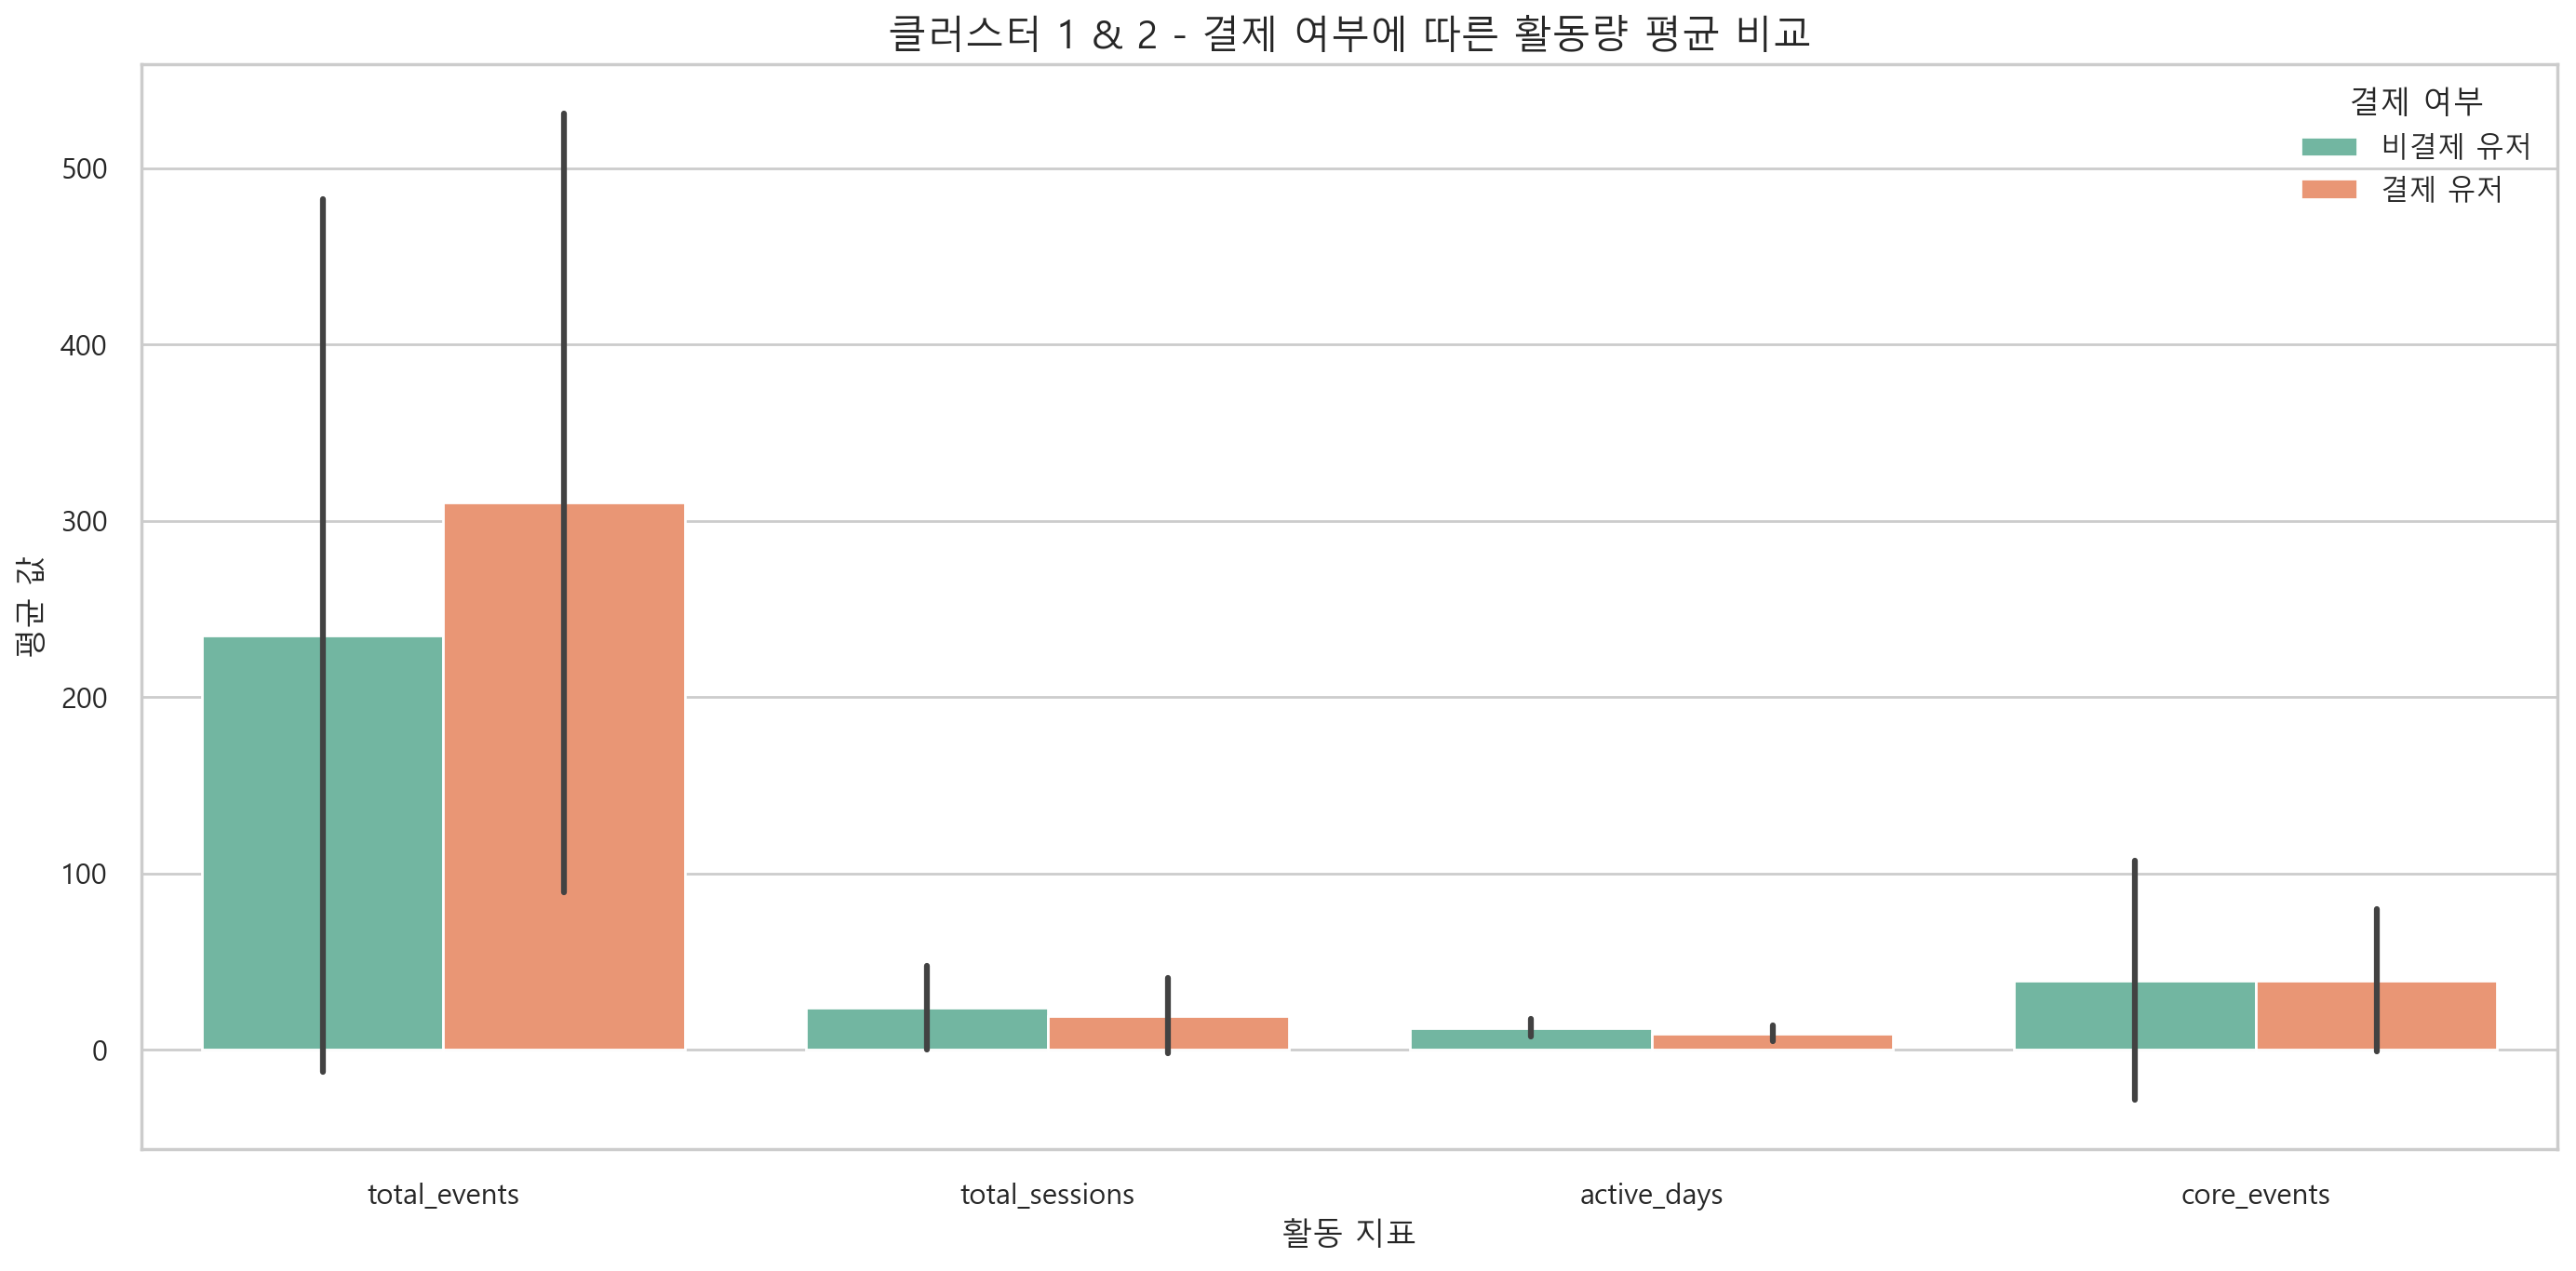

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 클러스터 1, 2만 필터링
filtered = user_summary[user_summary['cluster'].isin([1, 2])].copy()

# 결제 여부 텍스트 컬럼 생성
filtered['payment_status_str'] = filtered['payment_status'].apply(lambda x: '결제 유저' if x else '비결제 유저')

# 분석할 활동량 지표
features = ['total_events', 'total_sessions', 'active_days', 'core_events']

# melt 변환
melted = filtered.melt(id_vars=['cluster', 'payment_status_str'],
                       value_vars=features,
                       var_name='활동 지표', value_name='값')

# 시각화
sns.set(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})  # 한글 폰트 설정
plt.figure(figsize=(14, 7))
sns.barplot(data=melted, x='활동 지표', y='값', hue='payment_status_str', ci='sd', palette='Set2')
plt.title('클러스터 1 & 2 - 결제 여부에 따른 활동량 평균 비교', fontsize=15)
plt.xlabel('활동 지표')
plt.ylabel('평균 값')
plt.legend(title='결제 여부')
plt.tight_layout()
plt.show()


- 📌 인사이트 요약
- 총 이벤트 수(total_events)에서 결제 유저의 활동량이 뚜렷하게 높습니다.

    - 이는 결제 유저들이 서비스 내에서 훨씬 더 많은 행동을 수행한다는 것을 의미합니다.

    - 특히 심화된 활동이나 몰입도 높은 사용의 신호일 수 있습니다.

- 반면, 세션 수나 활동일 수에서는 큰 차이가 없거나 오히려 비결제 유저가 더 많습니다.

    - 이는 단순히 자주 방문한다고 해서 결제로 이어지진 않음을 시사합니다.

    - 방문 빈도보다는 방문당 활동량이 더 중요한 요인일 수 있습니다.

### 🔍 비교 분석: Cluster 1 vs Cluster 2

In [ ]:
from scipy.stats import ttest_ind, pearsonr

# 비교에 사용할 컬럼: 활동량과 결제 여부
activity_metric = 'total_events'  # 필요시 다른 지표로 바꿔도 됨
payment_col = 'payment_status'    # 1 or 0

# 군집 1, 2만 추출
cluster_1 = user_summary[user_summary['cluster'] == 1]
cluster_2 = user_summary[user_summary['cluster'] == 2]

# ---------------------
# ▶ Cluster 1 분석
# ---------------------
print("\n[Cluster 1]")

# 결제자 vs 비결제자 활동량
c1_paid = cluster_1[cluster_1[payment_col] == 1][activity_metric]
c1_unpaid = cluster_1[cluster_1[payment_col] == 0][activity_metric]

# t-test
t_stat1, p_val1 = ttest_ind(c1_paid, c1_unpaid, equal_var=False)
print(f" - 결제자 vs 비결제자 평균 {activity_metric} 차이 (p-value): {p_val1:.4f}")

# 상관관계
corr1, _ = pearsonr(cluster_1[activity_metric], cluster_1[payment_col])
print(f" - {activity_metric} vs 결제여부 상관계수: {corr1:.4f}")

# ---------------------
# ▶ Cluster 2 분석
# ---------------------
print("\n[Cluster 2]")

# 결제자 vs 비결제자 활동량
c2_paid = cluster_2[cluster_2[payment_col] == 1][activity_metric]
c2_unpaid = cluster_2[cluster_2[payment_col] == 0][activity_metric]

# t-test
t_stat2, p_val2 = ttest_ind(c2_paid, c2_unpaid, equal_var=False)
print(f" - 결제자 vs 비결제자 평균 {activity_metric} 차이 (p-value): {p_val2:.4f}")

# 상관관계
corr2, _ = pearsonr(cluster_2[activity_metric], cluster_2[payment_col])
print(f" - {activity_metric} vs 결제여부 상관계수: {corr2:.4f}")



[Cluster 1]
 - 결제자 vs 비결제자 평균 total_events 차이 (p-value): 0.0000
 - total_events vs 결제여부 상관계수: 0.1052

[Cluster 2]
 - 결제자 vs 비결제자 평균 total_events 차이 (p-value): 0.4919
 - total_events vs 결제여부 상관계수: -0.0261


- ✅ Cluster 1:

    - 활동량이 많을수록 결제할 가능성이 유의하게 증가합니다.

    - 결제자와 비결제자의 활동량 차이도 통계적으로 유의미합니다 (p < 0.05).

    - 즉, 활동량이 높은 유저를 타겟으로 결제 유도 전략을 세우는 것이 효과적일 수 있는 그룹입니다.

- 🚫 Cluster 2:
    - 활동량과 결제 여부 사이에 유의한 차이가 없습니다.

    - 상관계수도 0에 가깝고 음수입니다. 활동량이 많다고 결제를 더 하는 것도 아니고, 오히려 적은 경향이 있을 수도 있습니다.

    - 이 그룹은 다른 요인(예: 콘텐츠 유형, 마케팅 노출 등)이 결제에 영향을 줄 가능성이 큽니다.



---

최종 결론 : 제 예측 모델링 시, 특히 Cluster 2와 같이 활동량 지표만으로는 예측이 어려운 사용자 그룹에 대해서는 모델 성능이 저조할 수 있음을 이해해야 합니다. 이는 모델이 데이터를 제대로 반영하지 못한 것이 아니라, 현재 가진 데이터(활동량 지표)만으로는 해당 그룹의 결제 행태를 설명하기 어렵다는 분석적 결론을 모델이 다시 한번 보여주는 것에 가깝습니다.